# Adaptive Client-Specific DP for Federated IDS — calibrated version

This notebook does the following:

1. load the ECU-IoHT and WUSTL-EHMS tabular IDS datasets;
2. preprocess them for binary classification;
3. simulate heterogeneous federated clients with Dirichlet splitting;
4. run leakage audits and simple baselines before making DP claims;
5. compare centralized, FedAvg, fixed-noise LDP-FL, and smoothed adaptive-noise FL;
6. run fixed-noise privacy/utility sweeps;
7. run an adaptive-sigma calibration study on the strict no-ID WUSTL benchmark; and
8. report plots, tables, and client-level diagnostics.


## Part 1 — Imports, seed, device, and runtime knobs


In [2]:
import math
import random
import warnings
import json
import pickle
import hashlib
from dataclasses import dataclass, replace, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Any, Callable

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

warnings.filterwarnings("ignore", category=UserWarning)


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# Prefer CUDA when available, then Apple Silicon MPS, then CPU.
# On your Mac, this should choose mps if your PyTorch build supports it.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

set_seed(42)
print("Using device:", DEVICE)

# Runtime controls.
# Keep USE_CACHE=True. First full run still trains, but repeat runs are much faster.
USE_CACHE = True
FORCE_RECOMPUTE = False
CACHE_VERSION = "v4_mps_calibrated_adaptive_sigma"
CACHE_DIR = Path(".adaptive_dp_cache")
RESULTS_DIR = Path("data/adaptive_dp_results")
CACHE_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# Reduce markdown/log bloat. Set True only when debugging round-by-round behavior.
ROUND_VERBOSE = False

# Main experiment toggles.
RUN_ORIGINAL_EXPLORATORY = False
RUN_STRICT_NO_ID = True
RUN_FIXED_SWEEPS = True
RUN_ADAPTIVE_CALIBRATION = True

# If you only want a quick smoke test while editing, set QUICK_DEV_RUN=True.
# The final reported numbers should use QUICK_DEV_RUN=False.
QUICK_DEV_RUN = False


Using device: mps


## Part 2 — Global config / experiment knobs


In [3]:
@dataclass
class FLConfig:
    # Paths
    ecu_path: str = "data/cleaned_ecu.parquet"
    wustl_path: str = "data/cleaned_wustl.parquet"

    # Reproducibility
    seed: int = 42

    # Data
    label_col: str = "label"
    test_size: float = 0.2
    val_size_within_train: float = 0.1

    # Client simulation
    n_clients: int = 8
    dirichlet_alpha: float = 0.3
    min_client_size: int = 64

    # Model / local training
    hidden_dim: int = 64
    local_epochs: int = 2
    batch_size: int = 128
    lr: float = 1e-3
    use_pos_weight: bool = False

    # Federated training
    rounds: int = 20
    clients_per_round: int = 4
    weighted_aggregation: bool = True
    early_stopping_patience: int | None = 5

    # DP strategy
    # fixed_noise, smoothed_sigma, adaptive_clip
    dp_strategy: str = "fixed_noise"

    # Fixed / adaptive sigma
    base_sigma: float = 0.02
    sigma_min: float = 0.005
    sigma_max: float = 1.00 # Testing a bigger range

    # Smoothed norm-based sigma rule
    sigma_smoothing: float = 0.8
    sigma_scale_beta: float = 0.15

    # Clipping
    clip_norm: float = 1.0
    clip_min: float = 0.1
    clip_max: float = 10.0

    # Adaptive clipping
    adaptive_clip_quantile: float = 0.5
    adaptive_clip_lr: float = 0.2

    # Threshold tuning
    threshold_grid: Tuple[float, ...] = tuple(np.round(np.linspace(0.05, 0.95, 19), 2))

    # Verbosity
    verbose: bool = True


if QUICK_DEV_RUN:
    base_cfg = FLConfig(verbose=False, seed=42, rounds=5, clients_per_round=4, early_stopping_patience=3)
else:
    base_cfg = FLConfig(verbose=False, seed=42)

print(base_cfg)


FLConfig(ecu_path='data/cleaned_ecu.parquet', wustl_path='data/cleaned_wustl.parquet', seed=42, label_col='label', test_size=0.2, val_size_within_train=0.1, n_clients=8, dirichlet_alpha=0.3, min_client_size=64, hidden_dim=64, local_epochs=2, batch_size=128, lr=0.001, use_pos_weight=False, rounds=20, clients_per_round=4, weighted_aggregation=True, early_stopping_patience=5, dp_strategy='fixed_noise', base_sigma=0.02, sigma_min=0.005, sigma_max=1.0, sigma_smoothing=0.8, sigma_scale_beta=0.15, clip_norm=1.0, clip_min=0.1, clip_max=10.0, adaptive_clip_quantile=0.5, adaptive_clip_lr=0.2, threshold_grid=(np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.35), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.65), np.float64(0.7), np.float64(0.75), np.float64(0.8), np.float64(0.85), np.float64(0.9), np.float64(0.95)), verbose=False)


## Part 3 — Caching helpers

These helpers keep repeat executions from retraining every model. If you change core logic and want fresh results, set `FORCE_RECOMPUTE = True` near the top or delete `.adaptive_dp_cache/`.


In [4]:
def _jsonable_cfg(cfg: FLConfig) -> dict:
    d = asdict(cfg)
    d["threshold_grid"] = list(cfg.threshold_grid)
    return d


def _stable_hash(obj: Any) -> str:
    payload = json.dumps(obj, sort_keys=True, default=str).encode("utf-8")
    return hashlib.md5(payload).hexdigest()[:16]


def experiment_cache_path(bundle: Dict[str, Any], cfg: FLConfig, label: str = "") -> Path:
    key_obj = {
        "cache_version": CACHE_VERSION,
        "label": label,
        "dataset_name": bundle.get("dataset_name"),
        "x_train_shape": tuple(bundle["X_train"].shape),
        "x_val_shape": tuple(bundle["X_val"].shape),
        "x_test_shape": tuple(bundle["X_test"].shape),
        "y_train_pos": float(np.mean(bundle["y_train"])),
        "cfg": _jsonable_cfg(cfg),
    }
    return CACHE_DIR / f"experiment_{_stable_hash(key_obj)}.pkl"


def dataframe_cache_path(name: str, extra: dict | None = None) -> Path:
    key_obj = {
        "cache_version": CACHE_VERSION,
        "name": name,
        "extra": extra or {},
    }
    return CACHE_DIR / f"df_{_stable_hash(key_obj)}.pkl"


def load_or_compute_dataframe(name: str, compute_fn: Callable[[], pd.DataFrame], extra: dict | None = None) -> pd.DataFrame:
    path = dataframe_cache_path(name, extra=extra)
    if USE_CACHE and not FORCE_RECOMPUTE and path.exists():
        print(f"Loaded cached dataframe: {name}")
        return pd.read_pickle(path)
    df = compute_fn()
    if USE_CACHE:
        df.to_pickle(path)
    return df


def run_experiment_cached(bundle: Dict[str, Any], cfg: FLConfig, label: str = "") -> Dict[str, Any]:
    path = experiment_cache_path(bundle, cfg, label=label)
    if USE_CACHE and not FORCE_RECOMPUTE and path.exists():
        print(f"Loaded cached experiment: {bundle['dataset_name']} / {label or cfg.dp_strategy}")
        with open(path, "rb") as f:
            return pickle.load(f)

    print(f"Running experiment: {bundle['dataset_name']} / {label or cfg.dp_strategy}")
    result = run_experiment(bundle, cfg)

    if USE_CACHE:
        with open(path, "wb") as f:
            pickle.dump(result, f)
    return result


## Part 4 — Data loading + basic sanity checks


In [5]:
def load_datasets(cfg: FLConfig) -> Tuple[pd.DataFrame, pd.DataFrame]:
    ecu_df = pd.read_parquet(cfg.ecu_path, engine="fastparquet")
    wustl_df = pd.read_parquet(cfg.wustl_path, engine="fastparquet")
    return ecu_df, wustl_df



def dataset_sanity_check(df: pd.DataFrame, label_col: str, name: str) -> pd.DataFrame:
    print(f"{name} sanity check")
    print("Label counts:")
    print(df[label_col].value_counts().sort_index())
    print("Top missing columns:")
    print(df.isna().sum().sort_values(ascending=False).head(10))

    out = pd.DataFrame([
        {
            "n_rows": df.shape[0],
            "n_cols": df.shape[1],
            "n_missing_total": int(df.isna().sum().sum()),
            "positive_rate": float(df[label_col].mean()),
        }
    ])
    return out


ecu_df, wustl_df = load_datasets(base_cfg)
print("ECU shape:", ecu_df.shape)
print("WUSTL shape:", wustl_df.shape)

display(dataset_sanity_check(ecu_df, "label", "ECU"))
display(dataset_sanity_check(wustl_df, "label", "WUSTL"))


ECU shape: (111207, 6)
WUSTL shape: (16318, 43)
ECU sanity check
Label counts:
label
0    23453
1    87754
Name: count, dtype: int64
Top missing columns:
Time           0
Source         0
Destination    0
Protocol       0
Length         0
label          0
dtype: int64


,n_rows,n_cols,n_missing_total,positive_rate
0,111207,6,0,0.789105


WUSTL sanity check
Label counts:
label
0    14272
1     2046
Name: count, dtype: int64
Top missing columns:
Dir         0
SrcMac      0
TotPkts     0
TotBytes    0
Load        0
Loss        0
pLoss       0
pSrcLoss    0
pDstLoss    0
Rate        0
dtype: int64


,n_rows,n_cols,n_missing_total,positive_rate
0,16318,43,0,0.125383


## Part 5 — Preprocessing utilities


In [6]:
def load_polars_or_pandas(df_like) -> pd.DataFrame:
    if isinstance(df_like, pl.DataFrame):
        return df_like.to_pandas()
    if isinstance(df_like, pd.DataFrame):
        return df_like.copy()
    raise TypeError("Expected a polars or pandas DataFrame.")


def prepare_binary_tabular_data(
    df_like,
    label_col: str = "label",
    test_size: float = 0.2,
    val_size_within_train: float = 0.1,
    random_state: int = 42,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, List[str]]:
    df = load_polars_or_pandas(df_like)
    if label_col not in df.columns:
        raise ValueError(f"Label column '{label_col}' not found.")

    y = df[label_col].astype(int).to_numpy()
    X_df = df.drop(columns=[label_col]).copy()

    for c in X_df.columns:
        if pd.api.types.is_bool_dtype(X_df[c]):
            X_df[c] = X_df[c].astype(int)

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_df,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state,
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=val_size_within_train,
        stratify=y_train_full,
        random_state=random_state,
    )

    X_train = pd.get_dummies(X_train, dummy_na=True)
    X_val = pd.get_dummies(X_val, dummy_na=True)
    X_test = pd.get_dummies(X_test, dummy_na=True)

    X_train, X_val = X_train.align(X_val, join="left", axis=1, fill_value=0)
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

    feature_names = list(X_train.columns)

    scaler = StandardScaler()
    X_train_np = scaler.fit_transform(X_train.astype(np.float32))
    X_val_np = scaler.transform(X_val.astype(np.float32))
    X_test_np = scaler.transform(X_test.astype(np.float32))

    return (
        X_train_np.astype(np.float32),
        X_val_np.astype(np.float32),
        X_test_np.astype(np.float32),
        y_train.astype(np.float32),
        y_val.astype(np.float32),
        y_test.astype(np.float32),
        feature_names,
    )


def build_dataset_bundle(raw_df_like, cfg: FLConfig, dataset_name: str) -> Dict[str, Any]:
    X_train, X_val, X_test, y_train, y_val, y_test, feature_names = prepare_binary_tabular_data(
        raw_df_like,
        label_col=cfg.label_col,
        test_size=cfg.test_size,
        val_size_within_train=cfg.val_size_within_train,
        random_state=cfg.seed,
    )
    return {
        "dataset_name": dataset_name,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "feature_names": feature_names,
    }


## Part 6 — Client Dirichlet split helpers



In [7]:
def dirichlet_split_indices(
    y: np.ndarray,
    n_clients: int,
    alpha: float = 0.3,
    min_size: int = 64,
    seed: int = 42,
) -> List[np.ndarray]:
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    classes = np.unique(y)

    while True:
        client_indices = [[] for _ in range(n_clients)]

        for cls in classes:
            cls_idx = np.where(y == cls)[0]
            rng.shuffle(cls_idx)
            proportions = rng.dirichlet(np.repeat(alpha, n_clients))
            cuts = (np.cumsum(proportions) * len(cls_idx)).astype(int)[:-1]
            splits = np.split(cls_idx, cuts)
            for client_id, chunk in enumerate(splits):
                client_indices[client_id].extend(chunk.tolist())

        client_indices = [np.array(idx, dtype=int) for idx in client_indices]
        if min(len(idx) for idx in client_indices) >= min_size:
            return client_indices


def summarize_clients(y: np.ndarray, client_indices: List[np.ndarray]) -> pd.DataFrame:
    rows = []
    global_pos = float(np.mean(y))
    for cid, idx in enumerate(client_indices):
        yc = y[idx]
        pos_rate = float(np.mean(yc)) if len(yc) > 0 else 0.0
        rows.append({
            "client_id": cid,
            "n_samples": len(idx),
            "pos_rate": pos_rate,
            "imbalance_vs_global": abs(pos_rate - global_pos),
        })
    return pd.DataFrame(rows)


def attach_clients_to_bundle(bundle: Dict[str, Any], cfg: FLConfig) -> Dict[str, Any]:
    client_indices = dirichlet_split_indices(
        y=bundle["y_train"].astype(int),
        n_clients=cfg.n_clients,
        alpha=cfg.dirichlet_alpha,
        min_size=cfg.min_client_size,
        seed=cfg.seed,
    )
    client_summary = summarize_clients(bundle["y_train"], client_indices)
    out = dict(bundle)
    out["client_indices"] = client_indices
    out["client_summary"] = client_summary
    return out


## Part 7 — Model + state helpers


In [8]:
class BinaryMLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)


def get_model_state(model: nn.Module) -> Dict[str, torch.Tensor]:
    return {k: v.detach().clone().cpu() for k, v in model.state_dict().items()}


def set_model_state(model: nn.Module, state: Dict[str, torch.Tensor]) -> None:
    model.load_state_dict(state, strict=True)


def state_sub(a: Dict[str, torch.Tensor], b: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    return {k: a[k] - b[k] for k in a.keys()}


def state_add(a: Dict[str, torch.Tensor], b: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    return {k: a[k] + b[k] for k in a.keys()}


def state_mul(a: Dict[str, torch.Tensor], scalar: float) -> Dict[str, torch.Tensor]:
    return {k: a[k] * scalar for k in a.keys()}


def state_l2_norm(state: Dict[str, torch.Tensor]) -> float:
    total = 0.0
    for v in state.values():
        total += float(torch.sum(v.float() ** 2))
    return math.sqrt(total)


def clip_state_by_l2(state: Dict[str, torch.Tensor], clip_norm: float) -> Tuple[Dict[str, torch.Tensor], float]:
    norm = state_l2_norm(state)
    if norm <= clip_norm or norm == 0.0:
        return {k: v.clone() for k, v in state.items()}, norm
    scale = clip_norm / norm
    return {k: v * scale for k, v in state.items()}, norm


def add_gaussian_noise_to_state(
    state: Dict[str, torch.Tensor],
    sigma: float,
    clip_norm: float,
    device: torch.device = torch.device("cpu"),
) -> Dict[str, torch.Tensor]:
    """
    Add Gaussian noise to the clipped client update.

    Noise is generated on CPU because client states are stored on CPU before aggregation.
    MPS/CUDA are still used for model training and inference.
    """
    noisy = {}
    std = sigma * clip_norm
    for k, v in state.items():
        noise = torch.normal(mean=0.0, std=std, size=v.shape)
        noisy[k] = v + noise
    return noisy


## Part 8 — Local training + DP helpers


In [9]:
def make_client_loader(
    X: np.ndarray,
    y: np.ndarray,
    indices: np.ndarray,
    batch_size: int,
    shuffle: bool = True,
) -> DataLoader:
    Xc = torch.tensor(X[indices], dtype=torch.float32)
    yc = torch.tensor(y[indices], dtype=torch.float32)
    ds = TensorDataset(Xc, yc)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def local_train(
    global_state: Dict[str, torch.Tensor],
    X_train: np.ndarray,
    y_train: np.ndarray,
    client_idx: np.ndarray,
    cfg: FLConfig,
    in_dim: int,
) -> Dict[str, torch.Tensor]:
    model = BinaryMLP(in_dim=in_dim, hidden_dim=cfg.hidden_dim).to(DEVICE)
    set_model_state(model, global_state)
    model.train()

    loader = make_client_loader(X_train, y_train, client_idx, cfg.batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    if cfg.use_pos_weight:
        yc = y_train[client_idx]
        pos = max(float(np.sum(yc == 1)), 1.0)
        neg = max(float(np.sum(yc == 0)), 1.0)
        pos_weight = torch.tensor([neg / pos], dtype=torch.float32, device=DEVICE)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.BCEWithLogitsLoss()

    for _ in range(cfg.local_epochs):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    local_state = get_model_state(model)
    delta = state_sub(local_state, global_state)
    return delta


def compute_smoothed_sigma(
    raw_delta_norm: float,
    previous_smoothed_norm: float,
    clip_norm: float,
    cfg: FLConfig,
) -> Tuple[float, float, float]:
    if previous_smoothed_norm <= 0:
        smoothed_norm = raw_delta_norm
    else:
        smoothed_norm = cfg.sigma_smoothing * previous_smoothed_norm + (1.0 - cfg.sigma_smoothing) * raw_delta_norm

    norm_ratio = smoothed_norm / max(clip_norm, 1e-12)
    raw_sigma = cfg.base_sigma * (1.0 + cfg.sigma_scale_beta * np.log1p(norm_ratio))
    clipped_sigma = float(np.clip(raw_sigma, cfg.sigma_min, cfg.sigma_max))
    return float(raw_sigma), float(clipped_sigma), float(smoothed_norm)


## Part 9 — Evaluation + federated training loop


In [10]:
def sigmoid(logits):
    """
    Numerically stable sigmoid.
    """
    logits_arr = np.asarray(logits, dtype=np.float64)
    probs = np.empty_like(logits_arr, dtype=np.float64)

    positive = logits_arr >= 0
    negative = ~positive

    probs[positive] = 1.0 / (1.0 + np.exp(-logits_arr[positive]))

    exp_logits = np.exp(logits_arr[negative])
    probs[negative] = exp_logits / (1.0 + exp_logits)

    if np.isscalar(logits):
        return float(probs)

    return probs


def predict_proba_from_state(state: Dict[str, torch.Tensor], X: np.ndarray, cfg: FLConfig) -> np.ndarray:
    model = BinaryMLP(in_dim=X.shape[1], hidden_dim=cfg.hidden_dim).to(DEVICE)
    set_model_state(model, state)
    model.eval()
    with torch.no_grad():
        xb = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        logits = model(xb).cpu().numpy()
    return sigmoid(logits)


def find_best_threshold(y_true: np.ndarray, probs: np.ndarray, grid: Tuple[float, ...]) -> Tuple[float, Dict[str, float]]:
    """
    Choose the classification threshold using validation F1.

    This combines the fixed grid with probability-derived candidate thresholds.
    That prevents cases where AUC/PR-AUC are strong but F1 is bad only because
    the coarse grid missed the useful cutoff.
    """
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs, dtype=float)

    finite_probs = probs[np.isfinite(probs)]
    if len(finite_probs) == 0:
        raise ValueError("No finite probabilities available for threshold tuning.")

    candidates = set(float(t) for t in grid)

    quantiles = np.linspace(0.0, 1.0, 501)
    prob_candidates = np.quantile(finite_probs, quantiles)
    candidates.update(float(t) for t in prob_candidates)

    eps = 1e-12
    candidates.add(float(np.min(finite_probs) - eps))
    candidates.add(float(np.max(finite_probs) + eps))

    candidates = sorted(candidates)

    best_threshold = 0.5
    best_f1 = -1.0
    best_metrics = None

    for t in candidates:
        preds = (probs >= t).astype(int)
        current_f1 = f1_score(y_true, preds, zero_division=0)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = float(t)
            best_metrics = {
                "val_accuracy": accuracy_score(y_true, preds),
                "val_precision": precision_score(y_true, preds, zero_division=0),
                "val_recall": recall_score(y_true, preds, zero_division=0),
                "val_f1": current_f1,
            }

    return best_threshold, best_metrics


def compute_binary_metrics(y_true: np.ndarray, probs: np.ndarray, threshold: float) -> Dict[str, float]:
    preds = (probs >= threshold).astype(int)
    metrics = {
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
        "auc": np.nan,
        "pr_auc": np.nan,
    }
    try:
        metrics["auc"] = roc_auc_score(y_true, probs)
    except ValueError:
        pass
    try:
        metrics["pr_auc"] = average_precision_score(y_true, probs)
    except ValueError:
        pass
    return metrics


def federated_train(bundle: Dict[str, Any], cfg: FLConfig) -> Dict[str, Any]:
    set_seed(cfg.seed)  # fairness: reset seed for each run

    X_train = bundle["X_train"]
    X_val = bundle["X_val"]
    X_test = bundle["X_test"]
    y_train = bundle["y_train"]
    y_val = bundle["y_val"]
    y_test = bundle["y_test"]
    client_indices = bundle["client_indices"]

    in_dim = X_train.shape[1]
    global_model = BinaryMLP(in_dim=in_dim, hidden_dim=cfg.hidden_dim).to(DEVICE)
    global_state = get_model_state(global_model)

    global_pos_rate = float(np.mean(y_train))
    client_summary = bundle["client_summary"]
    mean_client_n = float(client_summary["n_samples"].mean())

    history_rows = []
    client_log_rows = []

    best_val_f1 = -np.inf
    best_round = None
    best_state = {k: v.clone() for k, v in global_state.items()}
    no_improve = 0

    current_clip_norm = float(cfg.clip_norm)
    smoothed_norms = {cid: 0.0 for cid in range(len(client_indices))}

    for rnd in range(1, cfg.rounds + 1):
        chosen = np.random.choice(
            len(client_indices),
            size=min(cfg.clients_per_round, len(client_indices)),
            replace=False,
        )

        client_updates = []
        client_weights = []
        round_raw_norms = []

        for cid in chosen:
            idx = client_indices[cid]
            client_n = len(idx)
            client_pos_rate = float(np.mean(y_train[idx]))
            imbalance_term = abs(client_pos_rate - global_pos_rate)
            size_term = math.sqrt(max(mean_client_n, 1.0) / max(client_n, 1.0))

            raw_delta = local_train(
                global_state=global_state,
                X_train=X_train,
                y_train=y_train,
                client_idx=idx,
                cfg=cfg,
                in_dim=in_dim,
            )
            raw_delta_norm = state_l2_norm(raw_delta)
            round_raw_norms.append(raw_delta_norm)

            if cfg.dp_strategy == "fixed_noise":
                raw_sigma = cfg.base_sigma
                clipped_sigma = float(np.clip(raw_sigma, cfg.sigma_min, cfg.sigma_max))
                smoothed_norm = smoothed_norms[cid]
            elif cfg.dp_strategy == "smoothed_sigma":
                raw_sigma, clipped_sigma, smoothed_norm = compute_smoothed_sigma(
                    raw_delta_norm=raw_delta_norm,
                    previous_smoothed_norm=smoothed_norms[cid],
                    clip_norm=current_clip_norm,
                    cfg=cfg,
                )
                smoothed_norms[cid] = smoothed_norm
            elif cfg.dp_strategy == "adaptive_clip":
                raw_sigma = cfg.base_sigma
                clipped_sigma = float(np.clip(raw_sigma, cfg.sigma_min, cfg.sigma_max))
                smoothed_norm = smoothed_norms[cid]
            else:
                raise ValueError("Unknown dp_strategy")

            clipped_delta, clipped_delta_norm = clip_state_by_l2(raw_delta, current_clip_norm)
            noisy_delta = add_gaussian_noise_to_state(
                state=clipped_delta,
                sigma=clipped_sigma,
                clip_norm=current_clip_norm,
                device=DEVICE,
            )

            client_updates.append(noisy_delta)
            client_weights.append(client_n if cfg.weighted_aggregation else 1.0)

            client_log_rows.append({
                "round": rnd,
                "client_id": int(cid),
                "dp_strategy": cfg.dp_strategy,
                "client_n": int(client_n),
                "client_pos_rate": float(client_pos_rate),
                "imbalance_term": float(imbalance_term),
                "size_term": float(size_term),
                "clip_norm_used": float(current_clip_norm),
                "raw_delta_norm": float(raw_delta_norm),
                "clipped_delta_norm": float(clipped_delta_norm),
                "norm_ratio": float(raw_delta_norm / max(current_clip_norm, 1e-12)),
                "smoothed_norm": float(smoothed_norm),
                "raw_sigma": float(raw_sigma),
                "sigma": float(clipped_sigma),
                "sigma_saturated": bool(abs(clipped_sigma - cfg.sigma_max) < 1e-12),
            })

        total_weight = float(np.sum(client_weights))
        agg_delta = None
        for upd, w in zip(client_updates, client_weights):
            scaled = state_mul(upd, float(w) / total_weight)
            agg_delta = scaled if agg_delta is None else state_add(agg_delta, scaled)
        global_state = state_add(global_state, agg_delta)

        next_clip_norm = current_clip_norm
        if cfg.dp_strategy == "adaptive_clip" and len(round_raw_norms) > 0:
            target_clip = float(np.quantile(round_raw_norms, cfg.adaptive_clip_quantile))
            next_clip_norm = (1.0 - cfg.adaptive_clip_lr) * current_clip_norm + cfg.adaptive_clip_lr * max(target_clip, 1e-8)
            next_clip_norm = float(np.clip(next_clip_norm, cfg.clip_min, cfg.clip_max))

        val_probs = predict_proba_from_state(global_state, X_val, cfg)
        best_threshold, val_summary = find_best_threshold(y_val, val_probs, cfg.threshold_grid)
        test_probs = predict_proba_from_state(global_state, X_test, cfg)

        test_metrics = compute_binary_metrics(y_test, test_probs, best_threshold)
        row = {
            "round": rnd,
            "dp_strategy": cfg.dp_strategy,
            "threshold": float(best_threshold),
            "clip_norm_used": float(current_clip_norm),
            "clip_norm_next": float(next_clip_norm),
            **val_summary,
            **test_metrics,
        }
        history_rows.append(row)

        if cfg.verbose:
            print(
                f"[Round {rnd:02d}] "
                f"acc={row['accuracy']:.4f} "
                f"f1={row['f1']:.4f} "
                f"auc={row['auc']:.4f} "
                f"pr_auc={row['pr_auc']:.4f} "
                f"thr={row['threshold']:.3g} "
                f"clip={row['clip_norm_used']:.3f}"
            )

        if row["val_f1"] > best_val_f1 + 1e-8:
            best_val_f1 = row["val_f1"]
            best_round = rnd
            best_state = {k: v.clone() for k, v in global_state.items()}
            no_improve = 0
        else:
            no_improve += 1

        current_clip_norm = next_clip_norm

        if cfg.early_stopping_patience is not None and no_improve >= cfg.early_stopping_patience:
            if cfg.verbose:
                print(f"Early stopping at round {rnd} (best val_f1 at round {best_round}).")
            break

    history_df = pd.DataFrame(history_rows)
    client_log_df = pd.DataFrame(client_log_rows)

    if best_round is None:
        best_round = int(history_df.iloc[history_df["val_f1"].idxmax()]["round"])
    best_row = history_df.loc[history_df["round"] == best_round].iloc[0].to_dict()

    summary = {
        "dataset": bundle["dataset_name"],
        "dp_strategy": cfg.dp_strategy,
        "best_round": int(best_round),
        "accuracy": float(best_row["accuracy"]),
        "precision": float(best_row["precision"]),
        "recall": float(best_row["recall"]),
        "f1": float(best_row["f1"]),
        "auc": float(best_row["auc"]),
        "pr_auc": float(best_row["pr_auc"]),
        "threshold": float(best_row["threshold"]),
        "val_f1": float(best_row["val_f1"]),
    }

    return {
        "best_state": best_state,
        "history": history_df,
        "client_log": client_log_df,
        "summary": summary,
    }


## Part 10 — Experiment wrapper and original bundles


In [11]:
def prepare_experiment_bundle(raw_df_like, cfg: FLConfig, dataset_name: str) -> Dict[str, Any]:
    bundle = build_dataset_bundle(raw_df_like, cfg, dataset_name)
    bundle = attach_clients_to_bundle(bundle, cfg)

    print(f"[{dataset_name}]")
    print(
        "Shapes:",
        {
            "train": bundle["X_train"].shape,
            "val": bundle["X_val"].shape,
            "test": bundle["X_test"].shape,
        },
    )
    display(bundle["client_summary"].describe(include="all"))
    return bundle


def run_experiment(bundle: Dict[str, Any], cfg: FLConfig) -> Dict[str, Any]:
    result = federated_train(bundle, cfg)
    result["client_summary"] = bundle["client_summary"].copy()
    result["feature_count"] = bundle["X_train"].shape[1]
    return result


ecu_bundle = prepare_experiment_bundle(ecu_df, base_cfg, dataset_name="ECU")
wustl_bundle = prepare_experiment_bundle(wustl_df, base_cfg, dataset_name="WUSTL")


[ECU]
Shapes: {'train': (80068, 156), 'val': (8897, 156), 'test': (22242, 156)}


,client_id,n_samples,pos_rate,imbalance_vs_global
count,8.00000,8.00000,8.000000,8.000000
mean,3.50000,10008.50000,0.704410,0.292696
std,2.44949,18944.37241,0.399846,0.264887
min,0.00000,314.00000,0.030240,0.079153
25%,1.75000,810.75000,0.561855,0.142164
50%,3.50000,2433.50000,0.924266,0.176760
75%,5.25000,7032.75000,0.956758,0.324008
max,7.00000,55781.00000,0.997268,0.758864


[WUSTL]
Shapes: {'train': (11748, 11801), 'val': (1306, 11801), 'test': (3264, 11801)}


,client_id,n_samples,pos_rate,imbalance_vs_global
count,8.00000,8.000000,8.000000,8.000000
mean,3.50000,1468.500000,0.314576,0.308624
std,2.44949,2049.721654,0.398488,0.301403
min,0.00000,151.000000,0.000000,0.087215
25%,1.75000,339.500000,0.003039,0.117405
50%,3.50000,393.000000,0.116176,0.125383
75%,5.25000,2008.500000,0.571047,0.445664
max,7.00000,6169.000000,1.000000,0.874617


## Part 11 — Sanity checks, leakage audits, and baselines

This section runs before the main DP comparison so the later results have context. To keep markdown exports readable, the notebook displays only the top rows of the leakage audit and saves the full audit tables to CSV.


In [12]:
def make_raw_split_indices(
    df: pd.DataFrame,
    label_col: str = "label",
    test_size: float = 0.2,
    val_size_within_train: float = 0.1,
    seed: int = 42,
):
    y = df[label_col].astype(int).to_numpy()
    all_idx = np.arange(len(df))

    train_full_idx, test_idx = train_test_split(
        all_idx,
        test_size=test_size,
        stratify=y,
        random_state=seed,
    )

    y_train_full = y[train_full_idx]

    train_idx, val_idx = train_test_split(
        train_full_idx,
        test_size=val_size_within_train,
        stratify=y_train_full,
        random_state=seed,
    )

    return train_idx, val_idx, test_idx


def single_column_lookup_baseline(
    df: pd.DataFrame,
    column: str,
    train_idx: np.ndarray,
    test_idx: np.ndarray,
    label_col: str = "label",
) -> dict:
    train = df.iloc[train_idx][[column, label_col]].copy()
    test = df.iloc[test_idx][[column, label_col]].copy()

    train[column] = train[column].astype("string").fillna("<NA>")
    test[column] = test[column].astype("string").fillna("<NA>")

    global_majority = int(train[label_col].mean() >= 0.5)

    label_rate_by_value = train.groupby(column)[label_col].mean()
    lookup = (label_rate_by_value >= 0.5).astype(int).to_dict()

    train_values = set(lookup.keys())
    seen_rate = float(test[column].isin(train_values).mean())

    preds = test[column].map(lookup).fillna(global_majority).astype(int).to_numpy()
    y_true = test[label_col].astype(int).to_numpy()

    return {
        "column": column,
        "dtype": str(df[column].dtype),
        "n_unique": int(df[column].nunique(dropna=False)),
        "unique_ratio": float(df[column].nunique(dropna=False) / len(df)),
        "test_seen_value_rate": seen_rate,
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
    }


def audit_dataset_leakage(
    df: pd.DataFrame,
    dataset_name: str,
    cfg: FLConfig,
    label_col: str = "label",
) -> pd.DataFrame:
    train_idx, val_idx, test_idx = make_raw_split_indices(
        df=df,
        label_col=label_col,
        test_size=cfg.test_size,
        val_size_within_train=cfg.val_size_within_train,
        seed=cfg.seed,
    )

    rows = []
    for column in df.columns:
        if column == label_col:
            continue

        try:
            rows.append(
                single_column_lookup_baseline(
                    df=df,
                    column=column,
                    train_idx=train_idx,
                    test_idx=test_idx,
                    label_col=label_col,
                )
            )
        except Exception as e:
            rows.append({
                "column": column,
                "error": str(e),
            })

    audit = pd.DataFrame(rows)
    audit.insert(0, "dataset", dataset_name)

    id_words = ["mac", "addr", "ip", "source", "destination", "src", "dst", "sport", "dport", "time"]
    audit["id_like_name"] = audit["column"].str.lower().apply(
        lambda c: any(w in c for w in id_words)
    )

    return audit.sort_values(["f1", "accuracy"], ascending=False)


ecu_leakage_audit = load_or_compute_dataframe(
    "ecu_leakage_audit",
    lambda: audit_dataset_leakage(ecu_df, "ECU", base_cfg, label_col="label"),
    extra={"seed": base_cfg.seed},
)
wustl_leakage_audit = load_or_compute_dataframe(
    "wustl_leakage_audit",
    lambda: audit_dataset_leakage(wustl_df, "WUSTL", base_cfg, label_col="label"),
    extra={"seed": base_cfg.seed},
)

ecu_leakage_audit.to_csv(RESULTS_DIR / "ecu_single_column_leakage_audit.csv", index=False)
wustl_leakage_audit.to_csv(RESULTS_DIR / "wustl_single_column_leakage_audit.csv", index=False)

print("ECU single-column leakage audit — top rows:")
display(ecu_leakage_audit.head(10))

print("WUSTL single-column leakage audit — top rows:")
display(wustl_leakage_audit.head(15))

print("Saved full leakage audits to:")
print(RESULTS_DIR / "ecu_single_column_leakage_audit.csv")
print(RESULTS_DIR / "wustl_single_column_leakage_audit.csv")


Loaded cached dataframe: ecu_leakage_audit
Loaded cached dataframe: wustl_leakage_audit
ECU single-column leakage audit — top rows:


,dataset,column,dtype,n_unique,unique_ratio,test_seen_value_rate,accuracy,precision,recall,f1,id_like_name
4,ECU,Length,int32,794,0.007140,0.995594,0.976666,0.978212,0.992536,0.985322,False
1,ECU,Source,object,69,0.000620,1.000000,0.975632,0.978023,0.991397,0.984664,True
3,ECU,Protocol,object,11,0.000099,1.000000,0.933324,1.000000,0.915503,0.955888,False
0,ECU,Time,float32,96224,0.865269,0.168060,0.904550,0.897547,0.992308,0.942552,True
2,ECU,Destination,object,71,0.000638,1.000000,0.886071,0.940614,0.913281,0.926746,True


WUSTL single-column leakage audit — top rows:


,dataset,column,dtype,n_unique,unique_ratio,test_seen_value_rate,accuracy,precision,recall,f1,id_like_name
32,WUSTL,SrcMac,object,2,0.000123,1.000000,1.000000,1.000000,1.000000,1.000000,True
1,WUSTL,Flgs,object,7,0.000429,1.000000,0.946998,1.000000,0.577017,0.731783,False
9,WUSTL,DstLoad,float64,8195,0.502206,0.641544,0.860294,0.404082,0.242054,0.302752,True
8,WUSTL,SrcLoad,float64,8353,0.511889,0.631740,0.852941,0.333333,0.173594,0.228296,True
26,WUSTL,Load,float64,8385,0.513850,0.627145,0.848652,0.286432,0.139364,0.187500,False
31,WUSTL,Rate,float64,8425,0.516301,0.621630,0.843137,0.215470,0.095355,0.132203,False
17,WUSTL,DstJitter,float64,6046,0.370511,0.775429,0.846814,0.210191,0.080685,0.116608,True
13,WUSTL,DIntPkt,float64,6094,0.373453,0.768076,0.845895,0.186667,0.068460,0.100179,False
35,WUSTL,SpO2,int64,18,0.001103,1.000000,0.875919,0.571429,0.039120,0.073227,False
12,WUSTL,SIntPkt,float64,8505,0.521204,0.615809,0.837316,0.123457,0.048900,0.070053,False


Saved full leakage audits to:
data/adaptive_dp_results/ecu_single_column_leakage_audit.csv
data/adaptive_dp_results/wustl_single_column_leakage_audit.csv


In [13]:
def evaluate_probs_with_val_threshold(
    dataset_name: str,
    model_name: str,
    y_val: np.ndarray,
    val_probs: np.ndarray,
    y_test: np.ndarray,
    test_probs: np.ndarray,
    threshold_grid,
) -> dict:
    threshold, val_metrics = find_best_threshold(y_val, val_probs, threshold_grid)
    test_metrics = compute_binary_metrics(y_test, test_probs, threshold)

    return {
        "dataset": dataset_name,
        "model": model_name,
        "threshold": threshold,
        **val_metrics,
        **test_metrics,
    }


def run_dummy_baselines(bundle: dict, cfg: FLConfig) -> pd.DataFrame:
    X_train = bundle["X_train"]
    X_val = bundle["X_val"]
    X_test = bundle["X_test"]

    y_train = bundle["y_train"].astype(int)
    y_val = bundle["y_val"].astype(int)
    y_test = bundle["y_test"].astype(int)

    rows = []

    dummy_models = {
        "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
        "dummy_stratified": DummyClassifier(strategy="stratified", random_state=cfg.seed),
        "dummy_prior": DummyClassifier(strategy="prior"),
    }

    for name, clf in dummy_models.items():
        clf.fit(X_train, y_train)

        val_probs = clf.predict_proba(X_val)[:, 1]
        test_probs = clf.predict_proba(X_test)[:, 1]

        rows.append(
            evaluate_probs_with_val_threshold(
                dataset_name=bundle["dataset_name"],
                model_name=name,
                y_val=y_val,
                val_probs=val_probs,
                y_test=y_test,
                test_probs=test_probs,
                threshold_grid=cfg.threshold_grid,
            )
        )

    val_probs = np.ones_like(y_val, dtype=float)
    test_probs = np.ones_like(y_test, dtype=float)

    rows.append(
        evaluate_probs_with_val_threshold(
            dataset_name=bundle["dataset_name"],
            model_name="dummy_always_positive",
            y_val=y_val,
            val_probs=val_probs,
            y_test=y_test,
            test_probs=test_probs,
            threshold_grid=cfg.threshold_grid,
        )
    )

    return pd.DataFrame(rows)


## Part 12 — Strict no-ID preprocessing

The strict no-ID versions remove likely identifier/context columns before modeling. These are especially important for WUSTL because the leakage audit shows `SrcMac` alone predicts the original label perfectly.


In [14]:
def infer_identity_like_columns(df: pd.DataFrame, dataset_name: str, label_col: str = "label") -> list:
    dataset_name_upper = dataset_name.upper()

    exact_drop = set()

    if "ECU" in dataset_name_upper:
        exact_drop.update([
            "Time",
            "Source",
            "Destination",
        ])

    if "WUSTL" in dataset_name_upper:
        exact_drop.update([
            "SrcMac",
            "DstMac",
            "SrcAddr",
            "DstAddr",
            "SrcIP",
            "DstIP",
            "Source",
            "Destination",
            "Sport",
            "Dport",
            "SrcPort",
            "DstPort",
        ])

    drop_cols = []
    for col in df.columns:
        if col == label_col:
            continue

        low = col.lower()

        if col in exact_drop:
            drop_cols.append(col)
            continue

        if "mac" in low:
            drop_cols.append(col)
            continue

        if low in {"srcaddr", "dstaddr", "srcip", "dstip", "saddr", "daddr"}:
            drop_cols.append(col)
            continue

    return sorted(set([c for c in drop_cols if c in df.columns]))


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def prepare_binary_tabular_data_strict(
    df_like,
    label_col: str = "label",
    test_size: float = 0.2,
    val_size_within_train: float = 0.1,
    random_state: int = 42,
    drop_cols: list | None = None,
):
    df = load_polars_or_pandas(df_like)

    if label_col not in df.columns:
        raise ValueError(f"Label column '{label_col}' not found.")

    drop_cols = drop_cols or []
    drop_cols = [c for c in drop_cols if c in df.columns and c != label_col]

    y = df[label_col].astype(int).to_numpy()
    X_df = df.drop(columns=[label_col] + drop_cols).copy()

    for c in X_df.columns:
        if pd.api.types.is_bool_dtype(X_df[c]):
            X_df[c] = X_df[c].astype(int)

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_df,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state,
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=val_size_within_train,
        stratify=y_train_full,
        random_state=random_state,
    )

    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

    transformers = []

    if numeric_cols:
        transformers.append(("num", StandardScaler(), numeric_cols))

    if categorical_cols:
        transformers.append(("cat", make_one_hot_encoder(), categorical_cols))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=True,
    )

    X_train_np = preprocessor.fit_transform(X_train)
    X_val_np = preprocessor.transform(X_val)
    X_test_np = preprocessor.transform(X_test)

    if hasattr(X_train_np, "toarray"):
        X_train_np = X_train_np.toarray()
        X_val_np = X_val_np.toarray()
        X_test_np = X_test_np.toarray()

    try:
        feature_names = list(preprocessor.get_feature_names_out())
    except Exception:
        feature_names = [f"feature_{i}" for i in range(X_train_np.shape[1])]

    return (
        X_train_np.astype(np.float32),
        X_val_np.astype(np.float32),
        X_test_np.astype(np.float32),
        y_train.astype(np.float32),
        y_val.astype(np.float32),
        y_test.astype(np.float32),
        feature_names,
        drop_cols,
        numeric_cols,
        categorical_cols,
    )


def build_dataset_bundle_strict(raw_df_like, cfg: FLConfig, dataset_name: str) -> dict:
    raw_df = load_polars_or_pandas(raw_df_like)
    drop_cols = infer_identity_like_columns(raw_df, dataset_name, label_col=cfg.label_col)

    (
        X_train,
        X_val,
        X_test,
        y_train,
        y_val,
        y_test,
        feature_names,
        actual_drop_cols,
        numeric_cols,
        categorical_cols,
    ) = prepare_binary_tabular_data_strict(
        raw_df,
        label_col=cfg.label_col,
        test_size=cfg.test_size,
        val_size_within_train=cfg.val_size_within_train,
        random_state=cfg.seed,
        drop_cols=drop_cols,
    )

    bundle = {
        "dataset_name": f"{dataset_name}_strict_no_id",
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "feature_names": feature_names,
        "dropped_columns": actual_drop_cols,
        "numeric_columns": numeric_cols,
        "categorical_columns": categorical_cols,
    }

    bundle = attach_clients_to_bundle(bundle, cfg)

    print(f"[{bundle['dataset_name']}]")
    print("Dropped columns:", actual_drop_cols)
    print(
        "Shapes:",
        {
            "train": bundle["X_train"].shape,
            "val": bundle["X_val"].shape,
            "test": bundle["X_test"].shape,
        },
    )
    print("Numeric columns:", numeric_cols)
    print("Categorical columns:", categorical_cols)
    display(bundle["client_summary"])

    return bundle


ecu_strict_bundle = build_dataset_bundle_strict(ecu_df, base_cfg, "ECU")
wustl_strict_bundle = build_dataset_bundle_strict(wustl_df, base_cfg, "WUSTL")


[ECU_strict_no_id]
Dropped columns: ['Destination', 'Source', 'Time']
Shapes: {'train': (80068, 12), 'val': (8897, 12), 'test': (22242, 12)}
Numeric columns: ['Length']
Categorical columns: ['Protocol']


,client_id,n_samples,pos_rate,imbalance_vs_global
0,0,959,0.030240,0.758864
1,1,1134,0.938272,0.149167
2,2,314,0.984076,0.194972
3,3,5175,0.709952,0.079153
4,4,366,0.997268,0.208163
5,5,12606,0.117563,0.671541
6,6,55781,0.947652,0.158548
7,7,3733,0.910260,0.121156


[WUSTL_strict_no_id]
Dropped columns: ['Dport', 'DstAddr', 'DstMac', 'Sport', 'SrcAddr', 'SrcMac']
Shapes: {'train': (11748, 42), 'val': (1306, 42), 'test': (3264, 42)}
Numeric columns: ['SrcBytes', 'DstBytes', 'SrcLoad', 'DstLoad', 'SrcGap', 'DstGap', 'SIntPkt', 'DIntPkt', 'SIntPktAct', 'DIntPktAct', 'SrcJitter', 'DstJitter', 'sMaxPktSz', 'dMaxPktSz', 'sMinPktSz', 'dMinPktSz', 'Dur', 'Trans', 'TotPkts', 'TotBytes', 'Load', 'Loss', 'pLoss', 'pSrcLoss', 'pDstLoss', 'Rate', 'Temp', 'SpO2', 'Pulse_Rate', 'SYS', 'DIA', 'Heart_rate', 'Resp_Rate', 'ST']
Categorical columns: ['Dir', 'Flgs']


,client_id,n_samples,pos_rate,imbalance_vs_global
0,0,6169,0.004053,0.121331
1,1,151,1.000000,0.874617
2,2,2010,0.000000,0.125383
3,3,381,0.212598,0.087215
4,4,2008,0.501992,0.376609
5,5,405,0.019753,0.105630
6,6,367,0.000000,0.125383
7,7,257,0.778210,0.652827


## Part 13 — Centralized and FL baselines


In [15]:
def run_centralized_sklearn_baselines(bundle: dict, cfg: FLConfig) -> pd.DataFrame:
    X_train = bundle["X_train"]
    X_val = bundle["X_val"]
    X_test = bundle["X_test"]

    y_train = bundle["y_train"].astype(int)
    y_val = bundle["y_val"].astype(int)
    y_test = bundle["y_test"].astype(int)

    models = {
        "central_sgd_logreg_balanced": SGDClassifier(
            loss="log_loss",
            alpha=1e-4,
            max_iter=2000,
            tol=1e-3,
            class_weight="balanced",
            random_state=cfg.seed,
        ),
        "central_random_forest_balanced": RandomForestClassifier(
            n_estimators=150 if not QUICK_DEV_RUN else 30,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=cfg.seed,
            n_jobs=-1,
        ),
    }

    rows = []

    for name, clf in models.items():
        print(f"Training {bundle['dataset_name']} / {name}...")
        clf.fit(X_train, y_train)

        if hasattr(clf, "predict_proba"):
            val_probs = clf.predict_proba(X_val)[:, 1]
            test_probs = clf.predict_proba(X_test)[:, 1]
        else:
            val_scores = clf.decision_function(X_val)
            test_scores = clf.decision_function(X_test)
            val_probs = sigmoid(val_scores)
            test_probs = sigmoid(test_scores)

        rows.append(
            evaluate_probs_with_val_threshold(
                dataset_name=bundle["dataset_name"],
                model_name=name,
                y_val=y_val,
                val_probs=val_probs,
                y_test=y_test,
                test_probs=test_probs,
                threshold_grid=cfg.threshold_grid,
            )
        )

    return pd.DataFrame(rows)


def centralized_cached(bundle: dict, cfg: FLConfig) -> pd.DataFrame:
    return load_or_compute_dataframe(
        f"centralized_{bundle['dataset_name']}",
        lambda: run_centralized_sklearn_baselines(bundle, cfg),
        extra={"dataset": bundle["dataset_name"], "seed": cfg.seed, "quick": QUICK_DEV_RUN},
    )


ecu_strict_central_baselines = centralized_cached(ecu_strict_bundle, base_cfg)
wustl_strict_central_baselines = centralized_cached(wustl_strict_bundle, base_cfg)

all_central_baselines = pd.concat(
    [
        ecu_strict_central_baselines,
        wustl_strict_central_baselines,
    ],
    ignore_index=True,
)

display(all_central_baselines)


Loaded cached dataframe: centralized_ECU_strict_no_id
Loaded cached dataframe: centralized_WUSTL_strict_no_id


,dataset,model,threshold,val_accuracy,val_precision,val_recall,val_f1,accuracy,precision,recall,f1,auc,pr_auc
0,ECU_strict_no_id,central_sgd_logreg_balanced,0.112254,0.977858,0.982603,0.989460,0.986019,0.980038,0.985250,0.989516,0.987378,0.991639,0.997387
1,ECU_strict_no_id,central_random_forest_balanced,0.100000,0.981117,0.983218,0.993021,0.988095,0.983410,0.985422,0.993676,0.989532,0.997042,0.998601
2,WUSTL_strict_no_id,central_sgd_logreg_balanced,0.989368,0.939510,0.977528,0.530488,0.687747,0.945772,0.979339,0.579462,0.728111,0.839351,0.718413
3,WUSTL_strict_no_id,central_random_forest_balanced,0.391482,0.939510,0.851240,0.628049,0.722807,0.942096,0.835366,0.669927,0.743555,0.930260,0.823977


In [16]:
def run_fl_baseline_stack(
    bundle: dict,
    base_cfg: FLConfig,
    seed: int = 42,
    fixed_sigma: float = 0.02,
) -> pd.DataFrame:
    rows = []

    configs = {
        "fedavg_no_dp": replace(
            base_cfg,
            seed=seed,
            dp_strategy="fixed_noise",
            base_sigma=0.0,
            sigma_min=0.0,
            sigma_max=0.0,
            clip_norm=1e9,
            verbose=ROUND_VERBOSE,
        ),
        "fixed_ldp_sigma_0.02": replace(
            base_cfg,
            seed=seed,
            dp_strategy="fixed_noise",
            base_sigma=fixed_sigma,
            sigma_min=0.0,
            sigma_max=1.0,
            clip_norm=1.0,
            verbose=ROUND_VERBOSE,
        ),
        "smoothed_sigma_current": replace(
            base_cfg,
            seed=seed,
            dp_strategy="smoothed_sigma",
            base_sigma=fixed_sigma,
            sigma_min=0.005,
            sigma_max=0.10,
            sigma_smoothing=0.8,
            sigma_scale_beta=0.15,
            clip_norm=1.0,
            verbose=ROUND_VERBOSE,
        ),
    }

    for name, cfg in configs.items():
        result = run_experiment_cached(bundle, cfg, label=name)
        row = dict(result["summary"])
        row["model"] = name
        row["seed"] = seed
        rows.append(row)

    return pd.DataFrame(rows)


SEEDS_TO_RUN = [42, 123, 2025]
fl_rows = []

for seed in SEEDS_TO_RUN:
    fl_rows.append(run_fl_baseline_stack(ecu_strict_bundle, base_cfg, seed=seed, fixed_sigma=0.02))
    fl_rows.append(run_fl_baseline_stack(wustl_strict_bundle, base_cfg, seed=seed, fixed_sigma=0.02))

fl_baseline_results = pd.concat(fl_rows, ignore_index=True)

# display(fl_baseline_results)
# fl_baseline_results.to_csv(RESULTS_DIR / "fl_baseline_stack_results.csv", index=False)
# print("Saved", RESULTS_DIR / "fl_baseline_stack_results.csv")


Loaded cached experiment: ECU_strict_no_id / fedavg_no_dp
Loaded cached experiment: ECU_strict_no_id / fixed_ldp_sigma_0.02
Loaded cached experiment: ECU_strict_no_id / smoothed_sigma_current
Loaded cached experiment: WUSTL_strict_no_id / fedavg_no_dp
Loaded cached experiment: WUSTL_strict_no_id / fixed_ldp_sigma_0.02
Loaded cached experiment: WUSTL_strict_no_id / smoothed_sigma_current
Loaded cached experiment: ECU_strict_no_id / fedavg_no_dp
Loaded cached experiment: ECU_strict_no_id / fixed_ldp_sigma_0.02
Loaded cached experiment: ECU_strict_no_id / smoothed_sigma_current
Loaded cached experiment: WUSTL_strict_no_id / fedavg_no_dp
Loaded cached experiment: WUSTL_strict_no_id / fixed_ldp_sigma_0.02
Loaded cached experiment: WUSTL_strict_no_id / smoothed_sigma_current
Loaded cached experiment: ECU_strict_no_id / fedavg_no_dp
Loaded cached experiment: ECU_strict_no_id / fixed_ldp_sigma_0.02
Loaded cached experiment: ECU_strict_no_id / smoothed_sigma_current
Loaded cached experiment: WU

In [17]:
ecu_strict_dummy_baselines = load_or_compute_dataframe(
    "ecu_strict_dummy_baselines",
    lambda: run_dummy_baselines(ecu_strict_bundle, base_cfg),
    extra={"dataset": ecu_strict_bundle["dataset_name"], "seed": base_cfg.seed},
)
wustl_strict_dummy_baselines = load_or_compute_dataframe(
    "wustl_strict_dummy_baselines",
    lambda: run_dummy_baselines(wustl_strict_bundle, base_cfg),
    extra={"dataset": wustl_strict_bundle["dataset_name"], "seed": base_cfg.seed},
)

all_baselines = pd.concat(
    [
        ecu_strict_dummy_baselines,
        wustl_strict_dummy_baselines,
        all_central_baselines,
        fl_baseline_results.rename(columns={"dp_strategy": "fl_dp_strategy"}),
    ],
    ignore_index=True,
    sort=False,
)

metric_cols = [
    "dataset",
    "model",
    "fl_dp_strategy",
    "seed",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "auc",
    "pr_auc",
    "threshold",
    "val_f1",
]

display_cols = [c for c in metric_cols if c in all_baselines.columns]

all_baselines_sorted = all_baselines[display_cols].sort_values(
    ["dataset", "f1"],
    ascending=[True, False],
)

# display(all_baselines_sorted)
# all_baselines_sorted.to_csv(RESULTS_DIR / "all_baseline_comparison.csv", index=False)
# print("Saved", RESULTS_DIR / "all_baseline_comparison.csv")


Loaded cached dataframe: ecu_strict_dummy_baselines
Loaded cached dataframe: wustl_strict_dummy_baselines


## Part 14 — Main FL/DP experiments

This section runs the main fixed-noise and current smoothed adaptive-noise FL experiments. It includes the original datasets and the stricter no-ID datasets.

Treat original WUSTL as exploratory because the leakage audit shows a direct identifier can predict the label. `WUSTL_strict_no_id` is the more defensible WUSTL setup.


In [18]:
cfg_fixed = replace(
    base_cfg,
    dp_strategy="fixed_noise",
    base_sigma=0.02,
    verbose=ROUND_VERBOSE,
)

cfg_smoothed = replace(
    base_cfg,
    dp_strategy="smoothed_sigma",
    base_sigma=0.02,
    sigma_min=0.005,
    sigma_max=0.10,
    sigma_smoothing=0.8,
    sigma_scale_beta=0.15,
    verbose=ROUND_VERBOSE,
)

cfg_adaptive_clip = replace(
    base_cfg,
    dp_strategy="adaptive_clip",
    base_sigma=0.02,
    clip_norm=1.0,
    adaptive_clip_quantile=0.5,
    adaptive_clip_lr=0.2,
    verbose=ROUND_VERBOSE,
)

# Strict no-ID runs
ecu_strict_fixed = run_experiment_cached(ecu_strict_bundle, cfg_fixed, label="main_fixed_sigma_0.02") if RUN_STRICT_NO_ID else None
ecu_strict_smoothed = run_experiment_cached(ecu_strict_bundle, cfg_smoothed, label="main_smoothed_current") if RUN_STRICT_NO_ID else None
wustl_strict_fixed = run_experiment_cached(wustl_strict_bundle, cfg_fixed, label="main_fixed_sigma_0.02") if RUN_STRICT_NO_ID else None
wustl_strict_smoothed = run_experiment_cached(wustl_strict_bundle, cfg_smoothed, label="main_smoothed_current") if RUN_STRICT_NO_ID else None


Running experiment: ECU_strict_no_id / main_fixed_sigma_0.02


Loaded cached experiment: ECU_strict_no_id / main_smoothed_current
Running experiment: WUSTL_strict_no_id / main_fixed_sigma_0.02
Loaded cached experiment: WUSTL_strict_no_id / main_smoothed_current


## Part 15 — Fixed-noise privacy/utility sweeps

These sweeps are the main privacy/utility proxy curves. The strict sweeps are the more defensible curves for final discussion.


In [19]:
from dataclasses import replace

def run_fixed_noise_sweep(
    bundle: Dict[str, Any],
    base_cfg: FLConfig,
    sigma_values: List[float],
) -> pd.DataFrame:
    rows = []
    for sigma in sigma_values:
        # This is so I could do high values without clipping
        cfg = replace(
            base_cfg,
            dp_strategy="fixed_noise",
            base_sigma=float(sigma),
            sigma_min=float(sigma),
            sigma_max=float(sigma),
            verbose=ROUND_VERBOSE,
        )

        result = run_experiment_cached(bundle, cfg, label=f"fixed_sweep_sigma_{sigma}")
        
        row = dict(result["summary"])
        row["sigma"] = float(sigma)
        rows.append(row)

    sweep_df = pd.DataFrame(rows)
    cols = ["sigma"] + [c for c in sweep_df.columns if c != "sigma"]
    return sweep_df[cols]

# Adding some more values
# sigma_sweep_values = [0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.50, 1.0]
sigma_sweep_values = [
    0.005,
    0.01,
    0.02,
    0.05,
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.75,
    1.00,
    1.50,
    2.00,
    2.50,
]

if QUICK_DEV_RUN:
    sigma_sweep_values = [0.01, 0.02]

if RUN_FIXED_SWEEPS:
    ecu_strict_fixed_sweep = run_fixed_noise_sweep(ecu_strict_bundle, base_cfg, sigma_sweep_values) if RUN_STRICT_NO_ID else pd.DataFrame()
    wustl_strict_fixed_sweep = run_fixed_noise_sweep(wustl_strict_bundle, base_cfg, sigma_sweep_values) if RUN_STRICT_NO_ID else pd.DataFrame()


# print("ECU strict no-ID fixed-noise sweep:")
# display(ecu_strict_fixed_sweep)

# print("WUSTL strict no-ID fixed-noise sweep:")
# display(wustl_strict_fixed_sweep)

# ecu_strict_fixed_sweep.to_csv(RESULTS_DIR / "ecu_strict_fixed_noise_sweep.csv", index=False)
# wustl_strict_fixed_sweep.to_csv(RESULTS_DIR / "wustl_strict_fixed_noise_sweep.csv", index=False)

# print("Saved fixed-noise sweep CSVs in", RESULTS_DIR)


Loaded cached experiment: ECU_strict_no_id / fixed_sweep_sigma_0.005
Loaded cached experiment: ECU_strict_no_id / fixed_sweep_sigma_0.01
Loaded cached experiment: ECU_strict_no_id / fixed_sweep_sigma_0.02
Loaded cached experiment: ECU_strict_no_id / fixed_sweep_sigma_0.05
Loaded cached experiment: ECU_strict_no_id / fixed_sweep_sigma_0.1
Loaded cached experiment: ECU_strict_no_id / fixed_sweep_sigma_0.2
Loaded cached experiment: ECU_strict_no_id / fixed_sweep_sigma_0.3
Loaded cached experiment: ECU_strict_no_id / fixed_sweep_sigma_0.4
Loaded cached experiment: ECU_strict_no_id / fixed_sweep_sigma_0.5
Loaded cached experiment: ECU_strict_no_id / fixed_sweep_sigma_0.75
Loaded cached experiment: ECU_strict_no_id / fixed_sweep_sigma_1.0
Loaded cached experiment: ECU_strict_no_id / fixed_sweep_sigma_1.5
Loaded cached experiment: ECU_strict_no_id / fixed_sweep_sigma_2.0
Loaded cached experiment: ECU_strict_no_id / fixed_sweep_sigma_2.5
Loaded cached experiment: WUSTL_strict_no_id / fixed_swe

## Part 16 — Adaptive sigma calibration on WUSTL strict no-ID

The first smoothed-sigma rule was conservative and produced sigmas close to fixed Gaussian noise. This calibration section directly tests whether more responsive adaptive settings create meaningful sigma spread and improve utility on the most defensible WUSTL benchmark.

The target comparison is the fixed-noise WUSTL strict sweep, especially around `sigma=0.010`, where the earlier results suggested the strict benchmark may peak.


In [20]:
def summarize_sigma_behavior(result: Dict[str, Any]) -> Dict[str, float]:
    log_df = result.get("client_log", pd.DataFrame())
    if log_df.empty or "sigma" not in log_df.columns:
        return {
            "sigma_min": np.nan,
            "sigma_max": np.nan,
            "sigma_mean": np.nan,
            "sigma_std": np.nan,
            "sigma_range": np.nan,
            "sigma_q10": np.nan,
            "sigma_q90": np.nan,
            "saturated_rate": np.nan,
            "raw_delta_norm_mean": np.nan,
        }

    sig = log_df["sigma"].astype(float)
    return {
        "sigma_min": float(sig.min()),
        "sigma_max": float(sig.max()),
        "sigma_mean": float(sig.mean()),
        "sigma_std": float(sig.std(ddof=0)),
        "sigma_range": float(sig.max() - sig.min()),
        "sigma_q10": float(sig.quantile(0.10)),
        "sigma_q90": float(sig.quantile(0.90)),
        "saturated_rate": float(log_df["sigma_saturated"].mean()) if "sigma_saturated" in log_df.columns else np.nan,
        "raw_delta_norm_mean": float(log_df["raw_delta_norm"].mean()) if "raw_delta_norm" in log_df.columns else np.nan,
    }


def run_adaptive_sigma_calibration(
    bundle: Dict[str, Any],
    base_cfg: FLConfig,
    calibration_grid: List[Dict[str, Any]],
) -> Tuple[pd.DataFrame, Dict[str, Dict[str, Any]]]:
    rows = []
    results = {}

    for params in calibration_grid:
        name = params["name"]
        cfg = replace(
            base_cfg,
            dp_strategy="smoothed_sigma",
            base_sigma=float(params["base_sigma"]),
            sigma_min=float(params.get("sigma_min", 0.001)),
            sigma_max=float(params.get("sigma_max", 0.10)),
            sigma_smoothing=float(params["sigma_smoothing"]),
            sigma_scale_beta=float(params["sigma_scale_beta"]),
            clip_norm=float(params.get("clip_norm", 1.0)),
            verbose=ROUND_VERBOSE,
        )

        result = run_experiment_cached(bundle, cfg, label=f"adaptive_calibration_{name}")
        results[name] = result

        row = dict(result["summary"])
        row["calibration_name"] = name
        row["base_sigma"] = cfg.base_sigma
        row["sigma_smoothing"] = cfg.sigma_smoothing
        row["sigma_scale_beta"] = cfg.sigma_scale_beta
        row["sigma_min_setting"] = cfg.sigma_min
        row["sigma_max_setting"] = cfg.sigma_max
        row.update(summarize_sigma_behavior(result))
        rows.append(row)

    calibration_df = pd.DataFrame(rows)
    ordered_cols = [
        "calibration_name",
        "dataset",
        "base_sigma",
        "sigma_smoothing",
        "sigma_scale_beta",
        "sigma_min_setting",
        "sigma_max_setting",
        "best_round",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "auc",
        "pr_auc",
        "threshold",
        "val_f1",
        "sigma_min",
        "sigma_max",
        "sigma_mean",
        "sigma_std",
        "sigma_range",
        "sigma_q10",
        "sigma_q90",
        "saturated_rate",
        "raw_delta_norm_mean",
    ]
    ordered_cols = [c for c in ordered_cols if c in calibration_df.columns]
    return calibration_df[ordered_cols].sort_values("f1", ascending=False), results


adaptive_calibration_grid = [
    {
        "name": "current_base0.02_smooth0.8_beta0.15",
        "base_sigma": 0.02,
        "sigma_smoothing": 0.8,
        "sigma_scale_beta": 0.15,
        "sigma_min": 0.005,
        "sigma_max": 0.10,
    },
    {
        "name": "lower_base0.01_smooth0.8_beta0.15",
        "base_sigma": 0.01,
        "sigma_smoothing": 0.8,
        "sigma_scale_beta": 0.15,
        "sigma_min": 0.001,
        "sigma_max": 0.10,
    },
    {
        "name": "responsive_base0.01_smooth0.3_beta1.0",
        "base_sigma": 0.01,
        "sigma_smoothing": 0.3,
        "sigma_scale_beta": 1.0,
        "sigma_min": 0.001,
        "sigma_max": 0.10,
    },
    {
        "name": "aggressive_base0.01_no_smooth_beta2.0",
        "base_sigma": 0.01,
        "sigma_smoothing": 0.0,
        "sigma_scale_beta": 2.0,
        "sigma_min": 0.001,
        "sigma_max": 0.10,
    },
    {
        "name": "responsive_base0.02_smooth0.3_beta1.0",
        "base_sigma": 0.02,
        "sigma_smoothing": 0.3,
        "sigma_scale_beta": 1.0,
        "sigma_min": 0.001,
        "sigma_max": 0.10,
    },
]

if QUICK_DEV_RUN:
    adaptive_calibration_grid = adaptive_calibration_grid[:2]

if RUN_ADAPTIVE_CALIBRATION:
    wustl_strict_adaptive_calibration, adaptive_calibration_results = run_adaptive_sigma_calibration(
        wustl_strict_bundle,
        base_cfg,
        adaptive_calibration_grid,
    )
else:
    wustl_strict_adaptive_calibration = pd.DataFrame()
    adaptive_calibration_results = {}

# print("WUSTL strict no-ID adaptive-sigma calibration:")
# display(wustl_strict_adaptive_calibration)

# wustl_strict_adaptive_calibration.to_csv(RESULTS_DIR / "wustl_strict_adaptive_sigma_calibration.csv", index=False)
# print("Saved", RESULTS_DIR / "wustl_strict_adaptive_sigma_calibration.csv")


Loaded cached experiment: WUSTL_strict_no_id / adaptive_calibration_current_base0.02_smooth0.8_beta0.15
Running experiment: WUSTL_strict_no_id / adaptive_calibration_lower_base0.01_smooth0.8_beta0.15
Running experiment: WUSTL_strict_no_id / adaptive_calibration_responsive_base0.01_smooth0.3_beta1.0
Running experiment: WUSTL_strict_no_id / adaptive_calibration_aggressive_base0.01_no_smooth_beta2.0
Running experiment: WUSTL_strict_no_id / adaptive_calibration_responsive_base0.02_smooth0.3_beta1.0


In [21]:
def build_fixed_vs_adaptive_comparison(
    fixed_sweep: pd.DataFrame,
    adaptive_df: pd.DataFrame,
) -> pd.DataFrame:
    fixed_rows = fixed_sweep.copy()
    if not fixed_rows.empty:
        fixed_rows["method_type"] = "fixed_noise_sweep"
        fixed_rows["calibration_name"] = fixed_rows["sigma"].apply(lambda x: f"fixed_sigma_{x:g}")
        fixed_rows["base_sigma"] = fixed_rows["sigma"]
        fixed_rows["sigma_smoothing"] = np.nan
        fixed_rows["sigma_scale_beta"] = np.nan
        fixed_rows["sigma_mean"] = fixed_rows["sigma"]
        fixed_rows["sigma_std"] = 0.0
        fixed_rows["sigma_range"] = 0.0

    adaptive_rows = adaptive_df.copy()
    if not adaptive_rows.empty:
        adaptive_rows["method_type"] = "adaptive_smoothed_sigma"
        adaptive_rows["sigma"] = np.nan

    common_cols = [
        "method_type",
        "calibration_name",
        "dataset",
        "sigma",
        "base_sigma",
        "sigma_smoothing",
        "sigma_scale_beta",
        "best_round",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "auc",
        "pr_auc",
        "threshold",
        "val_f1",
        "sigma_mean",
        "sigma_std",
        "sigma_range",
        "saturated_rate",
    ]
    combined = pd.concat([fixed_rows, adaptive_rows], ignore_index=True, sort=False)
    common_cols = [c for c in common_cols if c in combined.columns]
    return combined[common_cols].sort_values("f1", ascending=False)


wustl_strict_fixed_vs_adaptive = build_fixed_vs_adaptive_comparison(
    wustl_strict_fixed_sweep,
    wustl_strict_adaptive_calibration,
)

# print("WUSTL strict no-ID: fixed Gaussian vs calibrated adaptive sigma")
# display(wustl_strict_fixed_vs_adaptive)

# wustl_strict_fixed_vs_adaptive.to_csv(RESULTS_DIR / "wustl_strict_fixed_vs_adaptive_comparison.csv", index=False)
# print("Saved", RESULTS_DIR / "wustl_strict_fixed_vs_adaptive_comparison.csv")


## Part 17 — Results tables, plots, and diagnostics


In [22]:
def build_summary_table(results: List[Dict[str, Any] | None]) -> pd.DataFrame:
    return pd.DataFrame([r["summary"] for r in results if r is not None])


summary_table = build_summary_table([
    ecu_strict_fixed,
    ecu_strict_smoothed,
    wustl_strict_fixed,
    wustl_strict_smoothed,
])

# summary_table.to_csv(RESULTS_DIR / "main_summary_table.csv", index=False)
# display(summary_table)
# print("Saved", RESULTS_DIR / "main_summary_table.csv")


In [23]:
def plot_metric_comparison(result_a: Dict[str, Any], result_b: Dict[str, Any], title: str):
    if result_a is None or result_b is None:
        return
    hist_a = result_a["history"]
    hist_b = result_b["history"]
    label_a = result_a["summary"]["dp_strategy"]
    label_b = result_b["summary"]["dp_strategy"]

    metrics = ["accuracy", "f1", "auc", "pr_auc"]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, metric in zip(axes, metrics):
        ax.plot(hist_a["round"], hist_a[metric], marker="o", label=label_a)
        ax.plot(hist_b["round"], hist_b[metric], marker="o", label=label_b)
        ax.set_title(f"{title} - {metric}")
        ax.set_xlabel("Round")
        ax.set_ylabel(metric)
        ax.legend()
    plt.tight_layout()
    plt.show()


# plot_metric_comparison(ecu_strict_fixed, ecu_strict_smoothed, "ECU strict no-ID")
# plot_metric_comparison(wustl_strict_fixed, wustl_strict_smoothed, "WUSTL strict no-ID")


In [24]:
def plot_sigma_diagnostics(result: Dict[str, Any], title: str):
    if result is None:
        return
    log_df = result["client_log"]
    if log_df.empty:
        print("No client log available.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for cid in sorted(log_df["client_id"].unique()):
        sub = log_df[log_df["client_id"] == cid]
        axes[0].plot(sub["round"], sub["raw_sigma"], alpha=0.7, label=f"Client {cid}")
        axes[1].plot(sub["round"], sub["sigma"], alpha=0.7, label=f"Client {cid}")

    axes[0].set_title(f"{title} - raw sigma")
    axes[0].set_xlabel("Round")
    axes[0].set_ylabel("raw_sigma")

    axes[1].set_title(f"{title} - clipped sigma")
    axes[1].set_xlabel("Round")
    axes[1].set_ylabel("sigma")

    axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


# plot_sigma_diagnostics(ecu_strict_smoothed, "ECU strict no-ID smoothed_sigma")
# plot_sigma_diagnostics(wustl_strict_smoothed, "WUSTL strict no-ID smoothed_sigma")


In [25]:
def sigma_saturation_report(result: Dict[str, Any]) -> pd.DataFrame:
    if result is None:
        return pd.DataFrame()
    log_df = result["client_log"]
    if log_df.empty:
        return pd.DataFrame()
    report = log_df.groupby("client_id").agg(
        raw_sigma_min=("raw_sigma", "min"),
        raw_sigma_max=("raw_sigma", "max"),
        sigma_min=("sigma", "min"),
        sigma_max=("sigma", "max"),
        sigma_nunique=("sigma", "nunique"),
        saturated_rate=("sigma_saturated", "mean"),
        raw_delta_norm_mean=("raw_delta_norm", "mean"),
        clip_norm_mean=("clip_norm_used", "mean"),
        imbalance_term_mean=("imbalance_term", "mean"),
        size_term_mean=("size_term", "mean"),
    ).reset_index()
    return report


# reports = {
#     "ecu_strict_no_id": sigma_saturation_report(ecu_strict_smoothed),
#     "wustl_strict_no_id": sigma_saturation_report(wustl_strict_smoothed),
# }

# for name, report in reports.items():
#     print(f"{name} saturation report")
#     display(report)
#     report.to_csv(RESULTS_DIR / f"{name}_sigma_saturation_report.csv", index=False)
# print("Saved sigma reports in", RESULTS_DIR)


In [26]:
def plot_fixed_noise_sweep(sweep_df: pd.DataFrame, dataset_name: str):
    if sweep_df.empty:
        return
    metrics = ["accuracy", "f1", "auc", "pr_auc"]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, metric in zip(axes, metrics):
        ax.plot(sweep_df["sigma"], sweep_df[metric], marker="o")
        ax.set_title(f"{dataset_name} fixed-noise sweep - {metric}")
        ax.set_xlabel("sigma (privacy proxy)")
        ax.set_ylabel(metric)
    plt.tight_layout()
    plt.show()


# plot_fixed_noise_sweep(ecu_strict_fixed_sweep, "ECU strict no-ID")
# plot_fixed_noise_sweep(wustl_strict_fixed_sweep, "WUSTL strict no-ID")


In [27]:
def plot_adaptive_calibration(calibration_df: pd.DataFrame):
    if calibration_df.empty:
        return
    plot_df = calibration_df.sort_values("sigma_range")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(plot_df["sigma_range"], plot_df["f1"])
    for _, row in plot_df.iterrows():
        ax.annotate(row["calibration_name"], (row["sigma_range"], row["f1"]), fontsize=8, rotation=20)
    ax.set_xlabel("Sigma range across client updates")
    ax.set_ylabel("Test F1")
    ax.set_title("WUSTL strict no-ID adaptive calibration: responsiveness vs utility")
    plt.tight_layout()
    plt.show()


# plot_adaptive_calibration(wustl_strict_adaptive_calibration)


In [28]:
import os
import re
import pandas as pd
import numpy as np
from dataclasses import replace

MULTISEED_WUSTL_STRICT_PATH = "adaptive_dp_results/wustl_strict_multiseed_validation.csv"
os.makedirs("adaptive_dp_results", exist_ok=True)

# Use three seeds for a quick but defensible validation.
# Add more later only if you have extra time.
MULTISEED_SEEDS = [42, 123, 2025]

def safe_method_name(name: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", name)

def sigma_stats_from_result(result: dict) -> dict:
    log_df = result.get("client_log", pd.DataFrame())

    if log_df is None or log_df.empty or "sigma" not in log_df.columns:
        return {
            "sigma_min": np.nan,
            "sigma_max": np.nan,
            "sigma_mean": np.nan,
            "sigma_std": np.nan,
            "sigma_range": np.nan,
            "saturated_rate": np.nan,
            "raw_delta_norm_mean": np.nan,
        }

    sigma_values = log_df["sigma"].astype(float)

    return {
        "sigma_min": float(sigma_values.min()),
        "sigma_max": float(sigma_values.max()),
        "sigma_mean": float(sigma_values.mean()),
        "sigma_std": float(sigma_values.std(ddof=0)),
        "sigma_range": float(sigma_values.max() - sigma_values.min()),
        "saturated_rate": float(log_df["sigma_saturated"].mean()) if "sigma_saturated" in log_df.columns else np.nan,
        "raw_delta_norm_mean": float(log_df["raw_delta_norm"].mean()) if "raw_delta_norm" in log_df.columns else np.nan,
    }

def build_wustl_strict_multiseed_configs(base_cfg, seed: int):
    return {
        "fedavg_no_dp": replace(
            base_cfg,
            seed=seed,
            dp_strategy="fixed_noise",
            base_sigma=0.0,
            sigma_min=0.0,
            sigma_max=0.0,
            clip_norm=1e9,
            verbose=False,
        ),

        "fixed_sigma_0.005": replace(
            base_cfg,
            seed=seed,
            dp_strategy="fixed_noise",
            base_sigma=0.005,
            sigma_min=0.0,
            sigma_max=1.0,
            clip_norm=1.0,
            verbose=False,
        ),

        "fixed_sigma_0.010": replace(
            base_cfg,
            seed=seed,
            dp_strategy="fixed_noise",
            base_sigma=0.010,
            sigma_min=0.0,
            sigma_max=1.0,
            clip_norm=1.0,
            verbose=False,
        ),

        "fixed_sigma_0.020": replace(
            base_cfg,
            seed=seed,
            dp_strategy="fixed_noise",
            base_sigma=0.020,
            sigma_min=0.0,
            sigma_max=1.0,
            clip_norm=1.0,
            verbose=False,
        ),

        "fixed_sigma_0.050": replace(
            base_cfg,
            seed=seed,
            dp_strategy="fixed_noise",
            base_sigma=0.050,
            sigma_min=0.0,
            sigma_max=1.0,
            clip_norm=1.0,
            verbose=False,
        ),

        "current_adaptive_base0.02_smooth0.8_beta0.15": replace(
            base_cfg,
            seed=seed,
            dp_strategy="smoothed_sigma",
            base_sigma=0.020,
            sigma_min=0.005,
            sigma_max=0.100,
            sigma_smoothing=0.8,
            sigma_scale_beta=0.15,
            clip_norm=1.0,
            verbose=False,
        ),

        "lower_base0.01_smooth0.8_beta0.15": replace(
            base_cfg,
            seed=seed,
            dp_strategy="smoothed_sigma",
            base_sigma=0.010,
            sigma_min=0.001,
            sigma_max=0.100,
            sigma_smoothing=0.8,
            sigma_scale_beta=0.15,
            clip_norm=1.0,
            verbose=False,
        ),

        "responsive_base0.01_smooth0.3_beta1.0": replace(
            base_cfg,
            seed=seed,
            dp_strategy="smoothed_sigma",
            base_sigma=0.010,
            sigma_min=0.001,
            sigma_max=0.100,
            sigma_smoothing=0.3,
            sigma_scale_beta=1.0,
            clip_norm=1.0,
            verbose=False,
        ),
    }

rows = []

for seed in MULTISEED_SEEDS:
    print(f"\n=== WUSTL strict no-ID multiseed validation: seed={seed} ===")

    configs = build_wustl_strict_multiseed_configs(base_cfg, seed)

    for method, cfg in configs.items():
        print(f"Running {method}...")

        result = run_experiment(wustl_strict_bundle, cfg)

        row = {
            "dataset": "WUSTL_strict_no_id",
            "seed": seed,
            "method": method,
            "dp_strategy": cfg.dp_strategy,
            "base_sigma": cfg.base_sigma,
            "sigma_smoothing": cfg.sigma_smoothing,
            "sigma_scale_beta": cfg.sigma_scale_beta,
            "sigma_min_setting": cfg.sigma_min,
            "sigma_max_setting": cfg.sigma_max,
            **result["summary"],
            **sigma_stats_from_result(result),
        }

        rows.append(row)

wustl_strict_multiseed_results = pd.DataFrame(rows)

# display(wustl_strict_multiseed_results.sort_values(["seed", "method"]))
# wustl_strict_multiseed_results.to_csv(
#     MULTISEED_WUSTL_STRICT_PATH,
#     index=False,
# )
# print(f"\nSaved: {MULTISEED_WUSTL_STRICT_PATH}")


=== WUSTL strict no-ID multiseed validation: seed=42 ===
Running fedavg_no_dp...
Running fixed_sigma_0.005...
Running fixed_sigma_0.010...
Running fixed_sigma_0.020...
Running fixed_sigma_0.050...
Running current_adaptive_base0.02_smooth0.8_beta0.15...
Running lower_base0.01_smooth0.8_beta0.15...
Running responsive_base0.01_smooth0.3_beta1.0...

=== WUSTL strict no-ID multiseed validation: seed=123 ===
Running fedavg_no_dp...
Running fixed_sigma_0.005...
Running fixed_sigma_0.010...
Running fixed_sigma_0.020...
Running fixed_sigma_0.050...
Running current_adaptive_base0.02_smooth0.8_beta0.15...
Running lower_base0.01_smooth0.8_beta0.15...
Running responsive_base0.01_smooth0.3_beta1.0...

=== WUSTL strict no-ID multiseed validation: seed=2025 ===
Running fedavg_no_dp...
Running fixed_sigma_0.005...
Running fixed_sigma_0.010...
Running fixed_sigma_0.020...
Running fixed_sigma_0.050...
Running current_adaptive_base0.02_smooth0.8_beta0.15...
Running lower_base0.01_smooth0.8_beta0.15...
Ru

In [29]:
multiseed_summary = (
    wustl_strict_multiseed_results
    .groupby("method")
    .agg(
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        val_f1_mean=("val_f1", "mean"),
        val_f1_std=("val_f1", "std"),
        sigma_mean=("sigma_mean", "mean"),
        sigma_range_mean=("sigma_range", "mean"),
        sigma_std_mean=("sigma_std", "mean"),
    )
    .reset_index()
    .sort_values("f1_mean", ascending=False)
)

# display(multiseed_summary)
# multiseed_summary.to_csv(
#     "adaptive_dp_results/wustl_strict_multiseed_summary.csv",
#     index=False,
# )
# print("Saved adaptive_dp_results/wustl_strict_multiseed_summary.csv")

slide_cols = [
    "method",
    "f1_mean",
    "f1_std",
    "pr_auc_mean",
    "pr_auc_std",
    "val_f1_mean",
    "sigma_mean",
    "sigma_range_mean",
]

# slide_table = multiseed_summary[slide_cols].copy()
# for col in slide_table.columns:
#     if col != "method":
#         slide_table[col] = slide_table[col].round(4)
# display(slide_table)
# slide_table.to_csv(
#     "adaptive_dp_results/wustl_strict_multiseed_slide_table.csv",
#     index=False,
# )
# print("Saved adaptive_dp_results/wustl_strict_multiseed_slide_table.csv")

## Graph collection for presentation

In [30]:
from dataclasses import replace

# Fetch the No DP dictionaries explicitly so they are defined
ecu_no_dp = run_experiment_cached(
    ecu_bundle, 
    replace(base_cfg, dp_strategy="fixed_noise", base_sigma=0.0, sigma_min=0.0, sigma_max=0.0), 
    label="fedavg_no_dp"
)
ecu_strict_no_dp = run_experiment_cached(
    ecu_strict_bundle, 
    replace(base_cfg, dp_strategy="fixed_noise", base_sigma=0.0, sigma_min=0.0, sigma_max=0.0), 
    label="fedavg_no_dp"
)
wustl_no_dp = run_experiment_cached(
    wustl_bundle, 
    replace(base_cfg, dp_strategy="fixed_noise", base_sigma=0.0, sigma_min=0.0, sigma_max=0.0), 
    label="fedavg_no_dp"
)
wustl_strict_no_dp = run_experiment_cached(
    wustl_strict_bundle, 
    replace(base_cfg, dp_strategy="fixed_noise", base_sigma=0.0, sigma_min=0.0, sigma_max=0.0), 
    label="fedavg_no_dp"
)

Loaded cached experiment: ECU / fedavg_no_dp
Loaded cached experiment: ECU_strict_no_id / fedavg_no_dp
Loaded cached experiment: WUSTL / fedavg_no_dp
Loaded cached experiment: WUSTL_strict_no_id / fedavg_no_dp


In [31]:
def plot_metric_comparison_triplet(result_no_dp: Dict[str, Any], result_fixed: Dict[str, Any], result_smoothed: Dict[str, Any], title: str):
    if result_no_dp is None or result_fixed is None or result_smoothed is None:
        print(f"Skipping {title} - Missing data.")
        return
        
    hist_no_dp = result_no_dp["history"]
    hist_fixed = result_fixed["history"]
    hist_smoothed = result_smoothed["history"]
    
    label_no_dp = "fedavg_no_dp" 
    label_fixed = result_fixed["summary"]["dp_strategy"]
    label_smoothed = result_smoothed["summary"]["dp_strategy"]

    metrics = [ "f1", "pr_auc"]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    for ax, metric in zip(axes, metrics):
        # No DP in Red
        ax.plot(hist_no_dp["round"], hist_no_dp[metric], marker="o", label=label_no_dp, color="red")
        
        # Fixed and Smoothed blue/orange
        ax.plot(hist_fixed["round"], hist_fixed[metric], marker="o", label=label_fixed)
        ax.plot(hist_smoothed["round"], hist_smoothed[metric], marker="o", label=label_smoothed)
        
        ax.set_title(f"{title} - {metric}")
        ax.set_xlabel("Round")
        ax.set_ylabel(metric)
        ax.legend()
        
    plt.tight_layout()
    plt.show()

# plot_metric_comparison_triplet(ecu_strict_no_dp, ecu_strict_fixed, ecu_strict_smoothed, "ECU strict no-ID")
# plot_metric_comparison_triplet(wustl_strict_no_dp, wustl_strict_fixed, wustl_strict_smoothed, "WUSTL strict no-ID")

In [32]:
cfg_no_dp_final = replace(
    base_cfg,
    dp_strategy="fixed_noise",
    base_sigma=0.0,
    sigma_min=0.0,
    sigma_max=0.0,
    clip_norm=1e9,
    verbose=ROUND_VERBOSE,
)

cfg_fixed_001 = replace(
    base_cfg,
    dp_strategy="fixed_noise",
    base_sigma=0.01,
    sigma_min=0.01,
    sigma_max=0.01,
    verbose=ROUND_VERBOSE,
)

cfg_smoothed_final = replace(
    base_cfg,
    dp_strategy="smoothed_sigma",
    base_sigma=0.01,
    sigma_min=0.005,
    sigma_max=0.05,
    verbose=ROUND_VERBOSE,
)

In [33]:
ecu_strict_no_dp = run_experiment_cached(
    ecu_strict_bundle,
    cfg_no_dp_final,
    label="FINAL_no_dp",
)

ecu_strict_fixed = run_experiment_cached(
    ecu_strict_bundle,
    cfg_fixed_001,
    label="FINAL_fixed_sigma_0.01",
)

ecu_strict_smoothed = run_experiment_cached(
    ecu_strict_bundle,
    cfg_smoothed_final,
    label="FINAL_smoothed_sigma_base_0.01",
)

wustl_strict_no_dp_final = run_experiment_cached(
    wustl_strict_bundle,
    cfg_no_dp_final,
    label="FINAL_no_dp",
)

wustl_strict_fixed_final = run_experiment_cached(
    wustl_strict_bundle,
    cfg_fixed_001,
    label="FINAL_fixed_sigma_0.01",
)

wustl_strict_smoothed_final = run_experiment_cached(
    wustl_strict_bundle,
    cfg_smoothed_final,
    label="FINAL_smoothed_sigma_base_0.01",
)

Loaded cached experiment: ECU_strict_no_id / FINAL_no_dp
Running experiment: ECU_strict_no_id / FINAL_fixed_sigma_0.01
Running experiment: ECU_strict_no_id / FINAL_smoothed_sigma_base_0.01
Loaded cached experiment: WUSTL_strict_no_id / FINAL_no_dp
Running experiment: WUSTL_strict_no_id / FINAL_fixed_sigma_0.01
Running experiment: WUSTL_strict_no_id / FINAL_smoothed_sigma_base_0.01


In [34]:
final_utility_results = pd.DataFrame([
    ecu_strict_no_dp["summary"],
    ecu_strict_fixed["summary"],
    ecu_strict_smoothed["summary"],
    wustl_strict_no_dp_final["summary"],
    wustl_strict_fixed_final["summary"],
    wustl_strict_smoothed_final["summary"],
])

# display(final_utility_results)
# final_utility_results.to_csv(
#     RESULTS_DIR / "final_utility_results.csv",
#     index=False,
# )

In [35]:
def adaptive_sigma_report(result, name):
    print(f"\n{name}")

    if "client_log" not in result:
        print("No client_log found.")
        return

    log = result["client_log"]

    if "sigma" not in log.columns:
        print("No sigma column found.")
        return

    sig = log["sigma"].astype(float)

    print("sigma min: ", sig.min())
    print("sigma max: ", sig.max())
    print("sigma mean:", sig.mean())
    print("sigma std: ", sig.std(ddof=0))

    cols = [
        "client_id",
        "round",
        "sigma",
        "raw_delta_norm",
        "client_n",
        "client_pos_rate",
    ]
    cols = [c for c in cols if c in log.columns]

    display(
        log[cols]
        .groupby("client_id")
        .agg(["count", "mean", "min", "max"])
    )


# adaptive_sigma_report(ecu_strict_smoothed, "ECU Strict Smoothed Sigma")
# adaptive_sigma_report(wustl_strict_smoothed_final, "WUSTL Strict Smoothed Sigma")

In [36]:
# Approximate Gaussian-mechanism epsilon accounting

import numpy as np

DEFAULT_DELTA = 1e-5

def gaussian_epsilon_from_sigma(
    sigma,
    delta=DEFAULT_DELTA,
    sensitivity_multiplier=1.0,
):
    """
    Approximate per-update epsilon from a Gaussian noise multiplier.

    Assumptions:
      - noise std = sigma * clip_norm
      - L2 sensitivity = sensitivity_multiplier * clip_norm
      - fixed delta
      - single Gaussian mechanism, not composed over FL rounds

    sensitivity_multiplier=1.0:
      assumes sensitivity approximately equals the clipping norm C

    sensitivity_multiplier=2.0:
      conservative replace-one bound, sensitivity approximately 2C
    """
    sigma = np.asarray(sigma, dtype=float)

    eps = (
        sensitivity_multiplier
        * np.sqrt(2.0 * np.log(1.25 / delta))
        / np.maximum(sigma, 1e-12)
    )

    return eps

## White-box membership inference attack
This attack uses final-model white-box features:
- per-sample loss
- posterior/confidence/entropy
- correctness
- gradient summary statistics


In [37]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from torch.utils.data import TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


def _finite_tensor(t: torch.Tensor) -> torch.Tensor:
    """Replace NaN/Inf values so the sklearn attacker never receives invalid features."""
    
    return torch.nan_to_num(t, nan=0.0, posinf=1e6, neginf=-1e6)


def _finite_array(x: np.ndarray) -> np.ndarray:
    """Replace NaN/Inf values in numpy arrays."""
    
    return np.nan_to_num(x, nan=0.0, posinf=1e6, neginf=-1e6)


def extract_white_box_features(model: torch.nn.Module, x: torch.Tensor, y: torch.Tensor) -> np.ndarray:
    """
    Extract compact white-box MIA features for one sample.

    BinaryMLP binary classification:
      - model output is a single logit
      - labels are 0/1
      - training loss is BCEWithLogitsLoss
    """
    
    model.eval()
    model.zero_grad(set_to_none=True)

    x = x.float()
    y = y.float().view(-1)

    logits = _finite_tensor(model(x).view(-1))
    probs = torch.sigmoid(logits)

    loss = F.binary_cross_entropy_with_logits(logits, y, reduction="mean")
    loss = _finite_tensor(loss)
    loss.backward()

    eps = 1e-12
    p = probs.detach().clamp(eps, 1.0 - eps)

    true_conf = torch.where(y == 1, p, 1.0 - p)
    pred = (p >= 0.5).float()
    correct = (pred == y).float()
    entropy = -(p * torch.log(p) + (1.0 - p) * torch.log(1.0 - p))

    scalar_features = [
        loss.detach().view(1),
        p.detach().view(1),
        (1.0 - p).detach().view(1),
        true_conf.detach().view(1),
        correct.detach().view(1),
        entropy.detach().view(1),
        logits.detach().view(1),
    ]

    grad_features = []
    raw_grads = []

    for param in model.parameters():
        if param.grad is None:
            continue

        g = _finite_tensor(param.grad.detach().flatten())
        raw_grads.append(g)

        grad_features.extend([
            torch.linalg.vector_norm(g, ord=2).view(1),
            g.abs().mean().view(1),
            g.abs().max().view(1),
            g.mean().view(1),
            g.std(unbiased=False).view(1),
        ])

    if raw_grads:
        flat_grad = _finite_tensor(torch.cat(raw_grads))

        grad_features.extend([
            torch.linalg.vector_norm(flat_grad, ord=2).view(1),
            flat_grad.abs().mean().view(1),
            flat_grad.abs().max().view(1),
            flat_grad.mean().view(1),
            flat_grad.std(unbiased=False).view(1),
        ])

    features = torch.cat(scalar_features + grad_features)
    features = _finite_tensor(features)

    return features.detach().cpu().numpy().astype(np.float32)

## Attack dataset construction and attacker training

Members are sampled from the target model's training split.
Non-members are sampled from the target model's test split.

The attacker is trained and evaluated on a held-out split of the attack dataset,
so the MIA score is not measured on the attacker's own training examples.

In [38]:
def _balanced_sample_indices(y: np.ndarray, n_per_class: int, seed: int = 42) -> np.ndarray:
    """Sample up to n_per_class examples per target class."""
    
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)

    selected = []
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        rng.shuffle(idx)
        selected.extend(idx[:min(n_per_class, len(idx))])

    rng.shuffle(selected)
    return np.asarray(selected, dtype=int)


def _safe_attack_split(X_attack, y_attack, target_y, test_size=0.3, seed=42):
    """
    Prefer stratifying by membership and target label.
    Fall back to membership-only stratification if a stratum is too small.
    """
    
    full_strata = np.array([f"{m}_{t}" for m, t in zip(y_attack, target_y)])
    _, counts = np.unique(full_strata, return_counts=True)

    stratify = full_strata if counts.min() >= 2 else y_attack

    return train_test_split(
        X_attack,
        y_attack,
        test_size=test_size,
        random_state=seed,
        stratify=stratify,
    )


def build_attack_matrix(
    target_model,
    bundle,
    num_per_target_class=500,
    seed=42,
    member_indices=None,
    nonmember_indices=None,
):
    """
    Build the MIA dataset.

    Default mode:
      - members: balanced sample from bundle["X_train"]
      - non-members: balanced sample from bundle["X_test"]

    Exact-index mode:
      - pass member_indices and nonmember_indices directly
      - used for the overfit positive-control diagnostic
    """
    
    target_model.eval()
    target_model.to(DEVICE)

    if member_indices is None:
        member_indices = _balanced_sample_indices(
            bundle["y_train"],
            n_per_class=num_per_target_class,
            seed=seed,
        )
    else:
        member_indices = np.asarray(member_indices, dtype=int)

    if nonmember_indices is None:
        nonmember_indices = _balanced_sample_indices(
            bundle["y_test"],
            n_per_class=num_per_target_class,
            seed=seed + 1,
        )
    else:
        nonmember_indices = np.asarray(nonmember_indices, dtype=int)

    X_member = torch.tensor(bundle["X_train"][member_indices], dtype=torch.float32)
    y_member = torch.tensor(bundle["y_train"][member_indices], dtype=torch.float32)

    X_nonmember = torch.tensor(bundle["X_test"][nonmember_indices], dtype=torch.float32)
    y_nonmember = torch.tensor(bundle["y_test"][nonmember_indices], dtype=torch.float32)

    attack_features = []
    attack_membership = []
    attack_target_labels = []

    def add_sample(x, y, membership_label):
        x = x.unsqueeze(0).to(DEVICE)
        y = y.view(1).to(DEVICE)

        features = extract_white_box_features(target_model, x, y)
        features = _finite_array(features)

        attack_features.append(features)
        attack_membership.append(membership_label)
        attack_target_labels.append(int(y.item()))

    for x, y in TensorDataset(X_member, y_member):
        add_sample(x, y, membership_label=1)

    for x, y in TensorDataset(X_nonmember, y_nonmember):
        add_sample(x, y, membership_label=0)

    X_attack = _finite_array(np.vstack(attack_features).astype(np.float32))
    y_attack = np.asarray(attack_membership).astype(int)
    target_y = np.asarray(attack_target_labels).astype(int)

    return X_attack, y_attack, target_y


def run_whitebox_mia(
    target_model,
    bundle,
    num_per_target_class=500,
    seed=42,
    member_indices=None,
    nonmember_indices=None,
):
    """
    Run a final-model white-box MIA.

    Main reported metrics:
      - mia_accuracy: thresholded attack accuracy
      - mia_auc: threshold-free attack separability
      - mia_advantage: max(0, 2*AUC - 1)
      - loss_only_auc: sanity baseline using only negative loss
    """
    X_attack, y_attack, target_y = build_attack_matrix(
        target_model=target_model,
        bundle=bundle,
        num_per_target_class=num_per_target_class,
        seed=seed,
        member_indices=member_indices,
        nonmember_indices=nonmember_indices,
    )

    X_train_att, X_test_att, y_train_att, y_test_att = _safe_attack_split(
        X_attack,
        y_attack,
        target_y,
        test_size=0.3,
        seed=seed,
    )

    attack_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=seed,
        ),
    )

    attack_model.fit(X_train_att, y_train_att)

    member_scores = attack_model.predict_proba(X_test_att)[:, 1]
    member_preds = (member_scores >= 0.5).astype(int)

    mia_auc = roc_auc_score(y_test_att, member_scores)

    # Feature 0 is per-sample loss. Members usually have lower loss.
    loss_only_scores = -X_test_att[:, 0]
    loss_only_auc = roc_auc_score(y_test_att, loss_only_scores)

    return {
        "mia_accuracy": float(accuracy_score(y_test_att, member_preds)),
        "mia_balanced_accuracy": float(balanced_accuracy_score(y_test_att, member_preds)),
        "mia_auc": float(mia_auc),
        "mia_advantage": float(max(0.0, 2.0 * mia_auc - 1.0)),
        "loss_only_auc": float(loss_only_auc),
        "n_attack_samples": int(len(y_attack)),
        "n_attack_features": int(X_attack.shape[1]),
    }

## MIA evaluation helpers

These helpers rebuild each trained target model from its cached best_state
and run the same MIA protocol on each privacy strategy.

In [39]:
def load_model_from_state(bundle, result_dict, cfg):
    """Rebuild a BinaryMLP target model from a cached experiment result."""
    
    model = BinaryMLP(
        in_dim=bundle["X_train"].shape[1],
        hidden_dim=cfg.hidden_dim,
    )
    model.load_state_dict(result_dict["best_state"])
    return model


def check_model_state_finite(model, label: str) -> bool:
    """Warn if a cached model contains NaN/Inf weights."""
    
    bad_params = [
        name
        for name, tensor in model.state_dict().items()
        if not torch.isfinite(tensor).all()
    ]

    if bad_params:
        print(f"WARN: {label} has non-finite weights in: {bad_params}")
        return False

    return True


def evaluate_mia_triplet(
    bundle,
    result_no_dp,
    result_fixed,
    result_smoothed,
    dataset_name: str,
    cfg,
    num_per_target_class=500,
):
    """Evaluate No-DP, fixed-noise DP, and smoothed-sigma DP with the same MIA."""
    print(f"\n--- Running MIA Evaluations for {dataset_name} ---")

    runs = [
        ("No DP", result_no_dp),
        (result_fixed["summary"]["dp_strategy"], result_fixed),
        (result_smoothed["summary"]["dp_strategy"], result_smoothed),
    ]

    rows = []

    for strategy_name, result in runs:
        model = load_model_from_state(bundle, result, cfg)
        check_model_state_finite(model, f"{dataset_name} / {strategy_name}")

        report = run_whitebox_mia(
            target_model=model,
            bundle=bundle,
            num_per_target_class=num_per_target_class,
            seed=cfg.seed,
        )

        row = {
            "Dataset": dataset_name,
            "Strategy": strategy_name,
            **report,
        }
        rows.append(row)

        print(
            f"{strategy_name:16s} "
            f"Acc={report['mia_accuracy'] * 100:6.2f}% | "
            f"AUC={report['mia_auc']:.3f} | "
            f"Adv={report['mia_advantage']:.3f} | "
            f"LossAUC={report['loss_only_auc']:.3f}"
        )

    return pd.DataFrame(rows)

## Final MIA audits

Strict no-ID results are the primary privacy results.
ID-included results are leakage-positive controls, not the main privacy benchmark.

In [40]:
mia_results_ecu_strict = evaluate_mia_triplet(
    ecu_strict_bundle,
    ecu_strict_no_dp,
    ecu_strict_fixed,
    ecu_strict_smoothed,
    "ECU Strict",
    base_cfg,
)

mia_results_wustl_strict = evaluate_mia_triplet(
    wustl_strict_bundle,
    wustl_strict_no_dp,
    wustl_strict_fixed,
    wustl_strict_smoothed,
    "WUSTL Strict",
    base_cfg,
)

mia_results_strict = pd.concat(
    [
        mia_results_ecu_strict,
        mia_results_wustl_strict,
    ],
    ignore_index=True,
)

# display(mia_results_strict)


--- Running MIA Evaluations for ECU Strict ---
No DP            Acc= 51.50% | AUC=0.520 | Adv=0.040 | LossAUC=0.514
fixed_noise      Acc= 51.50% | AUC=0.517 | Adv=0.035 | LossAUC=0.507
smoothed_sigma   Acc= 51.50% | AUC=0.517 | Adv=0.035 | LossAUC=0.503

--- Running MIA Evaluations for WUSTL Strict ---
No DP            Acc= 50.79% | AUC=0.503 | Adv=0.007 | LossAUC=0.476
fixed_noise      Acc= 49.91% | AUC=0.504 | Adv=0.008 | LossAUC=0.476
smoothed_sigma   Acc= 50.09% | AUC=0.503 | Adv=0.006 | LossAUC=0.476


In [41]:
mia_results_ecu_strict_final = evaluate_mia_triplet(
    ecu_strict_bundle,
    ecu_strict_no_dp,
    ecu_strict_fixed,
    ecu_strict_smoothed,
    "ECU Strict",
    base_cfg,
)

mia_results_wustl_strict_final = evaluate_mia_triplet(
    wustl_strict_bundle,
    wustl_strict_no_dp_final,
    wustl_strict_fixed_final,
    wustl_strict_smoothed_final,
    "WUSTL Strict",
    base_cfg,
)

mia_results_final = pd.concat(
    [
        mia_results_ecu_strict_final,
        mia_results_wustl_strict_final,
    ],
    ignore_index=True,
)

# display(mia_results_final)

# mia_results_final.to_csv(
#     RESULTS_DIR / "final_mia_results.csv",
#     index=False,
# )


--- Running MIA Evaluations for ECU Strict ---
No DP            Acc= 51.50% | AUC=0.520 | Adv=0.040 | LossAUC=0.514
fixed_noise      Acc= 51.50% | AUC=0.517 | Adv=0.035 | LossAUC=0.507
smoothed_sigma   Acc= 51.50% | AUC=0.517 | Adv=0.035 | LossAUC=0.503

--- Running MIA Evaluations for WUSTL Strict ---
No DP            Acc= 49.21% | AUC=0.482 | Adv=0.000 | LossAUC=0.476
fixed_noise      Acc= 49.74% | AUC=0.509 | Adv=0.019 | LossAUC=0.475
smoothed_sigma   Acc= 49.91% | AUC=0.511 | Adv=0.022 | LossAUC=0.474


In [42]:
# ============================================================
# NEW CELL 1: Drift helpers
# ============================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")


def flatten_state_dict(state: Dict[str, torch.Tensor]) -> np.ndarray:
    parts = []
    for k in sorted(state.keys()):
        v = state[k].detach().float().cpu().reshape(-1).numpy()
        parts.append(v)
    if not parts:
        return np.array([], dtype=np.float32)
    return np.concatenate(parts).astype(np.float32)


def state_cosine_similarity(a: Dict[str, torch.Tensor], b: Dict[str, torch.Tensor]) -> float:
    va = flatten_state_dict(a)
    vb = flatten_state_dict(b)

    na = np.linalg.norm(va)
    nb = np.linalg.norm(vb)

    if na == 0.0 and nb == 0.0:
        return 1.0
    if na == 0.0 or nb == 0.0:
        return np.nan

    return float(np.dot(va, vb) / (na * nb))


def weighted_average_states(
    states: List[Dict[str, torch.Tensor]],
    weights: List[float],
) -> Dict[str, torch.Tensor]:
    total_weight = float(np.sum(weights))
    agg = None

    for st, w in zip(states, weights):
        scaled = state_mul(st, float(w) / total_weight)
        agg = scaled if agg is None else state_add(agg, scaled)

    return agg


def summarize_drift_results(result: Dict[str, Any]) -> pd.DataFrame:
    round_df = result["round_drift"].copy()
    if round_df.empty:
        return pd.DataFrame()

    summary = {
        "dataset": result["summary"]["dataset"],
        "dp_strategy": result["summary"]["dp_strategy"],
        "best_round": result["summary"]["best_round"],
        "best_f1": result["summary"]["f1"],
        "best_pr_auc": result["summary"]["pr_auc"],
        "mean_agg_drift_norm": round_df["aggregate_noise_drift_norm"].mean(),
        "mean_agg_drift_relative": round_df["aggregate_noise_drift_relative"].mean(),
        "mean_agg_clean_noisy_cosine": round_df["aggregate_clean_noisy_cosine"].mean(),
        "mean_global_step_norm": round_df["global_step_norm"].mean(),
    }
    return pd.DataFrame([summary])

In [43]:
# ============================================================
# NEW CELL 2: Drift-aware federated training
# ============================================================

from dataclasses import replace


def federated_train_with_drift(bundle: Dict[str, Any], cfg: FLConfig) -> Dict[str, Any]:
    set_seed(cfg.seed)

    X_train = bundle["X_train"]
    X_val = bundle["X_val"]
    X_test = bundle["X_test"]
    y_train = bundle["y_train"]
    y_val = bundle["y_val"]
    y_test = bundle["y_test"]
    client_indices = bundle["client_indices"]

    in_dim = X_train.shape[1]
    global_model = BinaryMLP(in_dim=in_dim, hidden_dim=cfg.hidden_dim).to(DEVICE)
    global_state = get_model_state(global_model)

    global_pos_rate = float(np.mean(y_train))
    client_summary = bundle["client_summary"]
    mean_client_n = float(client_summary["n_samples"].mean())

    history_rows = []
    client_log_rows = []
    round_drift_rows = []

    best_val_f1 = -np.inf
    best_round = None
    best_state = {k: v.clone() for k, v in global_state.items()}
    no_improve = 0

    current_clip_norm = float(cfg.clip_norm)
    smoothed_norms = {cid: 0.0 for cid in range(len(client_indices))}

    for rnd in range(1, cfg.rounds + 1):
        chosen = np.random.choice(
            len(client_indices),
            size=min(cfg.clients_per_round, len(client_indices)),
            replace=False,
        )

        clean_client_updates = []
        noisy_client_updates = []
        client_weights = []
        round_raw_norms = []

        for cid in chosen:
            idx = client_indices[cid]
            client_n = len(idx)
            client_pos_rate = float(np.mean(y_train[idx]))
            imbalance_term = abs(client_pos_rate - global_pos_rate)
            size_term = math.sqrt(max(mean_client_n, 1.0) / max(client_n, 1.0))

            raw_delta = local_train(
                global_state=global_state,
                X_train=X_train,
                y_train=y_train,
                client_idx=idx,
                cfg=cfg,
                in_dim=in_dim,
            )
            raw_delta_norm = state_l2_norm(raw_delta)
            round_raw_norms.append(raw_delta_norm)

            # -----------------------
            # strategy-specific sigma
            # -----------------------
            if cfg.dp_strategy == "fedavg_no_dp":
                raw_sigma = 0.0
                clipped_sigma = 0.0
                smoothed_norm = smoothed_norms[cid]

                clean_delta = raw_delta
                clean_delta_norm = raw_delta_norm
                noisy_delta = raw_delta

            elif cfg.dp_strategy == "fixed_noise":
                raw_sigma = cfg.base_sigma
                clipped_sigma = float(np.clip(raw_sigma, cfg.sigma_min, cfg.sigma_max))
                smoothed_norm = smoothed_norms[cid]

                clean_delta, clean_delta_norm = clip_state_by_l2(raw_delta, current_clip_norm)
                noisy_delta = add_gaussian_noise_to_state(
                    state=clean_delta,
                    sigma=clipped_sigma,
                    clip_norm=current_clip_norm,
                    device=DEVICE,
                )

            elif cfg.dp_strategy == "smoothed_sigma":
                raw_sigma, clipped_sigma, smoothed_norm = compute_smoothed_sigma(
                    raw_delta_norm=raw_delta_norm,
                    previous_smoothed_norm=smoothed_norms[cid],
                    clip_norm=current_clip_norm,
                    cfg=cfg,
                )
                smoothed_norms[cid] = smoothed_norm

                clean_delta, clean_delta_norm = clip_state_by_l2(raw_delta, current_clip_norm)
                noisy_delta = add_gaussian_noise_to_state(
                    state=clean_delta,
                    sigma=clipped_sigma,
                    clip_norm=current_clip_norm,
                    device=DEVICE,
                )

            elif cfg.dp_strategy == "adaptive_clip":
                raw_sigma = cfg.base_sigma
                clipped_sigma = float(np.clip(raw_sigma, cfg.sigma_min, cfg.sigma_max))
                smoothed_norm = smoothed_norms[cid]

                clean_delta, clean_delta_norm = clip_state_by_l2(raw_delta, current_clip_norm)
                noisy_delta = add_gaussian_noise_to_state(
                    state=clean_delta,
                    sigma=clipped_sigma,
                    clip_norm=current_clip_norm,
                    device=DEVICE,
                )

            else:
                raise ValueError(f"Unknown dp_strategy: {cfg.dp_strategy}")

            noise_delta = state_sub(noisy_delta, clean_delta)
            noise_delta_norm = state_l2_norm(noise_delta)
            relative_noise_drift = float(noise_delta_norm / max(clean_delta_norm, 1e-12))
            clean_noisy_cosine = state_cosine_similarity(clean_delta, noisy_delta)

            clean_client_updates.append(clean_delta)
            noisy_client_updates.append(noisy_delta)
            client_weights.append(client_n if cfg.weighted_aggregation else 1.0)

            client_log_rows.append({
                "round": rnd,
                "client_id": int(cid),
                "dp_strategy": cfg.dp_strategy,
                "client_n": int(client_n),
                "client_pos_rate": float(client_pos_rate),
                "imbalance_term": float(imbalance_term),
                "size_term": float(size_term),
                "clip_norm_used": float(current_clip_norm),
                "raw_delta_norm": float(raw_delta_norm),
                "clean_delta_norm": float(clean_delta_norm),
                "norm_ratio": float(raw_delta_norm / max(current_clip_norm, 1e-12)),
                "smoothed_norm": float(smoothed_norm),
                "raw_sigma": float(raw_sigma),
                "sigma": float(clipped_sigma),
                "sigma_saturated": bool(abs(clipped_sigma - cfg.sigma_max) < 1e-12),
                "noise_delta_norm": float(noise_delta_norm),
                "relative_noise_drift": float(relative_noise_drift),
                "clean_noisy_cosine": float(clean_noisy_cosine) if np.isfinite(clean_noisy_cosine) else np.nan,
            })

        # -----------------------
        # aggregate clean/noisy
        # -----------------------
        agg_clean_delta = weighted_average_states(clean_client_updates, client_weights)
        agg_noisy_delta = weighted_average_states(noisy_client_updates, client_weights)

        aggregate_noise_delta = state_sub(agg_noisy_delta, agg_clean_delta)
        aggregate_noise_drift_norm = state_l2_norm(aggregate_noise_delta)
        aggregate_clean_norm = state_l2_norm(agg_clean_delta)
        aggregate_noisy_norm = state_l2_norm(agg_noisy_delta)
        aggregate_noise_drift_relative = float(
            aggregate_noise_drift_norm / max(aggregate_clean_norm, 1e-12)
        )
        aggregate_clean_noisy_cosine = state_cosine_similarity(agg_clean_delta, agg_noisy_delta)

        prev_global_state = {k: v.clone() for k, v in global_state.items()}
        global_state = state_add(global_state, agg_noisy_delta)
        global_step_norm = state_l2_norm(state_sub(global_state, prev_global_state))

        next_clip_norm = current_clip_norm
        if cfg.dp_strategy == "adaptive_clip" and len(round_raw_norms) > 0:
            target_clip = float(np.quantile(round_raw_norms, cfg.adaptive_clip_quantile))
            next_clip_norm = (
                (1.0 - cfg.adaptive_clip_lr) * current_clip_norm
                + cfg.adaptive_clip_lr * max(target_clip, 1e-8)
            )
            next_clip_norm = float(np.clip(next_clip_norm, cfg.clip_min, cfg.clip_max))

        # -----------------------
        # evaluation
        # -----------------------
        val_probs = predict_proba_from_state(global_state, X_val, cfg)
        best_threshold, val_summary = find_best_threshold(y_val, val_probs, cfg.threshold_grid)
        test_probs = predict_proba_from_state(global_state, X_test, cfg)
        test_metrics = compute_binary_metrics(y_test, test_probs, best_threshold)

        row = {
            "round": rnd,
            "dp_strategy": cfg.dp_strategy,
            "threshold": float(best_threshold),
            "clip_norm_used": float(current_clip_norm),
            "clip_norm_next": float(next_clip_norm),
            **val_summary,
            **test_metrics,
        }
        history_rows.append(row)

        round_drift_rows.append({
            "round": rnd,
            "dp_strategy": cfg.dp_strategy,
            "n_clients_sampled": len(chosen),
            "clip_norm_used": float(current_clip_norm),
            "clip_norm_next": float(next_clip_norm),
            "aggregate_clean_norm": float(aggregate_clean_norm),
            "aggregate_noisy_norm": float(aggregate_noisy_norm),
            "aggregate_noise_drift_norm": float(aggregate_noise_drift_norm),
            "aggregate_noise_drift_relative": float(aggregate_noise_drift_relative),
            "aggregate_clean_noisy_cosine": float(aggregate_clean_noisy_cosine) if np.isfinite(aggregate_clean_noisy_cosine) else np.nan,
            "global_step_norm": float(global_step_norm),
        })

        if cfg.verbose:
            print(
                f"[Round {rnd:02d}] "
                f"f1={row['f1']:.4f} "
                f"pr_auc={row['pr_auc']:.4f} "
                f"drift={aggregate_noise_drift_norm:.4f} "
                f"cos={aggregate_clean_noisy_cosine:.4f} "
                f"clip={current_clip_norm:.4f}"
            )

        if row["val_f1"] > best_val_f1 + 1e-8:
            best_val_f1 = row["val_f1"]
            best_round = rnd
            best_state = {k: v.clone() for k, v in global_state.items()}
            no_improve = 0
        else:
            no_improve += 1

        current_clip_norm = next_clip_norm

        if cfg.early_stopping_patience is not None and no_improve >= cfg.early_stopping_patience:
            if cfg.verbose:
                print(f"Early stopping at round {rnd} (best val_f1 at round {best_round}).")
            break

    history_df = pd.DataFrame(history_rows)
    client_log_df = pd.DataFrame(client_log_rows)
    round_drift_df = pd.DataFrame(round_drift_rows)

    if best_round is None:
        best_round = int(history_df.iloc[history_df["val_f1"].idxmax()]["round"])
    best_row = history_df.loc[history_df["round"] == best_round].iloc[0].to_dict()

    summary = {
        "dataset": bundle["dataset_name"],
        "dp_strategy": cfg.dp_strategy,
        "best_round": int(best_round),
        "accuracy": float(best_row["accuracy"]),
        "precision": float(best_row["precision"]),
        "recall": float(best_row["recall"]),
        "f1": float(best_row["f1"]),
        "auc": float(best_row["auc"]),
        "pr_auc": float(best_row["pr_auc"]),
        "threshold": float(best_row["threshold"]),
        "val_f1": float(best_row["val_f1"]),
    }

    return {
        "best_state": best_state,
        "history": history_df,
        "client_log": client_log_df,
        "round_drift": round_drift_df,
        "summary": summary,
    }


def run_experiment_with_drift(bundle: Dict[str, Any], cfg: FLConfig) -> Dict[str, Any]:
    result = federated_train_with_drift(bundle, cfg)
    result["client_summary"] = bundle["client_summary"].copy()
    result["feature_count"] = bundle["X_train"].shape[1]
    return result

In [44]:
# ============================================================
# REPLACED CELL 3: Run drift experiments
# - ECU: keep a smaller reference set
# - WUSTL: expand adaptive_clip into 3 tuning variants
# ============================================================

# Main bundles
ecu_bundle_to_test = ecu_strict_bundle
wustl_bundle_to_test = wustl_strict_bundle

# ------------------------------------------------------------
# Shared baseline configs
# ------------------------------------------------------------
drift_cfg_no_dp = replace(
    base_cfg,
    dp_strategy="fedavg_no_dp",
    verbose=True,
)

drift_cfg_fixed = replace(
    base_cfg,
    dp_strategy="fixed_noise",
    base_sigma=0.01,
    sigma_min=0.0,
    sigma_max=1.0,
    verbose=True,
)

drift_cfg_smooth = replace(
    base_cfg,
    dp_strategy="smoothed_sigma",
    base_sigma=0.01,
    sigma_min=0.001,
    sigma_max=0.10,
    sigma_smoothing=0.8,
    sigma_scale_beta=0.15,
    verbose=True,
)

# ------------------------------------------------------------
# Adaptive-clip variants to compare
# ------------------------------------------------------------
# Current gentler version
drift_cfg_clip_q70_lr10_min075 = replace(
    base_cfg,
    dp_strategy="adaptive_clip",
    base_sigma=0.01,
    sigma_min=0.0,
    sigma_max=1.0,
    clip_norm=1.0,
    adaptive_clip_quantile=0.7,
    adaptive_clip_lr=0.1,
    clip_min=0.75,
    clip_max=2.0,
    verbose=True,
)

# Slightly less aggressive clipping
drift_cfg_clip_q80_lr10_min080 = replace(
    base_cfg,
    dp_strategy="adaptive_clip",
    base_sigma=0.01,
    sigma_min=0.0,
    sigma_max=1.0,
    clip_norm=1.0,
    adaptive_clip_quantile=0.8,
    adaptive_clip_lr=0.1,
    clip_min=0.80,
    clip_max=2.0,
    verbose=True,
)

# Same quantile as current, but slower adaptation
drift_cfg_clip_q70_lr05_min075 = replace(
    base_cfg,
    dp_strategy="adaptive_clip",
    base_sigma=0.01,
    sigma_min=0.0,
    sigma_max=1.0,
    clip_norm=1.0,
    adaptive_clip_quantile=0.7,
    adaptive_clip_lr=0.05,
    clip_min=0.75,
    clip_max=2.0,
    verbose=True,
)

# ------------------------------------------------------------
# ECU runs
# Keep ECU smaller so runtime stays reasonable
# ------------------------------------------------------------
ecu_drift_results = {
    "fedavg_no_dp": run_experiment_with_drift(ecu_bundle_to_test, drift_cfg_no_dp),
    "fixed_noise": run_experiment_with_drift(ecu_bundle_to_test, drift_cfg_fixed),
    "smoothed_sigma": run_experiment_with_drift(ecu_bundle_to_test, drift_cfg_smooth),
    "adaptive_clip_q70_lr10_min075": run_experiment_with_drift(
        ecu_bundle_to_test, drift_cfg_clip_q70_lr10_min075
    ),
}

# ------------------------------------------------------------
# WUSTL runs
# This is the main drift benchmark
# ------------------------------------------------------------
wustl_drift_results = {
    "fedavg_no_dp": run_experiment_with_drift(wustl_bundle_to_test, drift_cfg_no_dp),
    "fixed_noise": run_experiment_with_drift(wustl_bundle_to_test, drift_cfg_fixed),
    "smoothed_sigma": run_experiment_with_drift(wustl_bundle_to_test, drift_cfg_smooth),
    "adaptive_clip_q70_lr10_min075": run_experiment_with_drift(
        wustl_bundle_to_test, drift_cfg_clip_q70_lr10_min075
    ),
    "adaptive_clip_q80_lr10_min080": run_experiment_with_drift(
        wustl_bundle_to_test, drift_cfg_clip_q80_lr10_min080
    ),
    "adaptive_clip_q70_lr05_min075": run_experiment_with_drift(
        wustl_bundle_to_test, drift_cfg_clip_q70_lr05_min075
    ),
}

# ------------------------------------------------------------
# Summaries
# ------------------------------------------------------------
ecu_drift_summary = pd.concat(
    [summarize_drift_results(v) for v in ecu_drift_results.values()],
    ignore_index=True,
)
wustl_drift_summary = pd.concat(
    [summarize_drift_results(v) for v in wustl_drift_results.values()],
    ignore_index=True,
)

print("ECU drift summary")
display(ecu_drift_summary.sort_values("best_f1", ascending=False))

print("WUSTL drift summary")
display(wustl_drift_summary.sort_values("best_f1", ascending=False))

# Optional compact ranking view for WUSTL
wustl_rank_view = wustl_drift_summary[
    [
        "dp_strategy",
        "best_round",
        "best_f1",
        "best_pr_auc",
        "mean_agg_drift_norm",
        "mean_agg_drift_relative",
        "mean_agg_clean_noisy_cosine",
        "mean_global_step_norm",
    ]
].sort_values(["best_f1", "best_pr_auc"], ascending=False)

print("WUSTL ranking view")
display(wustl_rank_view)

[Round 01] f1=0.9695 pr_auc=0.9945 drift=0.0000 cos=1.0000 clip=1.0000
[Round 02] f1=0.9866 pr_auc=0.9971 drift=0.0000 cos=1.0000 clip=1.0000
[Round 03] f1=0.9876 pr_auc=0.9974 drift=0.0000 cos=1.0000 clip=1.0000
[Round 04] f1=0.9876 pr_auc=0.9974 drift=0.0000 cos=1.0000 clip=1.0000
[Round 05] f1=0.9876 pr_auc=0.9975 drift=0.0000 cos=1.0000 clip=1.0000
[Round 06] f1=0.9888 pr_auc=0.9978 drift=0.0000 cos=1.0000 clip=1.0000
[Round 07] f1=0.9887 pr_auc=0.9978 drift=0.0000 cos=1.0000 clip=1.0000
[Round 08] f1=0.9888 pr_auc=0.9978 drift=0.0000 cos=1.0000 clip=1.0000
[Round 09] f1=0.9887 pr_auc=0.9978 drift=0.0000 cos=1.0000 clip=1.0000
[Round 10] f1=0.9888 pr_auc=0.9978 drift=0.0000 cos=1.0000 clip=1.0000
[Round 11] f1=0.9885 pr_auc=0.9977 drift=0.0000 cos=1.0000 clip=1.0000
Early stopping at round 11 (best val_f1 at round 6).
[Round 01] f1=0.9688 pr_auc=0.9943 drift=0.2079 cos=0.9652 clip=1.0000
[Round 02] f1=0.9788 pr_auc=0.9959 drift=0.1851 cos=0.9708 clip=1.0000
[Round 03] f1=0.9870 pr_

,dataset,dp_strategy,best_round,best_f1,best_pr_auc,mean_agg_drift_norm,mean_agg_drift_relative,mean_agg_clean_noisy_cosine,mean_global_step_norm
0,ECU_strict_no_id,fedavg_no_dp,6,0.988755,0.997779,0.000000,0.000000,1.000000,1.881012
1,ECU_strict_no_id,fixed_noise,11,0.988670,0.997755,0.228953,0.326654,0.945258,0.852498
2,ECU_strict_no_id,smoothed_sigma,11,0.988670,0.997755,0.272750,0.377721,0.931780,0.866683
3,ECU_strict_no_id,adaptive_clip,11,0.988670,0.997755,0.254893,0.336337,0.942610,0.941353


WUSTL drift summary


,dataset,dp_strategy,best_round,best_f1,best_pr_auc,mean_agg_drift_norm,mean_agg_drift_relative,mean_agg_clean_noisy_cosine,mean_global_step_norm
1,WUSTL_strict_no_id,fixed_noise,16,0.727549,0.728133,0.377137,0.948218,0.754094,0.663800
2,WUSTL_strict_no_id,smoothed_sigma,16,0.727549,0.728169,0.425179,1.040792,0.722641,0.692378
4,WUSTL_strict_no_id,adaptive_clip,16,0.726444,0.727745,0.352437,0.889635,0.771076,0.641831
5,WUSTL_strict_no_id,adaptive_clip,16,0.725341,0.725647,0.329683,0.857628,0.779494,0.609765
3,WUSTL_strict_no_id,adaptive_clip,16,0.724242,0.723685,0.310728,0.827005,0.788006,0.583795
0,WUSTL_strict_no_id,fedavg_no_dp,5,0.707463,0.708035,0.000000,0.000000,1.000000,0.900741


WUSTL ranking view


,dp_strategy,best_round,best_f1,best_pr_auc,mean_agg_drift_norm,mean_agg_drift_relative,mean_agg_clean_noisy_cosine,mean_global_step_norm
2,smoothed_sigma,16,0.727549,0.728169,0.425179,1.040792,0.722641,0.692378
1,fixed_noise,16,0.727549,0.728133,0.377137,0.948218,0.754094,0.663800
4,adaptive_clip,16,0.726444,0.727745,0.352437,0.889635,0.771076,0.641831
5,adaptive_clip,16,0.725341,0.725647,0.329683,0.857628,0.779494,0.609765
3,adaptive_clip,16,0.724242,0.723685,0.310728,0.827005,0.788006,0.583795
0,fedavg_no_dp,5,0.707463,0.708035,0.000000,0.000000,1.000000,0.900741


In [45]:
# ============================================================
# NEW CELL 4: Quick drift plots
# ============================================================

def plot_drift_suite(result_dict: Dict[str, Dict[str, Any]], dataset_title: str):
    round_df = pd.concat(
        [v["round_drift"].assign(method=k) for k, v in result_dict.items()],
        ignore_index=True,
    )
    client_df = pd.concat(
        [v["client_log"].assign(method=k) for k, v in result_dict.items()],
        ignore_index=True,
    )
    hist_df = pd.concat(
        [v["history"].assign(method=k) for k, v in result_dict.items()],
        ignore_index=True,
    )

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    sns.lineplot(
        data=round_df,
        x="round",
        y="aggregate_noise_drift_norm",
        hue="method",
        marker="o",
        ax=axes[0],
    )
    axes[0].set_title(f"{dataset_title}: Aggregate Drift Norm")
    axes[0].set_ylabel("|| noisy agg - clean agg ||")

    sns.lineplot(
        data=round_df,
        x="round",
        y="aggregate_clean_noisy_cosine",
        hue="method",
        marker="o",
        ax=axes[1],
    )
    axes[1].set_title(f"{dataset_title}: Aggregate Clean/Noisy Cosine")
    axes[1].set_ylabel("cos(clean agg, noisy agg)")
    axes[1].axhline(1.0, linestyle="--", linewidth=1, color="gray")

    sns.boxplot(
        data=client_df,
        x="method",
        y="relative_noise_drift",
        ax=axes[2],
    )
    axes[2].set_title(f"{dataset_title}: Per-client Relative Drift")
    axes[2].set_ylabel("||noise|| / ||clean update||")
    axes[2].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.lineplot(
        data=hist_df,
        x="round",
        y="f1",
        hue="method",
        marker="o",
        ax=axes[0],
    )
    axes[0].set_title(f"{dataset_title}: F1 by Round")

    sns.lineplot(
        data=hist_df,
        x="round",
        y="pr_auc",
        hue="method",
        marker="o",
        ax=axes[1],
    )
    axes[1].set_title(f"{dataset_title}: PR-AUC by Round")

    plt.tight_layout()
    plt.show()


# plot_drift_suite(ecu_drift_results, "ECU")
# plot_drift_suite(wustl_drift_results, "WUSTL")

In [46]:
# ============================================================
# NEW CELL 5: Combined tables for export / inspection
# ============================================================

ecu_round_drift_df = pd.concat(
    [v["round_drift"].assign(method=k, dataset="ECU") for k, v in ecu_drift_results.items()],
    ignore_index=True,
)
wustl_round_drift_df = pd.concat(
    [v["round_drift"].assign(method=k, dataset="WUSTL") for k, v in wustl_drift_results.items()],
    ignore_index=True,
)

ecu_client_drift_df = pd.concat(
    [v["client_log"].assign(method=k, dataset="ECU") for k, v in ecu_drift_results.items()],
    ignore_index=True,
)
wustl_client_drift_df = pd.concat(
    [v["client_log"].assign(method=k, dataset="WUSTL") for k, v in wustl_drift_results.items()],
    ignore_index=True,
)

all_round_drift_df = pd.concat([ecu_round_drift_df, wustl_round_drift_df], ignore_index=True)
all_client_drift_df = pd.concat([ecu_client_drift_df, wustl_client_drift_df], ignore_index=True)

display(all_round_drift_df.head())
display(all_client_drift_df.head())

# Optional save
# all_round_drift_df.to_csv("all_round_drift_df.csv", index=False)
# all_client_drift_df.to_csv("all_client_drift_df.csv", index=False)

,round,dp_strategy,n_clients_sampled,clip_norm_used,clip_norm_next,aggregate_clean_norm,aggregate_noisy_norm,aggregate_noise_drift_norm,aggregate_noise_drift_relative,aggregate_clean_noisy_cosine,global_step_norm,method,dataset
0,1,fedavg_no_dp,4,1.0,1.0,2.025119,2.025119,0.0,0.0,1.0,2.025119,fedavg_no_dp,ECU
1,2,fedavg_no_dp,4,1.0,1.0,0.865731,0.865731,0.0,0.0,1.0,0.865731,fedavg_no_dp,ECU
2,3,fedavg_no_dp,4,1.0,1.0,3.956335,3.956335,0.0,0.0,1.0,3.956335,fedavg_no_dp,ECU
3,4,fedavg_no_dp,4,1.0,1.0,2.690581,2.690581,0.0,0.0,1.0,2.690581,fedavg_no_dp,ECU
4,5,fedavg_no_dp,4,1.0,1.0,3.055407,3.055407,0.0,0.0,1.0,3.055407,fedavg_no_dp,ECU


,round,client_id,dp_strategy,client_n,client_pos_rate,imbalance_term,size_term,clip_norm_used,raw_delta_norm,clean_delta_norm,norm_ratio,smoothed_norm,raw_sigma,sigma,sigma_saturated,noise_delta_norm,relative_noise_drift,clean_noisy_cosine,method,dataset
0,1,1,fedavg_no_dp,1134,0.938272,0.149167,2.970831,1.0,0.286359,0.286359,0.286359,0.0,0.0,0.0,False,0.0,0.0,1.0,fedavg_no_dp,ECU
1,1,5,fedavg_no_dp,12606,0.117563,0.671541,0.891037,1.0,2.865203,2.865203,2.865203,0.0,0.0,0.0,False,0.0,0.0,1.0,fedavg_no_dp,ECU
2,1,0,fedavg_no_dp,959,0.030240,0.758864,3.230541,1.0,0.291379,0.291379,0.291379,0.0,0.0,0.0,False,0.0,0.0,1.0,fedavg_no_dp,ECU
3,1,7,fedavg_no_dp,3733,0.910260,0.121156,1.637403,1.0,0.853563,0.853563,0.853563,0.0,0.0,0.0,False,0.0,0.0,1.0,fedavg_no_dp,ECU
4,2,3,fedavg_no_dp,5175,0.709952,0.079153,1.390687,1.0,1.144811,1.144811,1.144811,0.0,0.0,0.0,False,0.0,0.0,1.0,fedavg_no_dp,ECU


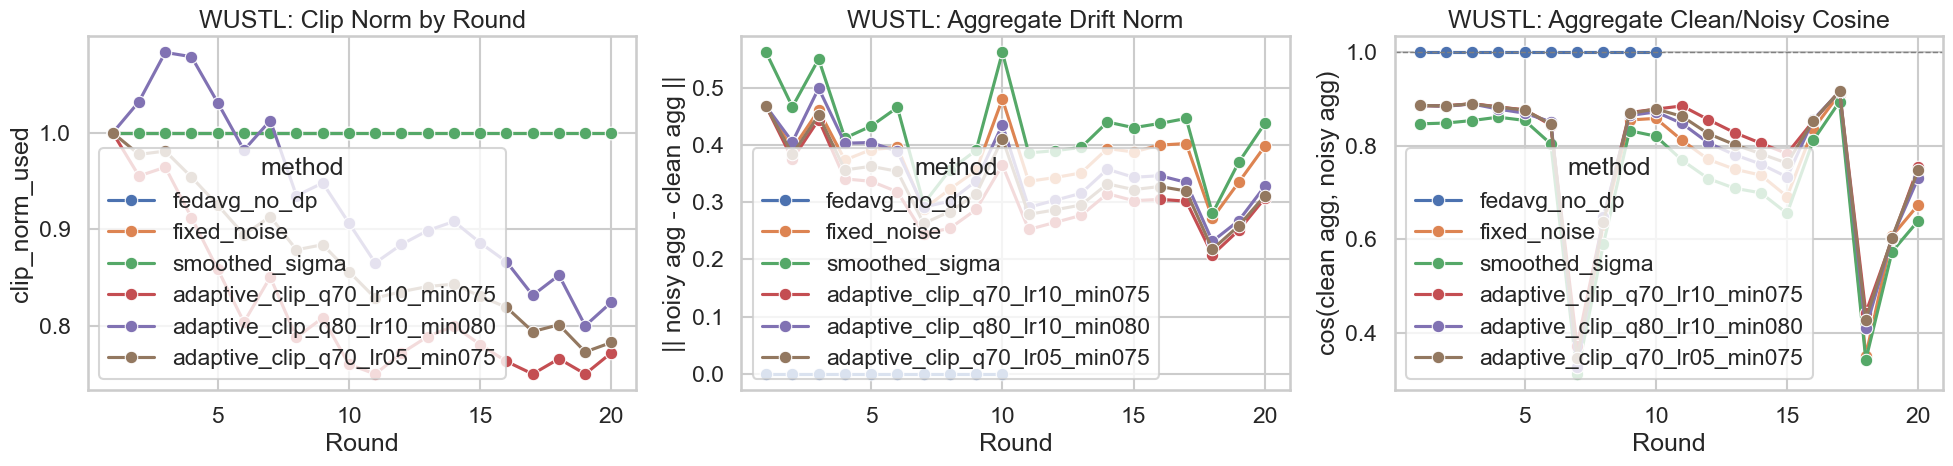

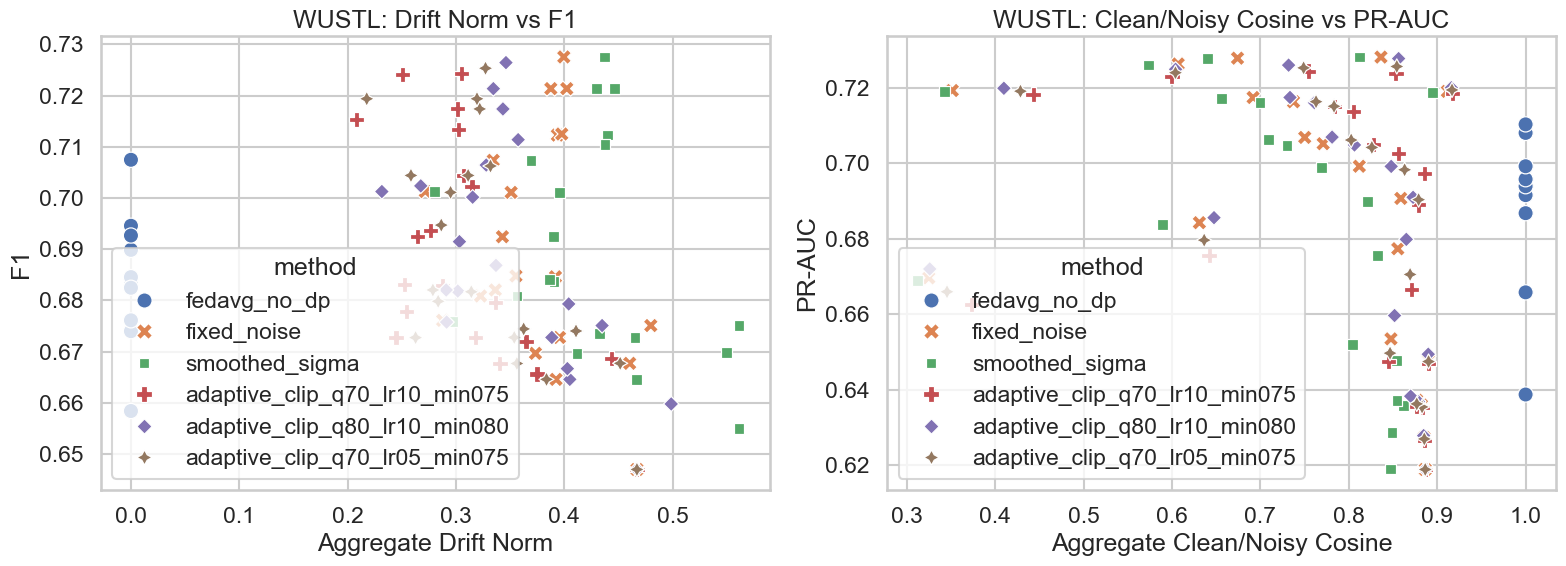

,round,clip_norm_used,clip_norm_next,aggregate_noise_drift_norm,aggregate_clean_noisy_cosine,global_step_norm,f1,pr_auc


In [47]:
# ============================================================
# NEW CELL: Plot adaptive clip norm by round + drift vs utility
# Focused on WUSTL results
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")


# ------------------------------------------------------------
# 1) Build WUSTL round-level dataframe
# ------------------------------------------------------------
wustl_round_df = pd.concat(
    [v["round_drift"].assign(method=k) for k, v in wustl_drift_results.items()],
    ignore_index=True,
)

wustl_hist_df = pd.concat(
    [v["history"].assign(method=k) for k, v in wustl_drift_results.items()],
    ignore_index=True,
)

# merge round drift with round utility
wustl_merged_df = wustl_round_df.merge(
    wustl_hist_df[["round", "method", "f1", "pr_auc", "accuracy"]],
    on=["round", "method"],
    how="left",
)


# ------------------------------------------------------------
# 2) Plot clip norm by round
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.lineplot(
    data=wustl_round_df,
    x="round",
    y="clip_norm_used",
    hue="method",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("WUSTL: Clip Norm by Round")
axes[0].set_ylabel("clip_norm_used")
axes[0].set_xlabel("Round")

sns.lineplot(
    data=wustl_round_df,
    x="round",
    y="aggregate_noise_drift_norm",
    hue="method",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("WUSTL: Aggregate Drift Norm")
axes[1].set_ylabel("|| noisy agg - clean agg ||")
axes[1].set_xlabel("Round")

sns.lineplot(
    data=wustl_round_df,
    x="round",
    y="aggregate_clean_noisy_cosine",
    hue="method",
    marker="o",
    ax=axes[2],
)
axes[2].set_title("WUSTL: Aggregate Clean/Noisy Cosine")
axes[2].set_ylabel("cos(clean agg, noisy agg)")
axes[2].set_xlabel("Round")
axes[2].axhline(1.0, linestyle="--", linewidth=1, color="gray")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3) Drift vs utility scatterplots
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=wustl_merged_df,
    x="aggregate_noise_drift_norm",
    y="f1",
    hue="method",
    style="method",
    s=120,
    ax=axes[0],
)
axes[0].set_title("WUSTL: Drift Norm vs F1")
axes[0].set_xlabel("Aggregate Drift Norm")
axes[0].set_ylabel("F1")

sns.scatterplot(
    data=wustl_merged_df,
    x="aggregate_clean_noisy_cosine",
    y="pr_auc",
    hue="method",
    style="method",
    s=120,
    ax=axes[1],
)
axes[1].set_title("WUSTL: Clean/Noisy Cosine vs PR-AUC")
axes[1].set_xlabel("Aggregate Clean/Noisy Cosine")
axes[1].set_ylabel("PR-AUC")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4) Small summary table for adaptive_clip only
# ------------------------------------------------------------
adaptive_clip_rounds = wustl_merged_df[wustl_merged_df["method"] == "adaptive_clip"].copy()

display(
    adaptive_clip_rounds[
        [
            "round",
            "clip_norm_used",
            "clip_norm_next",
            "aggregate_noise_drift_norm",
            "aggregate_clean_noisy_cosine",
            "global_step_norm",
            "f1",
            "pr_auc",
        ]
    ].round(4)
)

In [48]:
# ============================================================
# FINAL TUNING CELL: focused WUSTL adaptive-clip sweep
# - keeps variant names visible
# - compares against fixed + smoothed baselines
# ============================================================

ecu_bundle_to_test = ecu_strict_bundle
wustl_bundle_to_test = wustl_strict_bundle

# ------------------------------------------------------------
# Baselines
# ------------------------------------------------------------
drift_cfg_no_dp = replace(
    base_cfg,
    dp_strategy="fedavg_no_dp",
    verbose=True,
)

drift_cfg_fixed = replace(
    base_cfg,
    dp_strategy="fixed_noise",
    base_sigma=0.01,
    sigma_min=0.0,
    sigma_max=1.0,
    verbose=True,
)

drift_cfg_smooth = replace(
    base_cfg,
    dp_strategy="smoothed_sigma",
    base_sigma=0.01,
    sigma_min=0.001,
    sigma_max=0.10,
    sigma_smoothing=0.8,
    sigma_scale_beta=0.15,
    verbose=True,
)

# ------------------------------------------------------------
# Final adaptive-clip variants
# ------------------------------------------------------------
# Variant A: slightly looser clipping
drift_cfg_clip_q85_lr10_min085 = replace(
    base_cfg,
    dp_strategy="adaptive_clip",
    base_sigma=0.01,
    sigma_min=0.0,
    sigma_max=1.0,
    clip_norm=1.0,
    adaptive_clip_quantile=0.85,
    adaptive_clip_lr=0.10,
    clip_min=0.85,
    clip_max=2.0,
    verbose=True,
)

# Variant B: same quantile region, slower adaptation
drift_cfg_clip_q80_lr05_min080 = replace(
    base_cfg,
    dp_strategy="adaptive_clip",
    base_sigma=0.01,
    sigma_min=0.0,
    sigma_max=1.0,
    clip_norm=1.0,
    adaptive_clip_quantile=0.80,
    adaptive_clip_lr=0.05,
    clip_min=0.80,
    clip_max=2.0,
    verbose=True,
)

# ------------------------------------------------------------
# ECU runs (smaller reference set only)
# ------------------------------------------------------------
ecu_drift_results = {
    "fedavg_no_dp": run_experiment_with_drift(ecu_bundle_to_test, drift_cfg_no_dp),
    "fixed_noise": run_experiment_with_drift(ecu_bundle_to_test, drift_cfg_fixed),
    "smoothed_sigma": run_experiment_with_drift(ecu_bundle_to_test, drift_cfg_smooth),
    "adaptive_clip_q85_lr10_min085": run_experiment_with_drift(
        ecu_bundle_to_test, drift_cfg_clip_q85_lr10_min085
    ),
    "adaptive_clip_q80_lr05_min080": run_experiment_with_drift(
        ecu_bundle_to_test, drift_cfg_clip_q80_lr05_min080
    ),
}

# ------------------------------------------------------------
# WUSTL runs (main drift benchmark)
# ------------------------------------------------------------
wustl_drift_results = {
    "fedavg_no_dp": run_experiment_with_drift(wustl_bundle_to_test, drift_cfg_no_dp),
    "fixed_noise": run_experiment_with_drift(wustl_bundle_to_test, drift_cfg_fixed),
    "smoothed_sigma": run_experiment_with_drift(wustl_bundle_to_test, drift_cfg_smooth),
    "adaptive_clip_q85_lr10_min085": run_experiment_with_drift(
        wustl_bundle_to_test, drift_cfg_clip_q85_lr10_min085
    ),
    "adaptive_clip_q80_lr05_min080": run_experiment_with_drift(
        wustl_bundle_to_test, drift_cfg_clip_q80_lr05_min080
    ),
}

# ------------------------------------------------------------
# Summary helper that preserves method key
# ------------------------------------------------------------
def summarize_named_drift_results(result_dict, dataset_name):
    rows = []
    for method_name, result in result_dict.items():
        round_df = result["round_drift"].copy()

        row = {
            "dataset": dataset_name,
            "method": method_name,
            "best_round": result["summary"]["best_round"],
            "best_f1": result["summary"]["f1"],
            "best_pr_auc": result["summary"]["pr_auc"],
            "best_auc": result["summary"]["auc"],
            "mean_agg_drift_norm": round_df["aggregate_noise_drift_norm"].mean(),
            "mean_agg_drift_relative": round_df["aggregate_noise_drift_relative"].mean(),
            "mean_agg_clean_noisy_cosine": round_df["aggregate_clean_noisy_cosine"].mean(),
            "mean_global_step_norm": round_df["global_step_norm"].mean(),
        }
        rows.append(row)

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# Build summaries
# ------------------------------------------------------------
ecu_drift_summary = summarize_named_drift_results(ecu_drift_results, "ECU_strict_no_id")
wustl_drift_summary = summarize_named_drift_results(wustl_drift_results, "WUSTL_strict_no_id")

print("ECU drift summary")
display(ecu_drift_summary.sort_values(["best_f1", "best_pr_auc"], ascending=False))

print("WUSTL drift summary")
display(wustl_drift_summary.sort_values(["best_f1", "best_pr_auc"], ascending=False))

# Main ranking view for WUSTL
wustl_rank_view = wustl_drift_summary[
    [
        "method",
        "best_round",
        "best_f1",
        "best_pr_auc",
        "best_auc",
        "mean_agg_drift_norm",
        "mean_agg_drift_relative",
        "mean_agg_clean_noisy_cosine",
        "mean_global_step_norm",
    ]
].sort_values(["best_f1", "best_pr_auc"], ascending=False)

print("WUSTL ranking view")
display(wustl_rank_view)

[Round 01] f1=0.9695 pr_auc=0.9945 drift=0.0000 cos=1.0000 clip=1.0000
[Round 02] f1=0.9866 pr_auc=0.9971 drift=0.0000 cos=1.0000 clip=1.0000
[Round 03] f1=0.9876 pr_auc=0.9974 drift=0.0000 cos=1.0000 clip=1.0000
[Round 04] f1=0.9876 pr_auc=0.9974 drift=0.0000 cos=1.0000 clip=1.0000
[Round 05] f1=0.9876 pr_auc=0.9975 drift=0.0000 cos=1.0000 clip=1.0000
[Round 06] f1=0.9888 pr_auc=0.9978 drift=0.0000 cos=1.0000 clip=1.0000
[Round 07] f1=0.9887 pr_auc=0.9978 drift=0.0000 cos=1.0000 clip=1.0000
[Round 08] f1=0.9888 pr_auc=0.9978 drift=0.0000 cos=1.0000 clip=1.0000
[Round 09] f1=0.9887 pr_auc=0.9978 drift=0.0000 cos=1.0000 clip=1.0000
[Round 10] f1=0.9888 pr_auc=0.9978 drift=0.0000 cos=1.0000 clip=1.0000
[Round 11] f1=0.9885 pr_auc=0.9977 drift=0.0000 cos=1.0000 clip=1.0000
Early stopping at round 11 (best val_f1 at round 6).
[Round 01] f1=0.9688 pr_auc=0.9943 drift=0.2079 cos=0.9652 clip=1.0000
[Round 02] f1=0.9788 pr_auc=0.9959 drift=0.1851 cos=0.9708 clip=1.0000
[Round 03] f1=0.9870 pr_

,dataset,method,best_round,best_f1,best_pr_auc,best_auc,mean_agg_drift_norm,mean_agg_drift_relative,mean_agg_clean_noisy_cosine,mean_global_step_norm
4,ECU_strict_no_id,adaptive_clip_q80_lr05_min080,12,0.989075,0.997898,0.993854,0.279840,0.374936,0.932043,0.986546
3,ECU_strict_no_id,adaptive_clip_q85_lr10_min085,8,0.989075,0.997897,0.993853,0.344431,0.441669,0.917697,1.203054
0,ECU_strict_no_id,fedavg_no_dp,6,0.988755,0.997779,0.993327,0.000000,0.000000,1.000000,1.881012
2,ECU_strict_no_id,smoothed_sigma,11,0.988670,0.997755,0.993226,0.272750,0.377721,0.931780,0.866683
1,ECU_strict_no_id,fixed_noise,11,0.988670,0.997755,0.993226,0.228953,0.326654,0.945258,0.852498


WUSTL drift summary


,dataset,method,best_round,best_f1,best_pr_auc,best_auc,mean_agg_drift_norm,mean_agg_drift_relative,mean_agg_clean_noisy_cosine,mean_global_step_norm
3,WUSTL_strict_no_id,adaptive_clip_q85_lr10_min085,16,0.727549,0.729175,0.858543,0.376400,0.936035,0.758132,0.666947
2,WUSTL_strict_no_id,smoothed_sigma,16,0.727549,0.728169,0.857822,0.425179,1.040792,0.722641,0.692378
1,WUSTL_strict_no_id,fixed_noise,16,0.727549,0.728133,0.857563,0.377137,0.948218,0.754094,0.663800
4,WUSTL_strict_no_id,adaptive_clip_q80_lr05_min080,16,0.727549,0.728111,0.857517,0.363059,0.913577,0.763977,0.652207
0,WUSTL_strict_no_id,fedavg_no_dp,5,0.707463,0.708035,0.855750,0.000000,0.000000,1.000000,0.900741


WUSTL ranking view


,method,best_round,best_f1,best_pr_auc,best_auc,mean_agg_drift_norm,mean_agg_drift_relative,mean_agg_clean_noisy_cosine,mean_global_step_norm
3,adaptive_clip_q85_lr10_min085,16,0.727549,0.729175,0.858543,0.376400,0.936035,0.758132,0.666947
2,smoothed_sigma,16,0.727549,0.728169,0.857822,0.425179,1.040792,0.722641,0.692378
1,fixed_noise,16,0.727549,0.728133,0.857563,0.377137,0.948218,0.754094,0.663800
4,adaptive_clip_q80_lr05_min080,16,0.727549,0.728111,0.857517,0.363059,0.913577,0.763977,0.652207
0,fedavg_no_dp,5,0.707463,0.708035,0.855750,0.000000,0.000000,1.000000,0.900741


In [49]:
# ============================================================
# MULTI-SEED FINAL EVALUATION
# - final four methods only
# - repeats on ECU + WUSTL
# - produces mean/std summary tables
# ============================================================

import numpy as np
import pandas as pd
from dataclasses import replace

# -----------------------------------------------
# Choose seeds
# -----------------------------------------------
multi_seeds = [11, 22, 33, 44, 55]

# -----------------------------------------------
# Final method configs
# -----------------------------------------------
final_method_cfgs = {
    "fedavg_no_dp": replace(
        base_cfg,
        dp_strategy="fedavg_no_dp",
        verbose=False,
    ),
    "fixed_noise": replace(
        base_cfg,
        dp_strategy="fixed_noise",
        base_sigma=0.01,
        sigma_min=0.0,
        sigma_max=1.0,
        verbose=False,
    ),
    "smoothed_sigma": replace(
        base_cfg,
        dp_strategy="smoothed_sigma",
        base_sigma=0.01,
        sigma_min=0.001,
        sigma_max=0.10,
        sigma_smoothing=0.8,
        sigma_scale_beta=0.15,
        verbose=False,
    ),
    "adaptive_clip_q85_lr10_min085": replace(
        base_cfg,
        dp_strategy="adaptive_clip",
        base_sigma=0.01,
        sigma_min=0.0,
        sigma_max=1.0,
        clip_norm=1.0,
        adaptive_clip_quantile=0.85,
        adaptive_clip_lr=0.10,
        clip_min=0.85,
        clip_max=2.0,
        verbose=False,
    ),
}

# -----------------------------------------------
# Bundles
# -----------------------------------------------
final_bundles = {
    "ECU_strict_no_id": ecu_strict_bundle,
    "WUSTL_strict_no_id": wustl_strict_bundle,
}

# -----------------------------------------------
# Run repeated experiments
# -----------------------------------------------
multi_seed_rows = []
multi_seed_round_rows = []

# I am making this so I can do client specific trends
results_for_plotting = { "ECU_strict_no_id": {}, "WUSTL_strict_no_id": {}}

for dataset_name, bundle in final_bundles.items():
    print(f"\n===== Running multi-seed evaluation for {dataset_name} =====")

    for method_name, cfg_template in final_method_cfgs.items():
        print(f"  -> Method: {method_name}")

        for seed in multi_seeds:
            cfg = replace(cfg_template, seed=seed)

            result = run_experiment_with_drift(bundle, cfg)
            
            # I am just picking this seed randomly
            if seed == multi_seeds[0]:
                results_for_plotting[dataset_name][method_name] = result

            summary = result["summary"]
            round_df = result["round_drift"].copy()

            multi_seed_rows.append({
                "dataset": dataset_name,
                "method": method_name,
                "seed": seed,
                "best_round": summary["best_round"],
                "accuracy": summary["accuracy"],
                "precision": summary["precision"],
                "recall": summary["recall"],
                "f1": summary["f1"],
                "auc": summary["auc"],
                "pr_auc": summary["pr_auc"],
                "threshold": summary["threshold"],
                "val_f1": summary["val_f1"],
                "mean_agg_drift_norm": round_df["aggregate_noise_drift_norm"].mean(),
                "mean_agg_drift_relative": round_df["aggregate_noise_drift_relative"].mean(),
                "mean_agg_clean_noisy_cosine": round_df["aggregate_clean_noisy_cosine"].mean(),
                "mean_global_step_norm": round_df["global_step_norm"].mean(),
            })

            tmp_round = round_df.copy()
            tmp_round["dataset"] = dataset_name
            tmp_round["method"] = method_name
            tmp_round["seed"] = seed
            multi_seed_round_rows.append(tmp_round)

multi_seed_df = pd.DataFrame(multi_seed_rows)
multi_seed_round_df = pd.concat(multi_seed_round_rows, ignore_index=True)

# -----------------------------------------------
# Aggregate summary
# -----------------------------------------------
multi_seed_summary = (
    multi_seed_df
    .groupby(["dataset", "method"], as_index=False)
    .agg(
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std"),
        val_f1_mean=("val_f1", "mean"),
        drift_mean=("mean_agg_drift_norm", "mean"),
        drift_std=("mean_agg_drift_norm", "std"),
        rel_drift_mean=("mean_agg_drift_relative", "mean"),
        cosine_mean=("mean_agg_clean_noisy_cosine", "mean"),
        cosine_std=("mean_agg_clean_noisy_cosine", "std"),
        global_step_mean=("mean_global_step_norm", "mean"),
        global_step_std=("mean_global_step_norm", "std"),
    )
)

# -----------------------------------------------
# Display
# -----------------------------------------------
print("\nFull per-seed results:")
display(multi_seed_df.sort_values(["dataset", "method", "seed"]))

print("\nMulti-seed summary:")
display(
    multi_seed_summary.sort_values(["dataset", "f1_mean", "pr_auc_mean"], ascending=[True, False, False])
)

# Separate ranking views
ecu_multi_seed_summary = multi_seed_summary[multi_seed_summary["dataset"] == "ECU_strict_no_id"].copy()
wustl_multi_seed_summary = multi_seed_summary[multi_seed_summary["dataset"] == "WUSTL_strict_no_id"].copy()

print("\nECU ranking view")
display(ecu_multi_seed_summary.sort_values(["f1_mean", "pr_auc_mean"], ascending=False))

print("\nWUSTL ranking view")
display(wustl_multi_seed_summary.sort_values(["f1_mean", "pr_auc_mean"], ascending=False))

# -----------------------------------------------
# Optional save
# -----------------------------------------------
# multi_seed_df.to_csv("final_multi_seed_results.csv", index=False)
# multi_seed_round_df.to_csv("final_multi_seed_round_results.csv", index=False)
# multi_seed_summary.to_csv("final_multi_seed_summary.csv", index=False)


===== Running multi-seed evaluation for ECU_strict_no_id =====
  -> Method: fedavg_no_dp
  -> Method: fixed_noise
  -> Method: smoothed_sigma
  -> Method: adaptive_clip_q85_lr10_min085

===== Running multi-seed evaluation for WUSTL_strict_no_id =====
  -> Method: fedavg_no_dp
  -> Method: fixed_noise
  -> Method: smoothed_sigma
  -> Method: adaptive_clip_q85_lr10_min085

Full per-seed results:


,dataset,method,seed,best_round,accuracy,precision,recall,f1,auc,pr_auc,threshold,val_f1,mean_agg_drift_norm,mean_agg_drift_relative,mean_agg_clean_noisy_cosine,mean_global_step_norm
15,ECU_strict_no_id,adaptive_clip_q85_lr10_min085,11,10,0.983005,0.985579,0.992992,0.989272,0.993941,0.997922,0.090307,0.987952,0.347471,0.369148,0.933041,1.169211
16,ECU_strict_no_id,adaptive_clip_q85_lr10_min085,22,3,0.980083,0.985306,0.989516,0.987407,0.990854,0.997242,0.514880,0.986299,0.312782,0.272494,0.964849,1.184014
17,ECU_strict_no_id,adaptive_clip_q85_lr10_min085,33,14,0.982196,0.985620,0.991909,0.988754,0.993311,0.997775,0.038812,0.987665,0.343726,0.517111,0.910574,1.146227
18,ECU_strict_no_id,adaptive_clip_q85_lr10_min085,44,1,0.980128,0.985362,0.989516,0.987435,0.990803,0.997234,0.452848,0.986299,0.355255,0.279782,0.962801,1.312282
19,ECU_strict_no_id,adaptive_clip_q85_lr10_min085,55,7,0.982241,0.985456,0.992137,0.988785,0.993850,0.997897,0.169655,0.987665,0.316252,0.364992,0.936921,1.044616
0,ECU_strict_no_id,fedavg_no_dp,11,5,0.983005,0.985579,0.992992,0.989272,0.993953,0.997925,0.092411,0.987952,0.000000,0.000000,1.000000,1.720556
1,ECU_strict_no_id,fedavg_no_dp,22,9,0.982151,0.985619,0.991852,0.988726,0.993246,0.997760,0.688931,0.987665,0.000000,0.000000,1.000000,1.918932
2,ECU_strict_no_id,fedavg_no_dp,33,9,0.982196,0.985565,0.991966,0.988755,0.993584,0.997832,0.075350,0.987665,0.000000,0.000000,1.000000,1.483457
3,ECU_strict_no_id,fedavg_no_dp,44,8,0.982780,0.985301,0.992992,0.989131,0.993890,0.997907,0.071416,0.987882,0.000000,0.000000,1.000000,1.801555
4,ECU_strict_no_id,fedavg_no_dp,55,10,0.983005,0.985579,0.992992,0.989272,0.994818,0.998111,0.117409,0.987952,0.000000,0.000000,1.000000,1.480685



Multi-seed summary:


,dataset,method,f1_mean,f1_std,pr_auc_mean,pr_auc_std,auc_mean,auc_std,val_f1_mean,drift_mean,drift_std,rel_drift_mean,cosine_mean,cosine_std,global_step_mean,global_step_std
1,ECU_strict_no_id,fedavg_no_dp,0.989031,0.000272,0.997907,0.000131,0.993898,0.000586,0.987823,0.000000,0.000000,0.000000,1.000000,1.746238e-08,1.681037,0.194846
0,ECU_strict_no_id,adaptive_clip_q85_lr10_min085,0.988330,0.000856,0.997614,0.000348,0.992552,0.001591,0.987176,0.335097,0.019281,0.360706,0.941637,2.262601e-02,1.171270,0.095811
2,ECU_strict_no_id,fixed_noise,0.987867,0.000593,0.997445,0.000264,0.991801,0.001232,0.986747,0.236565,0.009120,0.279510,0.962872,3.018883e-03,0.888880,0.036746
3,ECU_strict_no_id,smoothed_sigma,0.987861,0.000582,0.997446,0.000263,0.991803,0.001228,0.986747,0.288693,0.016036,0.338838,0.946976,2.897563e-03,0.903914,0.038071
4,WUSTL_strict_no_id,adaptive_clip_q85_lr10_min085,0.706322,0.013853,0.723065,0.016122,0.862624,0.012326,0.685436,0.381417,0.022194,0.787507,0.803104,3.020229e-02,0.735802,0.064814
5,WUSTL_strict_no_id,fedavg_no_dp,0.700145,0.003200,0.711573,0.007337,0.853471,0.007455,0.680880,0.000000,0.000000,0.000000,1.000000,1.970535e-08,0.817095,0.068581
7,WUSTL_strict_no_id,smoothed_sigma,0.699367,0.019272,0.721673,0.017309,0.863710,0.010561,0.684321,0.425864,0.015528,0.858245,0.779546,3.196300e-02,0.760335,0.049514
6,WUSTL_strict_no_id,fixed_noise,0.699146,0.019112,0.721415,0.017334,0.863394,0.010569,0.684321,0.376671,0.011075,0.775546,0.808044,3.175751e-02,0.734203,0.047850



ECU ranking view


,dataset,method,f1_mean,f1_std,pr_auc_mean,pr_auc_std,auc_mean,auc_std,val_f1_mean,drift_mean,drift_std,rel_drift_mean,cosine_mean,cosine_std,global_step_mean,global_step_std
1,ECU_strict_no_id,fedavg_no_dp,0.989031,0.000272,0.997907,0.000131,0.993898,0.000586,0.987823,0.000000,0.000000,0.000000,1.000000,1.746238e-08,1.681037,0.194846
0,ECU_strict_no_id,adaptive_clip_q85_lr10_min085,0.988330,0.000856,0.997614,0.000348,0.992552,0.001591,0.987176,0.335097,0.019281,0.360706,0.941637,2.262601e-02,1.171270,0.095811
2,ECU_strict_no_id,fixed_noise,0.987867,0.000593,0.997445,0.000264,0.991801,0.001232,0.986747,0.236565,0.009120,0.279510,0.962872,3.018883e-03,0.888880,0.036746
3,ECU_strict_no_id,smoothed_sigma,0.987861,0.000582,0.997446,0.000263,0.991803,0.001228,0.986747,0.288693,0.016036,0.338838,0.946976,2.897563e-03,0.903914,0.038071



WUSTL ranking view


,dataset,method,f1_mean,f1_std,pr_auc_mean,pr_auc_std,auc_mean,auc_std,val_f1_mean,drift_mean,drift_std,rel_drift_mean,cosine_mean,cosine_std,global_step_mean,global_step_std
4,WUSTL_strict_no_id,adaptive_clip_q85_lr10_min085,0.706322,0.013853,0.723065,0.016122,0.862624,0.012326,0.685436,0.381417,0.022194,0.787507,0.803104,3.020229e-02,0.735802,0.064814
5,WUSTL_strict_no_id,fedavg_no_dp,0.700145,0.003200,0.711573,0.007337,0.853471,0.007455,0.680880,0.000000,0.000000,0.000000,1.000000,1.970535e-08,0.817095,0.068581
7,WUSTL_strict_no_id,smoothed_sigma,0.699367,0.019272,0.721673,0.017309,0.863710,0.010561,0.684321,0.425864,0.015528,0.858245,0.779546,3.196300e-02,0.760335,0.049514
6,WUSTL_strict_no_id,fixed_noise,0.699146,0.019112,0.721415,0.017334,0.863394,0.010569,0.684321,0.376671,0.011075,0.775546,0.808044,3.175751e-02,0.734203,0.047850


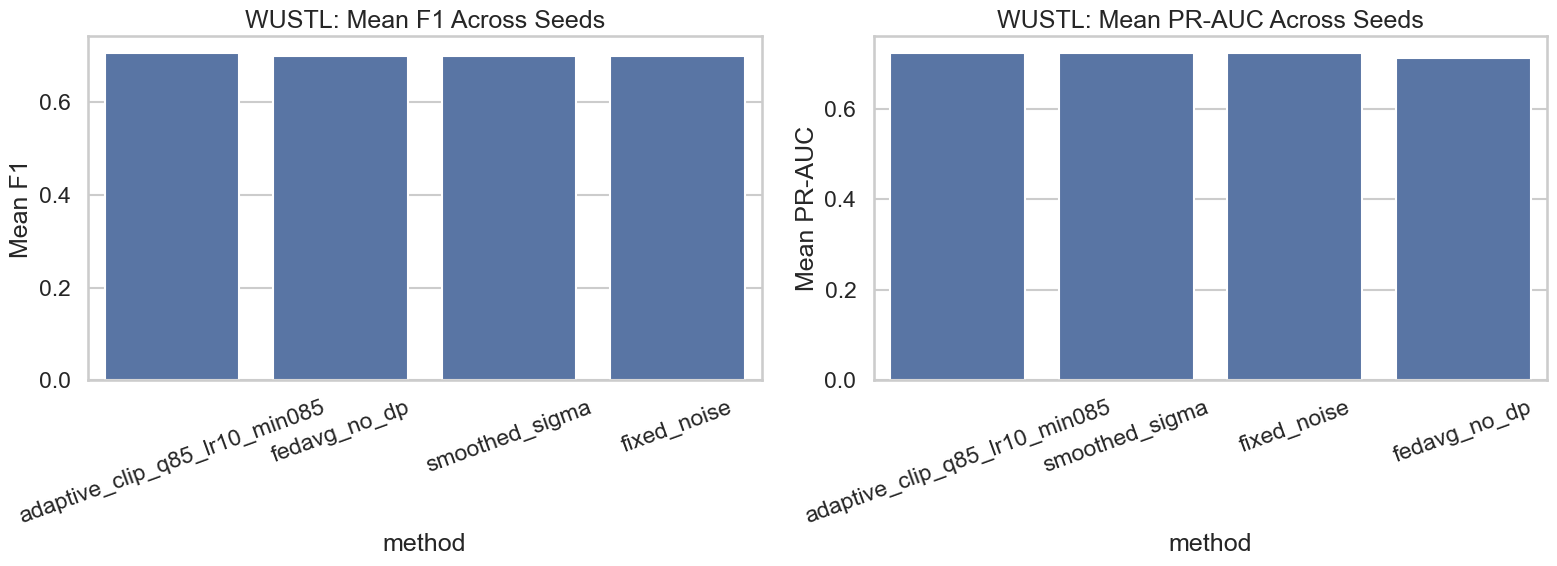

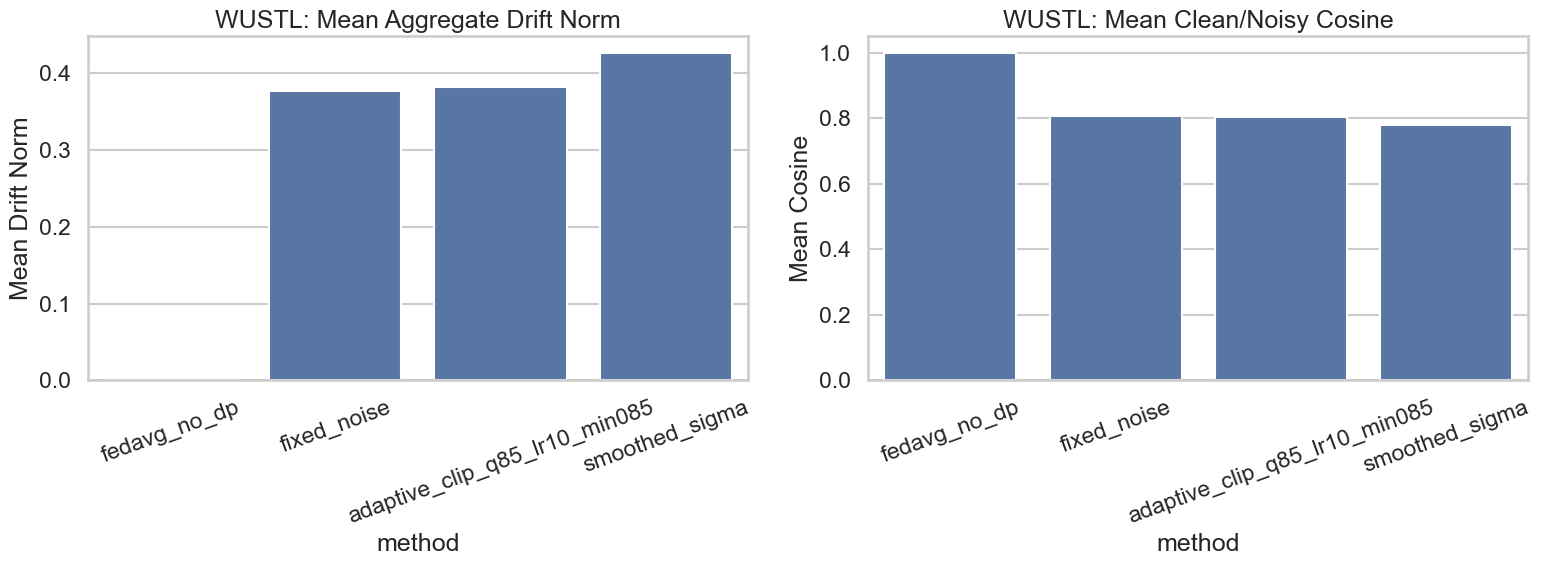

In [50]:
# ============================================================
# MULTI-SEED SUMMARY PLOTS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=wustl_multi_seed_summary.sort_values("f1_mean", ascending=False),
    x="method",
    y="f1_mean",
    ax=axes[0],
)
axes[0].set_title("WUSTL: Mean F1 Across Seeds")
axes[0].set_ylabel("Mean F1")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=wustl_multi_seed_summary.sort_values("pr_auc_mean", ascending=False),
    x="method",
    y="pr_auc_mean",
    ax=axes[1],
)
axes[1].set_title("WUSTL: Mean PR-AUC Across Seeds")
axes[1].set_ylabel("Mean PR-AUC")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=wustl_multi_seed_summary.sort_values("drift_mean", ascending=True),
    x="method",
    y="drift_mean",
    ax=axes[0],
)
axes[0].set_title("WUSTL: Mean Aggregate Drift Norm")
axes[0].set_ylabel("Mean Drift Norm")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=wustl_multi_seed_summary.sort_values("cosine_mean", ascending=False),
    x="method",
    y="cosine_mean",
    ax=axes[1],
)
axes[1].set_title("WUSTL: Mean Clean/Noisy Cosine")
axes[1].set_ylabel("Mean Cosine")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
# plt.show()

In [51]:
# plot_sigma_diagnostics(
#     results_for_plotting["ECU_strict_no_id"]["smoothed_sigma"], 
#     "ECU Strict No-ID - Smoothed Sigma (Seed 11)"
# )

# plot_sigma_diagnostics(
#     results_for_plotting["WUSTL_strict_no_id"]["smoothed_sigma"], 
#     "WUSTL Strict No-ID - Smoothed Sigma (Seed 11)"
# )

In [52]:
def plot_final_metric_comparison(
    dataset_results: Dict[str, Dict[str, Any]],
    dataset_title: str,
):
    method_specs = [
        # key, display label, color
        ("fedavg_no_dp", "fedavg_no_dp", "red"),
        ("fixed_noise", "fixed_noise", None),
        ("smoothed_sigma", "smoothed_sigma", None),
        ("adaptive_clip_q85_lr10_min085", "adaptive_clip", None),
    ]

    metrics = ["f1", "pr_auc"]

    available_keys = set(dataset_results.keys())
    missing_keys = [key for key, _, _ in method_specs if key not in available_keys]

    if missing_keys:
        raise KeyError(
            "Missing methods: "
            f"{missing_keys}. Available methods are: {sorted(available_keys)}"
        )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    legend_handles = []
    legend_labels = []

    for ax, metric in zip(axes, metrics):
        for method_key, display_label, color in method_specs:
            hist = dataset_results[method_key]["history"]

            if "round" not in hist.columns:
                raise KeyError(
                    f"'round' column missing for {method_key}. "
                    f"Available columns: {list(hist.columns)}"
                )

            if metric not in hist.columns:
                raise KeyError(
                    f"'{metric}' column missing for {method_key}. "
                    f"Available columns: {list(hist.columns)}"
                )

            kwargs = {
                "marker": "o",
                "markersize": 4,
                "linewidth": 1.8,
                "label": display_label,
            }

            if color is not None:
                kwargs["color"] = color

            line, = ax.plot(
                hist["round"],
                hist[metric],
                **kwargs,
            )

            if metric == metrics[0]:
                legend_handles.append(line)
                legend_labels.append(display_label)

    
        ax.set_title(f"{dataset_title} - {metric}")
        ax.set_xlabel("Round")
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.05)

    fig.legend(
        legend_handles,
        legend_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.07),
        ncol=4,
        frameon=False,
    )

    fig.tight_layout(rect=(0, 0.12, 1, 1))
    plt.show()
    
# plot_final_metric_comparison(
#     results_for_plotting["ECU_strict_no_id"],
#     "ECU Strict No-ID"
# )

# plot_final_metric_comparison(
#     results_for_plotting["WUSTL_strict_no_id"],
#     "WUSTL Strict"
# )

In [53]:
# ============================================================
# FINAL MIA EVALUATION: four methods from results_for_plotting
# ============================================================

final_mia_method_specs = [
    # method key in results_for_plotting, display label, color
    ("fedavg_no_dp", "No DP", "red"),
    ("fixed_noise", "Flat DP", None),
    ("smoothed_sigma", "Smoothed Sigma", None),
    ("adaptive_clip_q85_lr10_min085", "Adaptive Clip", None),
]


def evaluate_mia_from_result_dict(
    result_dict: Dict[str, Dict[str, Any]],
    bundle: Dict[str, Any],
    dataset_name: str,
    cfg,
    method_specs,
    num_per_target_class: int = 500,
    mia_seed: int = 42,
):
    available_keys = set(result_dict.keys())
    missing_keys = [key for key, _, _ in method_specs if key not in available_keys]

    if missing_keys:
        raise KeyError(
            "Missing methods: "
            f"{missing_keys}. Available methods are: {sorted(available_keys)}"
        )

    print(f"\n--- Running final four-method MIA for {dataset_name} ---")

    rows = []

    for method_key, display_label, _ in method_specs:
        result = result_dict[method_key]

        model = load_model_from_state(bundle, result, cfg)
        check_model_state_finite(model, f"{dataset_name} / {method_key}")

        report = run_whitebox_mia(
            target_model=model,
            bundle=bundle,
            num_per_target_class=num_per_target_class,
            seed=mia_seed,
        )

        rows.append({
            "Dataset": dataset_name,
            "method": method_key,
            "Strategy": display_label,
            **report,
        })

        print(
            f"{display_label:16s} "
            f"Acc={report['mia_accuracy'] * 100:6.2f}% | "
            f"AUC={report['mia_auc']:.3f} | "
            f"Adv={report['mia_advantage']:.3f} | "
            f"LossAUC={report['loss_only_auc']:.3f}"
        )

    return pd.DataFrame(rows)

In [54]:
mia_results_final_four = pd.concat(
    [
        evaluate_mia_from_result_dict(
            results_for_plotting["ECU_strict_no_id"],
            ecu_strict_bundle,
            "ECU Strict",
            base_cfg,
            final_mia_method_specs,
            mia_seed=base_cfg.seed,
        ),
        evaluate_mia_from_result_dict(
            results_for_plotting["WUSTL_strict_no_id"],
            wustl_strict_bundle,
            "WUSTL Strict",
            base_cfg,
            final_mia_method_specs,
            mia_seed=base_cfg.seed,
        ),
    ],
    ignore_index=True,
)

# display(mia_results_final_four)


--- Running final four-method MIA for ECU Strict ---
No DP            Acc= 51.33% | AUC=0.513 | Adv=0.027 | LossAUC=0.514
Flat DP          Acc= 51.50% | AUC=0.525 | Adv=0.051 | LossAUC=0.502
Smoothed Sigma   Acc= 51.67% | AUC=0.528 | Adv=0.055 | LossAUC=0.502
Adaptive Clip    Acc= 51.33% | AUC=0.516 | Adv=0.033 | LossAUC=0.505

--- Running final four-method MIA for WUSTL Strict ---
No DP            Acc= 49.91% | AUC=0.504 | Adv=0.008 | LossAUC=0.479
Flat DP          Acc= 49.74% | AUC=0.520 | Adv=0.041 | LossAUC=0.482
Smoothed Sigma   Acc= 49.74% | AUC=0.523 | Adv=0.045 | LossAUC=0.482
Adaptive Clip    Acc= 50.26% | AUC=0.514 | Adv=0.029 | LossAUC=0.482


In [55]:
# plot_mia_auc_delta_bar_split()

In [56]:
def plot_mia_auc_delta_bar_split(
    mia_df: pd.DataFrame,
):
    df = mia_df.copy()

    dataset_order = [
        "ECU Strict",
        "WUSTL Strict",
    ]

    full_strategy_order = [
        "No DP",
        "Flat DP",
        "Smoothed Sigma",
        "Adaptive Clip",
    ]

    plot_strategy_order = [
        "Flat DP",
        "Smoothed Sigma",
        "Adaptive Clip",
    ]

    available_datasets = set(df["Dataset"])
    missing_datasets = [d for d in dataset_order if d not in available_datasets]

    if missing_datasets:
        raise KeyError(
            "Missing datasets: "
            f"{missing_datasets}. Available datasets are: {sorted(available_datasets)}"
        )

    available_strategies = set(df["Strategy"])
    missing_strategies = [s for s in full_strategy_order if s not in available_strategies]

    if missing_strategies:
        raise KeyError(
            "Missing strategies: "
            f"{missing_strategies}. Available strategies are: {sorted(available_strategies)}"
        )

    duplicate_rows = df.duplicated(["Dataset", "Strategy"], keep=False)
    if duplicate_rows.any():
        raise ValueError(
            "Duplicate Dataset/Strategy rows found. "
            "Each dataset should have exactly one row per final method.\n\n"
            f"{df.loc[duplicate_rows, ['Dataset', 'Strategy', 'method', 'mia_auc']]}"
        )

    baseline = (
        df[df["Strategy"] == "No DP"]
        [["Dataset", "mia_auc"]]
        .rename(columns={"mia_auc": "no_dp_mia_auc"})
    )

    df = df.merge(baseline, on="Dataset", how="left")

    if df["no_dp_mia_auc"].isna().any():
        missing = df.loc[df["no_dp_mia_auc"].isna(), "Dataset"].unique()
        raise ValueError(f"Missing No-DP baseline for dataset(s): {missing}")

    df["mia_auc_delta"] = df["mia_auc"] - df["no_dp_mia_auc"]

    # Keep No DP for baseline computation, but remove it from the plotted bars.
    plot_df_all = df[df["Strategy"].isin(plot_strategy_order)].copy()

    plot_df_all["Strategy"] = pd.Categorical(
        plot_df_all["Strategy"],
        categories=plot_strategy_order,
        ordered=True,
    )
    plot_df_all["Dataset"] = pd.Categorical(
        plot_df_all["Dataset"],
        categories=dataset_order,
        ordered=True,
    )

    plot_df_all = plot_df_all.sort_values(["Dataset", "Strategy"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    legend_handles = []
    legend_labels = []

    default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    bar_colors = {
        "Flat DP": default_colors[0],
        "Smoothed Sigma": default_colors[1],
        "Adaptive Clip": default_colors[2],
    }

    all_deltas = plot_df_all["mia_auc_delta"].dropna()
    y_min = min(0.0, float(all_deltas.min()))
    y_max = max(0.0, float(all_deltas.max()))
    y_pad = max((y_max - y_min) * 0.15, 0.005)

    for ax, dataset_name in zip(axes, dataset_order):
        plot_df = (
            plot_df_all[plot_df_all["Dataset"] == dataset_name]
            .set_index("Strategy")
            .reindex(plot_strategy_order)
            .reset_index()
        )

        x = np.arange(len(plot_strategy_order))
        values = plot_df["mia_auc_delta"].to_numpy()

        bars = ax.bar(
            x,
            values,
            color=[bar_colors[strategy] for strategy in plot_strategy_order],
        )

        ax.axhline(
            0.0,
            linestyle="--",
            linewidth=1.5,
            color="black",
            alpha=0.6,
        )

        ax.set_title(f"{dataset_name} - MIA AUC Δ")
        # ax.set_xlabel("Method")
        ax.set_ylabel("MIA AUC increase over No-DP")
        # ax.set_xticks(x)
        # ax.set_xticklabels(plot_strategy_order, rotation=20, ha="right")
        ax.set_ylim(y_min - y_pad, y_max + y_pad)
        ax.grid(axis="y", alpha=0.05)

        if not legend_handles:
            legend_handles = list(bars)
            legend_labels = plot_strategy_order

    fig.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.07),
    ncol=3,
    frameon=False,
    )

    fig.tight_layout(rect=(0, 0.12, 1, 1))
    plt.show()

    display(
        df[
            [
                "Dataset",
                "method",
                "Strategy",
                "mia_auc",
                "no_dp_mia_auc",
                "mia_auc_delta",
                "mia_advantage",
                "loss_only_auc",
            ]
        ].round(4)
    )

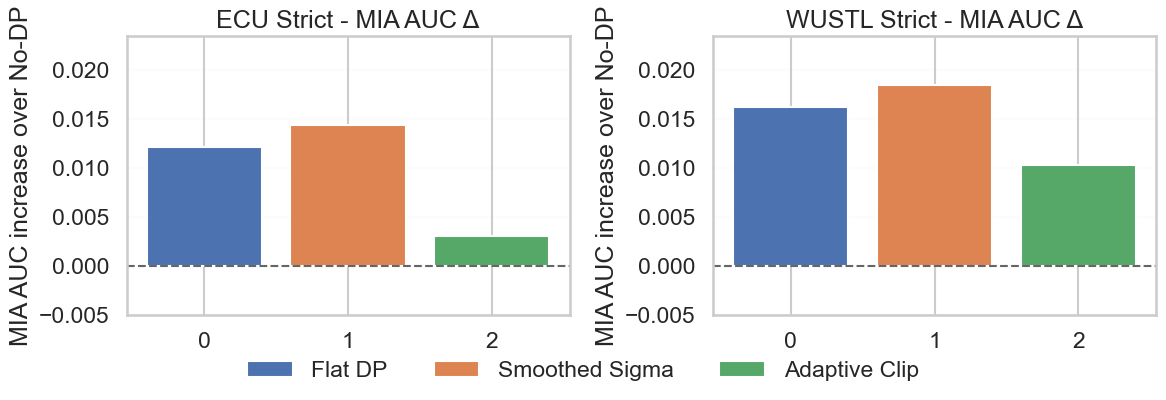

,Dataset,method,Strategy,mia_auc,no_dp_mia_auc,mia_auc_delta,mia_advantage,loss_only_auc
0,ECU Strict,fedavg_no_dp,No DP,0.5134,0.5134,0.0000,0.0268,0.5142
1,ECU Strict,fixed_noise,Flat DP,0.5255,0.5134,0.0121,0.0509,0.5018
2,ECU Strict,smoothed_sigma,Smoothed Sigma,0.5277,0.5134,0.0143,0.0554,0.5020
3,ECU Strict,adaptive_clip_q85_lr10_min085,Adaptive Clip,0.5164,0.5134,0.0031,0.0329,0.5045
4,WUSTL Strict,fedavg_no_dp,No DP,0.5041,0.5041,0.0000,0.0083,0.4785
5,WUSTL Strict,fixed_noise,Flat DP,0.5203,0.5041,0.0162,0.0406,0.4820
6,WUSTL Strict,smoothed_sigma,Smoothed Sigma,0.5226,0.5041,0.0184,0.0451,0.4823
7,WUSTL Strict,adaptive_clip_q85_lr10_min085,Adaptive Clip,0.5144,0.5041,0.0103,0.0289,0.4821


In [57]:
plot_mia_auc_delta_bar_split(mia_results_final_four)

### Strong-DP MIA sensitivity check


This final cell intentionally uses stronger noise/clipping than the selected final methods. The goal is not to replace the main results, but to test whether MIA AUC changes once utility degradation is allowed. If the relative F1 drop is still below the target, set 
RUN_VERY_STRONG_PROFILE = True
 and rerun the cell.

In [58]:
# ============================================================
# STRONG-DP SENSITIVITY CHECK
# - purpose: test whether a deliberately stronger DP setting
#   can move MIA AUC when we allow noticeable utility loss
# - uses the same final ECU/WUSTL bundles and MIA helper code
# ============================================================

from dataclasses import replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Configuration knobs
# ------------------------------------------------------------
STRONG_DP_SEED = multi_seeds[0] if "multi_seeds" in globals() else base_cfg.seed
STRONG_MIA_SEED = base_cfg.seed
STRONG_MIA_NUM_PER_TARGET_CLASS = 500
TARGET_RELATIVE_F1_DROP = 0.80

# This is intentionally stronger than the final methods.
# Start here for a quick sensitivity check.
STRONG_PROFILE = {
    "profile": "strong_s043_clip050",
    "base_sigma": 0.43,
    "clip_norm": 0.50,
    "sigma_min_smoothed": 0.43,
    "sigma_max_smoothed": 1.65,
    "adaptive_clip_quantile": 0.70,
    "adaptive_clip_lr": 0.10,
    "adaptive_clip_min": 0.35,
    "adaptive_clip_max": 1.25,
}

# If the first profile does not produce noticeable utility loss,
# flip this to True and rerun this cell.
RUN_VERY_STRONG_PROFILE = True
VERY_STRONG_PROFILE = {
    "profile": "very_strong_s165_clip035",
    "base_sigma": 1.65,
    "clip_norm": 0.35,
    "sigma_min_smoothed": 0.43,
    "sigma_max_smoothed": 2.00,
    "adaptive_clip_quantile": 0.60,
    "adaptive_clip_lr": 0.15,
    "adaptive_clip_min": 0.20,
    "adaptive_clip_max": 1.00,
}

profiles_to_run = [STRONG_PROFILE]
if RUN_VERY_STRONG_PROFILE:
    profiles_to_run.append(VERY_STRONG_PROFILE)

# ------------------------------------------------------------
# Dataset mapping
# ------------------------------------------------------------
strong_dp_dataset_specs = [
    {
        "dataset_key": "ECU_strict_no_id",
        "display_name": "ECU Strict",
        "bundle": ecu_strict_bundle,
    },
    {
        "dataset_key": "WUSTL_strict_no_id",
        "display_name": "WUSTL Strict",
        "bundle": wustl_strict_bundle,
    },
]


def make_strong_dp_cfgs(profile, seed):
    """Build intentionally stronger DP configs from the current base_cfg."""

    return {
        "strong_fixed_noise": replace(
            base_cfg,
            dp_strategy="fixed_noise",
            seed=seed,
            base_sigma=profile["base_sigma"],
            sigma_min=0.0,
            sigma_max=max(1.65, profile["base_sigma"] * 10.0),
            clip_norm=profile["clip_norm"],
            verbose=False,
        ),
        "strong_smoothed_sigma": replace(
            base_cfg,
            dp_strategy="smoothed_sigma",
            seed=seed,
            base_sigma=profile["base_sigma"],
            sigma_min=profile["sigma_min_smoothed"],
            sigma_max=profile["sigma_max_smoothed"],
            sigma_smoothing=0.8,
            sigma_scale_beta=0.30,
            clip_norm=profile["clip_norm"],
            verbose=False,
        ),
        "strong_adaptive_clip": replace(
            base_cfg,
            dp_strategy="adaptive_clip",
            seed=seed,
            base_sigma=profile["base_sigma"],
            sigma_min=0.0,
            sigma_max=max(1.65, profile["base_sigma"] * 10.0),
            clip_norm=profile["clip_norm"],
            adaptive_clip_quantile=profile["adaptive_clip_quantile"],
            adaptive_clip_lr=profile["adaptive_clip_lr"],
            clip_min=profile["adaptive_clip_min"],
            clip_max=profile["adaptive_clip_max"],
            verbose=False,
        ),
    }


def summarize_utility_for_results(result_dict, dataset_name, baseline_result):
    baseline_f1 = float(baseline_result["summary"]["f1"])
    baseline_pr_auc = float(baseline_result["summary"]["pr_auc"])

    rows = []
    for method, result in result_dict.items():
        summary = result["summary"]
        f1 = float(summary["f1"])
        pr_auc = float(summary["pr_auc"])

        rows.append({
            "Dataset": dataset_name,
            "method": method,
            "profile": result.get("strong_profile", "baseline"),
            "f1": f1,
            "baseline_f1": baseline_f1,
            "f1_delta": f1 - baseline_f1,
            "f1_relative_drop": (baseline_f1 - f1) / max(baseline_f1, 1e-12),
            "pr_auc": pr_auc,
            "baseline_pr_auc": baseline_pr_auc,
            "pr_auc_delta": pr_auc - baseline_pr_auc,
        })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Run stronger DP experiments
# ------------------------------------------------------------
strong_dp_results = {}
strong_dp_utility_rows = []

for dataset_spec in strong_dp_dataset_specs:
    dataset_key = dataset_spec["dataset_key"]
    display_name = dataset_spec["display_name"]
    bundle = dataset_spec["bundle"]

    print(f"\n===== Strong-DP sensitivity check: {display_name} =====")

    if "results_for_plotting" not in globals():
        raise NameError(
            "results_for_plotting is missing. Run the final multi-seed evaluation cell first."
        )

    if dataset_key not in results_for_plotting:
        raise KeyError(
            f"{dataset_key!r} not found in results_for_plotting. "
            f"Available keys: {sorted(results_for_plotting.keys())}"
        )

    baseline_result = results_for_plotting[dataset_key]["fedavg_no_dp"]
    strong_dp_results[display_name] = {
        "fedavg_no_dp": baseline_result,
    }

    for profile in profiles_to_run:
        cfgs = make_strong_dp_cfgs(profile, STRONG_DP_SEED)

        for method_name, cfg in cfgs.items():
            result_key = f"{method_name}_{profile['profile']}"
            print(f"  -> {result_key}")

            result = run_experiment_with_drift(bundle, cfg)
            result["strong_profile"] = profile["profile"]
            strong_dp_results[display_name][result_key] = result

    utility_df = summarize_utility_for_results(
        strong_dp_results[display_name],
        display_name,
        baseline_result,
    )
    strong_dp_utility_rows.append(utility_df)

strong_dp_utility_summary = pd.concat(strong_dp_utility_rows, ignore_index=True)

print("\nStrong-DP utility impact:")
display(
    strong_dp_utility_summary
    .sort_values(["Dataset", "f1_relative_drop"], ascending=[True, False])
    .round(4)
)

# Quick warning if the strong profile still did not hurt utility much.
max_drop_by_dataset = (
    strong_dp_utility_summary[strong_dp_utility_summary["method"] != "fedavg_no_dp"]
    .groupby("Dataset")["f1_relative_drop"]
    .max()
)

for dataset_name, max_drop in max_drop_by_dataset.items():
    if max_drop < TARGET_RELATIVE_F1_DROP:
        print(
            f"WARN: {dataset_name} max F1 drop is {max_drop:.1%}, "
            f"below the {TARGET_RELATIVE_F1_DROP:.0%} target. "
            "Set RUN_VERY_STRONG_PROFILE=True and rerun this cell if you want a harsher check."
        )


# ------------------------------------------------------------
# Run MIA on the strong-DP models
# ------------------------------------------------------------
strong_mia_method_specs_by_dataset = {}

for display_name, result_dict in strong_dp_results.items():
    specs = [("fedavg_no_dp", "No DP", "red")]

    for method_key in result_dict.keys():
        if method_key == "fedavg_no_dp":
            continue

        if method_key.startswith("strong_fixed_noise"):
            label = "Strong Flat DP"
        elif method_key.startswith("strong_smoothed_sigma"):
            label = "Strong Smoothed Sigma"
        elif method_key.startswith("strong_adaptive_clip"):
            label = "Strong Adaptive Clip"
        else:
            label = method_key

        # Keep profile in the display label only if multiple profiles are plotted.
        if len(profiles_to_run) > 1:
            label = f"{label}\n({result_dict[method_key].get('strong_profile', '')})"

        specs.append((method_key, label, None))

    strong_mia_method_specs_by_dataset[display_name] = specs

mia_results_strong_dp_parts = []

for dataset_spec in strong_dp_dataset_specs:
    display_name = dataset_spec["display_name"]
    bundle = dataset_spec["bundle"]

    mia_results_strong_dp_parts.append(
        evaluate_mia_from_result_dict(
            strong_dp_results[display_name],
            bundle,
            display_name,
            base_cfg,
            strong_mia_method_specs_by_dataset[display_name],
            num_per_target_class=STRONG_MIA_NUM_PER_TARGET_CLASS,
            mia_seed=STRONG_MIA_SEED,
        )
    )

mia_results_strong_dp = pd.concat(mia_results_strong_dp_parts, ignore_index=True)

baseline_mia = (
    mia_results_strong_dp[mia_results_strong_dp["Strategy"] == "No DP"]
    [["Dataset", "mia_auc"]]
    .rename(columns={"mia_auc": "no_dp_mia_auc"})
)

mia_results_strong_dp = mia_results_strong_dp.merge(baseline_mia, on="Dataset", how="left")
mia_results_strong_dp["mia_auc_delta"] = (
    mia_results_strong_dp["mia_auc"] - mia_results_strong_dp["no_dp_mia_auc"]
)

strong_dp_sensitivity_summary = mia_results_strong_dp.merge(
    strong_dp_utility_summary,
    on=["Dataset", "method"],
    how="left",
)

print("\nStrong-DP MIA sensitivity summary:")
display(
    strong_dp_sensitivity_summary[
        [
            "Dataset",
            "method",
            "Strategy",
            "profile",
            "f1",
            "baseline_f1",
            "f1_relative_drop",
            "mia_auc",
            "no_dp_mia_auc",
            "mia_auc_delta",
            "mia_advantage",
            "loss_only_auc",
        ]
    ].round(4)
)



===== Strong-DP sensitivity check: ECU Strict =====
  -> strong_fixed_noise_strong_s043_clip050
  -> strong_smoothed_sigma_strong_s043_clip050
  -> strong_adaptive_clip_strong_s043_clip050
  -> strong_fixed_noise_very_strong_s165_clip035
  -> strong_smoothed_sigma_very_strong_s165_clip035
  -> strong_adaptive_clip_very_strong_s165_clip035

===== Strong-DP sensitivity check: WUSTL Strict =====
  -> strong_fixed_noise_strong_s043_clip050
  -> strong_smoothed_sigma_strong_s043_clip050
  -> strong_adaptive_clip_strong_s043_clip050
  -> strong_fixed_noise_very_strong_s165_clip035
  -> strong_smoothed_sigma_very_strong_s165_clip035
  -> strong_adaptive_clip_very_strong_s165_clip035

Strong-DP utility impact:


,Dataset,method,profile,f1,baseline_f1,f1_delta,f1_relative_drop,pr_auc,baseline_pr_auc,pr_auc_delta
5,ECU Strict,strong_smoothed_sigma_very_strong_s165_clip035,very_strong_s165_clip035,0.9728,0.9893,-0.0165,0.0167,0.9929,0.9979,-0.0051
6,ECU Strict,strong_adaptive_clip_very_strong_s165_clip035,very_strong_s165_clip035,0.9819,0.9893,-0.0074,0.0075,0.9959,0.9979,-0.0021
4,ECU Strict,strong_fixed_noise_very_strong_s165_clip035,very_strong_s165_clip035,0.9864,0.9893,-0.0029,0.0029,0.9969,0.9979,-0.0010
1,ECU Strict,strong_fixed_noise_strong_s043_clip050,strong_s043_clip050,0.9876,0.9893,-0.0017,0.0017,0.9974,0.9979,-0.0005
2,ECU Strict,strong_smoothed_sigma_strong_s043_clip050,strong_s043_clip050,0.9876,0.9893,-0.0017,0.0017,0.9974,0.9979,-0.0006
3,ECU Strict,strong_adaptive_clip_strong_s043_clip050,strong_s043_clip050,0.9887,0.9893,-0.0005,0.0006,0.9977,0.9979,-0.0002
0,ECU Strict,fedavg_no_dp,baseline,0.9893,0.9893,0.0000,0.0000,0.9979,0.9979,0.0000
12,WUSTL Strict,strong_smoothed_sigma_very_strong_s165_clip035,very_strong_s165_clip035,0.3547,0.6968,-0.3422,0.4910,0.3575,0.7014,-0.3438
13,WUSTL Strict,strong_adaptive_clip_very_strong_s165_clip035,very_strong_s165_clip035,0.3587,0.6968,-0.3381,0.4852,0.3201,0.7014,-0.3813
11,WUSTL Strict,strong_fixed_noise_very_strong_s165_clip035,very_strong_s165_clip035,0.4759,0.6968,-0.2209,0.3170,0.3562,0.7014,-0.3452


WARN: ECU Strict max F1 drop is 1.7%, below the 80% target. Set RUN_VERY_STRONG_PROFILE=True and rerun this cell if you want a harsher check.
WARN: WUSTL Strict max F1 drop is 49.1%, below the 80% target. Set RUN_VERY_STRONG_PROFILE=True and rerun this cell if you want a harsher check.

--- Running final four-method MIA for ECU Strict ---
No DP            Acc= 51.33% | AUC=0.513 | Adv=0.027 | LossAUC=0.514
Strong Flat DP
(strong_s043_clip050) Acc= 51.17% | AUC=0.512 | Adv=0.024 | LossAUC=0.503
Strong Smoothed Sigma
(strong_s043_clip050) Acc= 50.50% | AUC=0.515 | Adv=0.029 | LossAUC=0.494
Strong Adaptive Clip
(strong_s043_clip050) Acc= 51.00% | AUC=0.516 | Adv=0.032 | LossAUC=0.499
Strong Flat DP
(very_strong_s165_clip035) Acc= 50.67% | AUC=0.510 | Adv=0.019 | LossAUC=0.501
Strong Smoothed Sigma
(very_strong_s165_clip035) Acc= 51.50% | AUC=0.524 | Adv=0.048 | LossAUC=0.493
Strong Adaptive Clip
(very_strong_s165_clip035) Acc= 49.83% | AUC=0.501 | Adv=0.001 | LossAUC=0.493

--- Running fi

,Dataset,method,Strategy,profile,f1,baseline_f1,f1_relative_drop,mia_auc,no_dp_mia_auc,mia_auc_delta,mia_advantage,loss_only_auc
0,ECU Strict,fedavg_no_dp,No DP,baseline,0.9893,0.9893,0.0000,0.5134,0.5134,0.0000,0.0268,0.5142
1,ECU Strict,strong_fixed_noise_strong_s043_clip050,Strong Flat DP\n(strong_s043_clip050),strong_s043_clip050,0.9876,0.9893,0.0017,0.5121,0.5134,-0.0013,0.0241,0.5025
2,ECU Strict,strong_smoothed_sigma_strong_s043_clip050,Strong Smoothed Sigma\n(strong_s043_clip050),strong_s043_clip050,0.9876,0.9893,0.0017,0.5146,0.5134,0.0012,0.0292,0.4937
3,ECU Strict,strong_adaptive_clip_strong_s043_clip050,Strong Adaptive Clip\n(strong_s043_clip050),strong_s043_clip050,0.9887,0.9893,0.0006,0.5161,0.5134,0.0027,0.0323,0.4993
4,ECU Strict,strong_fixed_noise_very_strong_s165_clip035,Strong Flat DP\n(very_strong_s165_clip035),very_strong_s165_clip035,0.9864,0.9893,0.0029,0.5097,0.5134,-0.0037,0.0193,0.5010
5,ECU Strict,strong_smoothed_sigma_very_strong_s165_clip035,Strong Smoothed Sigma\n(very_strong_s165_clip035),very_strong_s165_clip035,0.9728,0.9893,0.0167,0.5241,0.5134,0.0107,0.0482,0.4928
6,ECU Strict,strong_adaptive_clip_very_strong_s165_clip035,Strong Adaptive Clip\n(very_strong_s165_clip035),very_strong_s165_clip035,0.9819,0.9893,0.0075,0.5005,0.5134,-0.0129,0.0010,0.4931
7,WUSTL Strict,fedavg_no_dp,No DP,baseline,0.6968,0.6968,0.0000,0.5041,0.5041,0.0000,0.0083,0.4785
8,WUSTL Strict,strong_fixed_noise_strong_s043_clip050,Strong Flat DP\n(strong_s043_clip050),strong_s043_clip050,0.4972,0.6968,0.2865,0.5110,0.5041,0.0069,0.0220,0.5064
9,WUSTL Strict,strong_smoothed_sigma_strong_s043_clip050,Strong Smoothed Sigma\n(strong_s043_clip050),strong_s043_clip050,0.4858,0.6968,0.3028,0.5324,0.5041,0.0282,0.0648,0.5451


In [60]:


# ------------------------------------------------------------
# Presentation-style plots
# ------------------------------------------------------------
def plot_strong_dp_sensitivity(summary_df):
    plot_df = summary_df[summary_df["Strategy"] != "No DP"].copy()

    dataset_order = ["ECU Strict", "WUSTL Strict"]
    strategy_order = [
        "Strong Flat DP",
        "Strong Smoothed Sigma",
        "Strong Adaptive Clip",
    ]

    # If multiple profiles are displayed, preserve the current order instead.
    if any("\n" in str(x) for x in plot_df["Strategy"].unique()):
        strategy_order = list(plot_df["Strategy"].drop_duplicates())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    legend_handles = []
    legend_labels = []

    default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    color_map = {
        strategy: default_colors[i % len(default_colors)]
        for i, strategy in enumerate(strategy_order)
    }

    for ax, dataset_name in zip(axes, dataset_order):
        local = (
            plot_df[plot_df["Dataset"] == dataset_name]
            .set_index("Strategy")
            .reindex(strategy_order)
            .reset_index()
        )

        x = np.arange(len(strategy_order))
        values = local["mia_auc_delta"].to_numpy()

        bars = ax.bar(
            x,
            values,
            color=[color_map[strategy] for strategy in strategy_order],
        )

        ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black", alpha=0.6)
        ax.axhline(0.02, linestyle=":", linewidth=1.5, color="black", alpha=0.45)
        ax.axhline(-0.02, linestyle=":", linewidth=1.5, color="black", alpha=0.45)
        ax.set_title(f"{dataset_name} - Strong-DP MIA AUC Δ")
        ax.set_ylabel("MIA AUC change vs No-DP")
        ax.set_xticks([])
        ax.grid(axis="y", alpha=0.05)

        baseline_auc = local["no_dp_mia_auc"].dropna()
        if not baseline_auc.empty:
            ax.text(
                0.02,
                0.95,
                f"No-DP AUC = {baseline_auc.iloc[0]:.3f}",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=10,
            )

        if not legend_handles:
            legend_handles = list(bars)
            legend_labels = strategy_order

    fig.legend(
        legend_handles,
        legend_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -.1),
        ncol=min(3, len(strategy_order)),
        frameon=False,
    )
    fig.tight_layout(rect=(0, 0.12, 1, 1))
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    legend_handles = []
    legend_labels = []

    for ax, dataset_name in zip(axes, dataset_order):
        local = (
            plot_df[plot_df["Dataset"] == dataset_name]
            .set_index("Strategy")
            .reindex(strategy_order)
            .reset_index()
        )

        x = np.arange(len(strategy_order))
        values = local["f1_relative_drop"].to_numpy()

        bars = ax.bar(
            x,
            values,
            color=[color_map[strategy] for strategy in strategy_order],
        )

        ax.axhline(TARGET_RELATIVE_F1_DROP, linestyle=":", linewidth=1.5, color="black", alpha=0.45)
        ax.set_title(f"{dataset_name} - Utility Cost")
        ax.set_ylabel("Relative F1 drop vs No-DP")
        ax.set_xticks([])
        ax.grid(axis="y", alpha=0.05)

        if not legend_handles:
            legend_handles = list(bars)
            legend_labels = strategy_order

    fig.legend(
        legend_handles,
        legend_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=min(3, len(strategy_order)),
        frameon=False,
    )
    fig.tight_layout(rect=(0, 0.12, 1, 1))
    plt.show()


# plot_strong_dp_sensitivity(strong_dp_sensitivity_summary)

# Visuals, Graphs, Tables

## Datafames


## Tables



In [61]:
display(all_central_baselines)

display(fl_baseline_results)
fl_baseline_results.to_csv(RESULTS_DIR / "fl_baseline_stack_results.csv", index=False)
print("Saved", RESULTS_DIR / "fl_baseline_stack_results.csv")

display(all_baselines_sorted)
all_baselines_sorted.to_csv(RESULTS_DIR / "all_baseline_comparison.csv", index=False)
print("Saved", RESULTS_DIR / "all_baseline_comparison.csv")

print("ECU strict no-ID fixed-noise sweep:")
display(ecu_strict_fixed_sweep)

print("WUSTL strict no-ID fixed-noise sweep:")
display(wustl_strict_fixed_sweep)

ecu_strict_fixed_sweep.to_csv(RESULTS_DIR / "ecu_strict_fixed_noise_sweep.csv", index=False)
wustl_strict_fixed_sweep.to_csv(RESULTS_DIR / "wustl_strict_fixed_noise_sweep.csv", index=False)
print("Saved fixed-noise sweep CSVs in", RESULTS_DIR)


print("WUSTL strict no-ID adaptive-sigma calibration:")
display(wustl_strict_adaptive_calibration)
wustl_strict_adaptive_calibration.to_csv(RESULTS_DIR / "wustl_strict_adaptive_sigma_calibration.csv", index=False)
print("Saved", RESULTS_DIR / "wustl_strict_adaptive_sigma_calibration.csv")


print("WUSTL strict no-ID: fixed Gaussian vs calibrated adaptive sigma")
display(wustl_strict_fixed_vs_adaptive)
wustl_strict_fixed_vs_adaptive.to_csv(RESULTS_DIR / "wustl_strict_fixed_vs_adaptive_comparison.csv", index=False)
print("Saved", RESULTS_DIR / "wustl_strict_fixed_vs_adaptive_comparison.csv")

summary_table.to_csv(RESULTS_DIR / "main_summary_table.csv", index=False)
display(summary_table)
print("Saved", RESULTS_DIR / "main_summary_table.csv")

reports = {
    "ecu_strict_no_id": sigma_saturation_report(ecu_strict_smoothed),
    "wustl_strict_no_id": sigma_saturation_report(wustl_strict_smoothed),
}
for name, report in reports.items():
    print(f"{name} saturation report")
    display(report)
    report.to_csv(RESULTS_DIR / f"{name}_sigma_saturation_report.csv", index=False)
print("Saved sigma reports in", RESULTS_DIR)


display(wustl_strict_multiseed_results.sort_values(["seed", "method"]))
wustl_strict_multiseed_results.to_csv(
    MULTISEED_WUSTL_STRICT_PATH,
    index=False,
)
print(f"\nSaved: {MULTISEED_WUSTL_STRICT_PATH}")

display(multiseed_summary)
multiseed_summary.to_csv(
    "adaptive_dp_results/wustl_strict_multiseed_summary.csv",
    index=False,
)
print("Saved adaptive_dp_results/wustl_strict_multiseed_summary.csv")

slide_table = multiseed_summary[slide_cols].copy()
for col in slide_table.columns:
    if col != "method":
        slide_table[col] = slide_table[col].round(4)
display(slide_table)
slide_table.to_csv(
    "adaptive_dp_results/wustl_strict_multiseed_slide_table.csv",
    index=False,
)
print("Saved adaptive_dp_results/wustl_strict_multiseed_slide_table.csv")

display(final_utility_results)
final_utility_results.to_csv(
    RESULTS_DIR / "final_utility_results.csv",
    index=False,
)

adaptive_sigma_report(ecu_strict_smoothed, "ECU Strict Smoothed Sigma")
adaptive_sigma_report(wustl_strict_smoothed_final, "WUSTL Strict Smoothed Sigma")

display(mia_results_strict)

display(mia_results_final)
mia_results_final.to_csv(
    RESULTS_DIR / "final_mia_results.csv",
    index=False,
)

# print("ECU drift summary")
# display(ecu_drift_summary.sort_values("best_f1", ascending=False))

# print("WUSTL drift summary")
# display(wustl_drift_summary.sort_values("best_f1", ascending=False))

# print("WUSTL ranking view")
# display(wustl_rank_view)



# adaptive_clip_rounds = wustl_merged_df[wustl_merged_df["method"] == "adaptive_clip"].copy()
# display(
#     adaptive_clip_rounds[
#         [
#             "round",
#             "clip_norm_used",
#             "clip_norm_next",
#             "aggregate_noise_drift_norm",
#             "aggregate_clean_noisy_cosine",
#             "global_step_norm",
#             "f1",
#             "pr_auc",
#         ]
#     ].round(4)
# )

display(mia_results_final_four)



,dataset,model,threshold,val_accuracy,val_precision,val_recall,val_f1,accuracy,precision,recall,f1,auc,pr_auc
0,ECU_strict_no_id,central_sgd_logreg_balanced,0.112254,0.977858,0.982603,0.989460,0.986019,0.980038,0.985250,0.989516,0.987378,0.991639,0.997387
1,ECU_strict_no_id,central_random_forest_balanced,0.100000,0.981117,0.983218,0.993021,0.988095,0.983410,0.985422,0.993676,0.989532,0.997042,0.998601
2,WUSTL_strict_no_id,central_sgd_logreg_balanced,0.989368,0.939510,0.977528,0.530488,0.687747,0.945772,0.979339,0.579462,0.728111,0.839351,0.718413
3,WUSTL_strict_no_id,central_random_forest_balanced,0.391482,0.939510,0.851240,0.628049,0.722807,0.942096,0.835366,0.669927,0.743555,0.930260,0.823977


,dataset,dp_strategy,best_round,accuracy,precision,recall,f1,auc,pr_auc,threshold,val_f1,model,seed
0,ECU_strict_no_id,fixed_noise,6,0.982106,0.985453,0.991966,0.988699,0.993295,0.997770,0.100000,0.987665,fedavg_no_dp,42
1,ECU_strict_no_id,fixed_noise,12,0.982690,0.985189,0.992992,0.989075,0.993854,0.997897,0.060531,0.987672,fixed_ldp_sigma_0.02,42
2,ECU_strict_no_id,smoothed_sigma,12,0.982690,0.985189,0.992992,0.989075,0.993854,0.997897,0.060291,0.987672,smoothed_sigma_current,42
3,WUSTL_strict_no_id,fixed_noise,5,0.939951,0.914397,0.574572,0.705706,0.854961,0.698528,0.002036,0.689922,fedavg_no_dp,42
4,WUSTL_strict_no_id,fixed_noise,20,0.942096,0.986726,0.545232,0.702362,0.853347,0.726034,0.050000,0.682540,fixed_ldp_sigma_0.02,42
5,WUSTL_strict_no_id,smoothed_sigma,20,0.941789,0.986667,0.542787,0.700315,0.853196,0.725513,0.050000,0.682540,smoothed_sigma_current,42
6,ECU_strict_no_id,fixed_noise,7,0.982780,0.985301,0.992992,0.989131,0.993921,0.997916,0.053783,0.987882,fedavg_no_dp,123
7,ECU_strict_no_id,fixed_noise,14,0.982196,0.985620,0.991909,0.988754,0.993409,0.997796,0.122378,0.987665,fixed_ldp_sigma_0.02,123
8,ECU_strict_no_id,smoothed_sigma,8,0.981836,0.985228,0.991852,0.988529,0.993155,0.997736,0.187539,0.987385,smoothed_sigma_current,123
9,WUSTL_strict_no_id,fixed_noise,11,0.942708,0.986842,0.550122,0.706436,0.841329,0.717014,0.050000,0.682540,fedavg_no_dp,123


Saved data/adaptive_dp_results/fl_baseline_stack_results.csv


,dataset,model,fl_dp_strategy,seed,accuracy,precision,recall,f1,auc,pr_auc,threshold,val_f1
9,ECU_strict_no_id,central_random_forest_balanced,NaN,NaN,0.983410,0.985422,0.993676,0.989532,0.997042,0.998601,1.000000e-01,0.988095
18,ECU_strict_no_id,fedavg_no_dp,fixed_noise,123.0,0.982780,0.985301,0.992992,0.989131,0.993921,0.997916,5.378321e-02,0.987882
13,ECU_strict_no_id,fixed_ldp_sigma_0.02,fixed_noise,42.0,0.982690,0.985189,0.992992,0.989075,0.993854,0.997897,6.053133e-02,0.987672
14,ECU_strict_no_id,smoothed_sigma_current,smoothed_sigma,42.0,0.982690,0.985189,0.992992,0.989075,0.993854,0.997897,6.029132e-02,0.987672
19,ECU_strict_no_id,fixed_ldp_sigma_0.02,fixed_noise,123.0,0.982196,0.985620,0.991909,0.988754,0.993409,0.997796,1.223783e-01,0.987665
12,ECU_strict_no_id,fedavg_no_dp,fixed_noise,42.0,0.982106,0.985453,0.991966,0.988699,0.993295,0.997770,1.000000e-01,0.987665
20,ECU_strict_no_id,smoothed_sigma_current,smoothed_sigma,123.0,0.981836,0.985228,0.991852,0.988529,0.993155,0.997736,1.875387e-01,0.987385
24,ECU_strict_no_id,fedavg_no_dp,fixed_noise,2025.0,0.981836,0.985228,0.991852,0.988529,0.993121,0.997727,4.469345e-02,0.987313
26,ECU_strict_no_id,smoothed_sigma_current,smoothed_sigma,2025.0,0.980352,0.985641,0.989516,0.987575,0.991223,0.997319,5.232351e-01,0.986299
25,ECU_strict_no_id,fixed_ldp_sigma_0.02,fixed_noise,2025.0,0.980128,0.985362,0.989516,0.987435,0.991144,0.997298,5.182320e-01,0.986299


Saved data/adaptive_dp_results/all_baseline_comparison.csv
ECU strict no-ID fixed-noise sweep:


...


WUSTL Strict Smoothed Sigma
sigma min:  0.01023416867800153
sigma max:  0.012028269722444642
sigma mean: 0.010671436118228572
sigma std:  0.0004964039989803605


round                    sigma                                \
          count       mean min max count      mean       min       max   
client_id                                                                
0            12  10.333333   1  20    12  0.011522  0.011005  0.012028   
1            11  11.454545   1  20    11  0.010236  0.010234  0.010238   
2            12  12.166667   4  20    12  0.011026  0.010985  0.011091   
3             9  11.777778   2  20     9  0.010334  0.010329  0.010336   
4             8  11.000000   2  19     8  0.011074  0.010946  0.011142   
5            12  10.250000   1  19    12  0.010328  0.010299  0.010388   
6             7   8.142857   3  18     7  0.010317  0.010313  0.010323   
7             9   7.777778   1  18     9  0.010311  0.010307  0.010313   

          raw_delta_norm                               client_n                \
                   count      mean       min       max    count    mean   min   
client_id                                                                       
0                     12  1.203230  0.500456  2.865843       12  6169.0  6169   
1                     11  0.171457  0.168392  0.174804       11   151.0   151   
2                     12  0.937241  0.858344  1.069213       12  2010.0  2010   
3                      9  0.250028  0.234338  0.255615        9   381.0   381   
4                      8  1.178908  0.879391  1.254759        8  2008.0  2008   
5                     12  0.221067  0.170518  0.295251       12   405.0   405   
6                      7  0.230520  0.221241  0.240002        7   367.0   367   
7                      9  0.232263  0.227142  0.236551        9   257.0   257   

                client_pos_rate                                
            max           count      mean       min       max  
client_id                                                      
0          6169              12  0.004053  0.004053  0.004053  
1           151              11  1.000000  1.000000  1.000000  
2          2010              12  0.000000  0.000000  0.000000  
3           381               9  0.212598  0.212598  0.212598  
4          2008               8  0.501992  0.501992  0.501992  
5           405              12  0.019753  0.019753  0.019753  
6           367               7  0.000000  0.000000  0.000000  
7           257               9  0.778210  0.778210  0.778210

,Dataset,Strategy,mia_accuracy,mia_balanced_accuracy,mia_auc,mia_advantage,loss_only_auc,n_attack_samples,n_attack_features
0,ECU Strict,No DP,0.515000,0.515000,0.519778,0.039556,0.514217,2000,32
1,ECU Strict,fixed_noise,0.515000,0.515000,0.517300,0.034600,0.507228,2000,32
2,ECU Strict,smoothed_sigma,0.515000,0.515000,0.517267,0.034533,0.503050,2000,32
3,WUSTL Strict,No DP,0.507853,0.518297,0.503309,0.006618,0.476477,1909,32
4,WUSTL Strict,fixed_noise,0.499127,0.509469,0.503846,0.007692,0.476410,1909,32
5,WUSTL Strict,smoothed_sigma,0.500873,0.511465,0.503162,0.006325,0.476374,1909,32


,Dataset,Strategy,mia_accuracy,mia_balanced_accuracy,mia_auc,mia_advantage,loss_only_auc,n_attack_samples,n_attack_features
0,ECU Strict,No DP,0.515000,0.515000,0.519778,0.039556,0.514217,2000,32
1,ECU Strict,fixed_noise,0.515000,0.515000,0.517300,0.034600,0.507228,2000,32
2,ECU Strict,smoothed_sigma,0.515000,0.515000,0.517267,0.034533,0.503050,2000,32
3,WUSTL Strict,No DP,0.492147,0.502637,0.481709,0.000000,0.476099,1909,32
4,WUSTL Strict,fixed_noise,0.497382,0.506484,0.509426,0.018852,0.474799,1909,32
5,WUSTL Strict,smoothed_sigma,0.499127,0.508480,0.510855,0.021709,0.474396,1909,32


,Dataset,method,Strategy,mia_accuracy,mia_balanced_accuracy,mia_auc,mia_advantage,loss_only_auc,n_attack_samples,n_attack_features
0,ECU Strict,fedavg_no_dp,No DP,0.513333,0.513333,0.513389,0.026778,0.514244,2000,32
1,ECU Strict,fixed_noise,Flat DP,0.515000,0.515000,0.525456,0.050911,0.501844,2000,32
2,ECU Strict,smoothed_sigma,Smoothed Sigma,0.516667,0.516667,0.527722,0.055444,0.501978,2000,32
3,ECU Strict,adaptive_clip_q85_lr10_min085,Adaptive Clip,0.513333,0.513333,0.516444,0.032889,0.504517,2000,32
4,WUSTL Strict,fedavg_no_dp,No DP,0.499127,0.508480,0.504139,0.008278,0.478523,1909,32
5,WUSTL Strict,fixed_noise,Flat DP,0.497382,0.506813,0.520317,0.040635,0.481960,1909,32
6,WUSTL Strict,smoothed_sigma,Smoothed Sigma,0.497382,0.506648,0.522552,0.045104,0.482271,1909,32
7,WUSTL Strict,adaptive_clip_q85_lr10_min085,Adaptive Clip,0.502618,0.511813,0.514432,0.028864,0.482106,1909,32


## Graphs


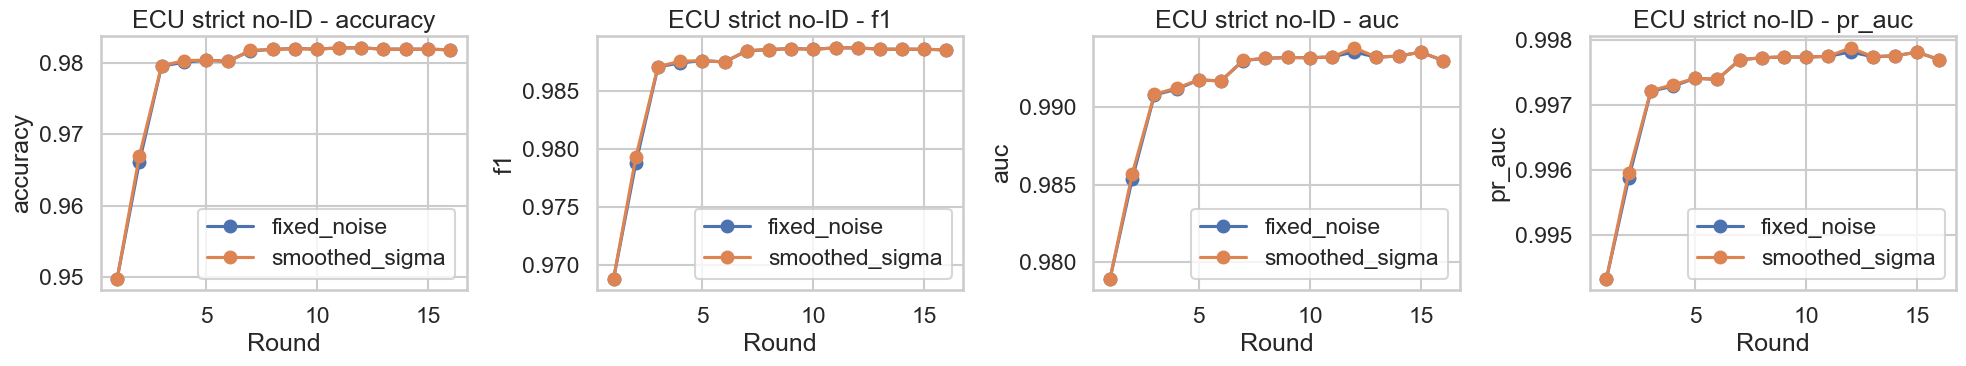

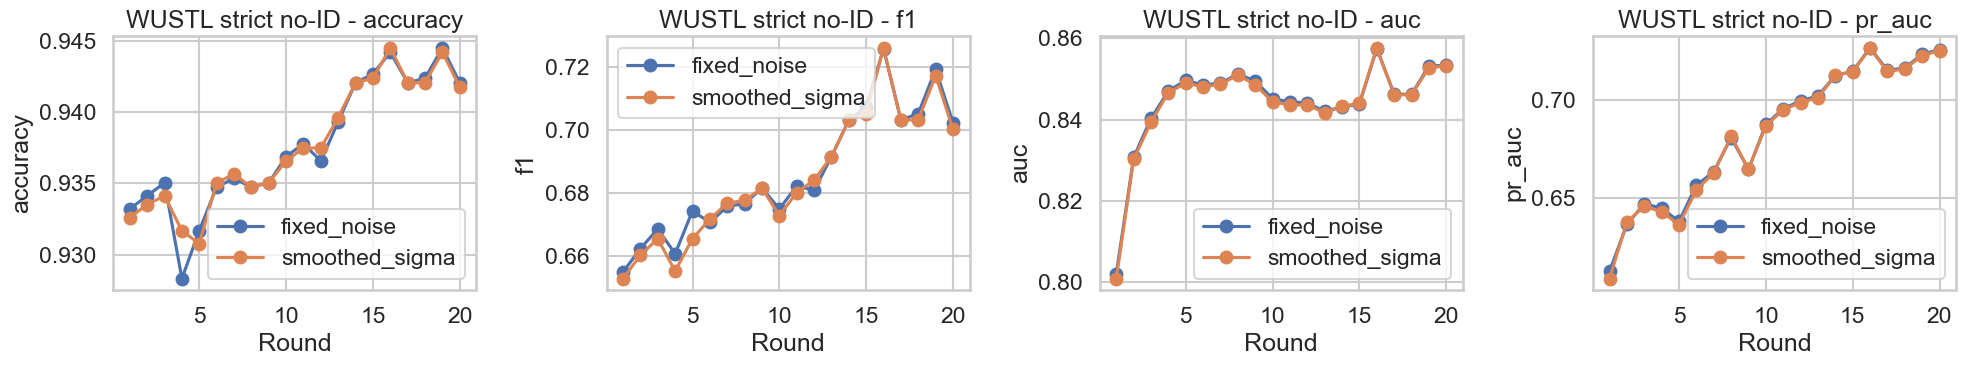

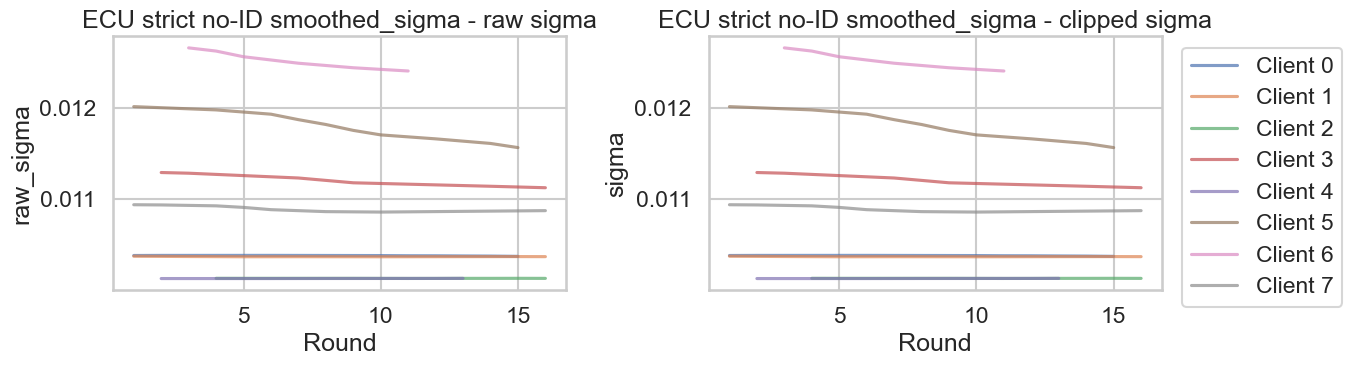

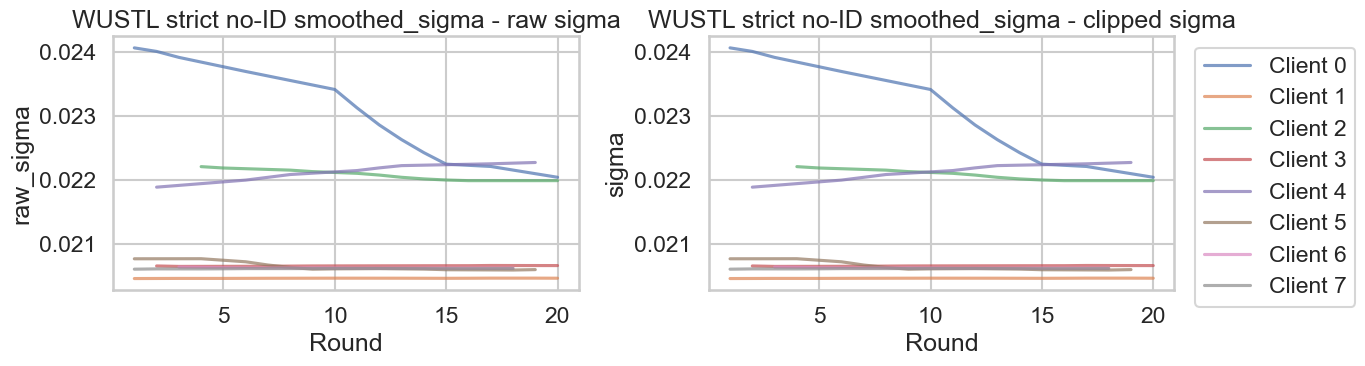

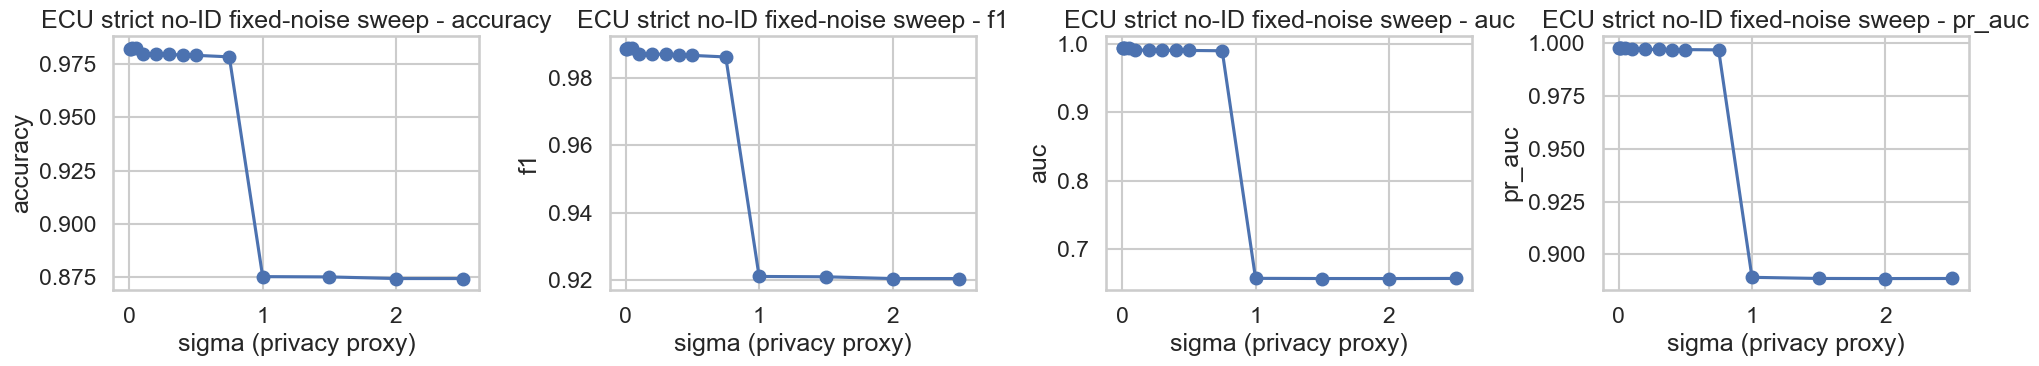

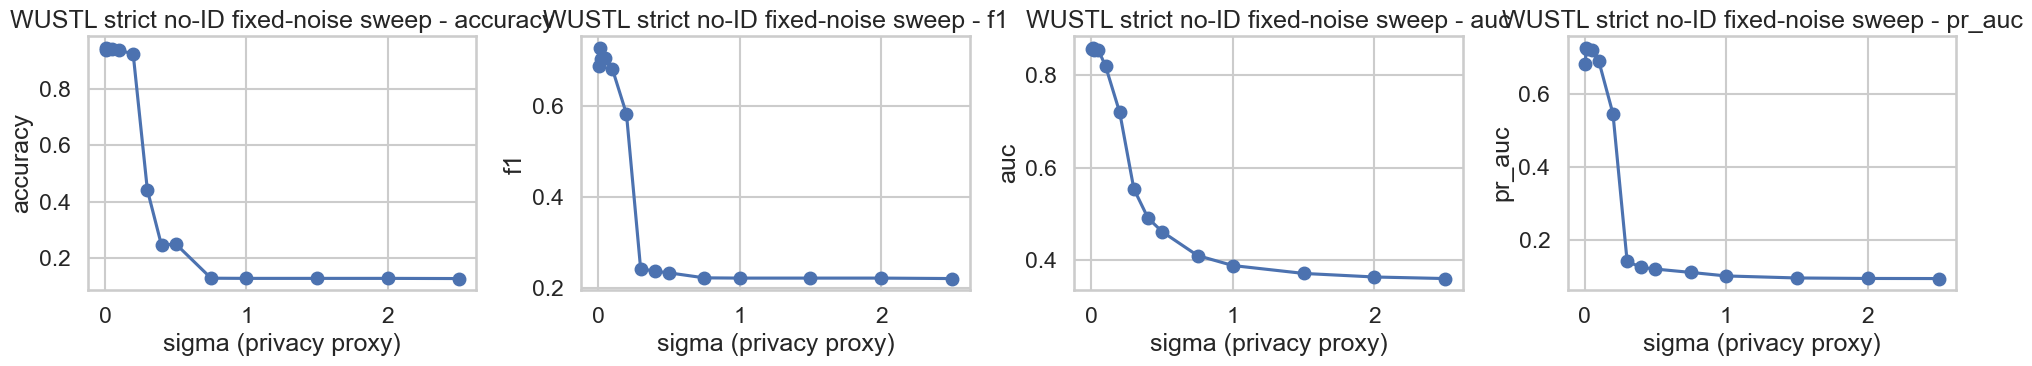

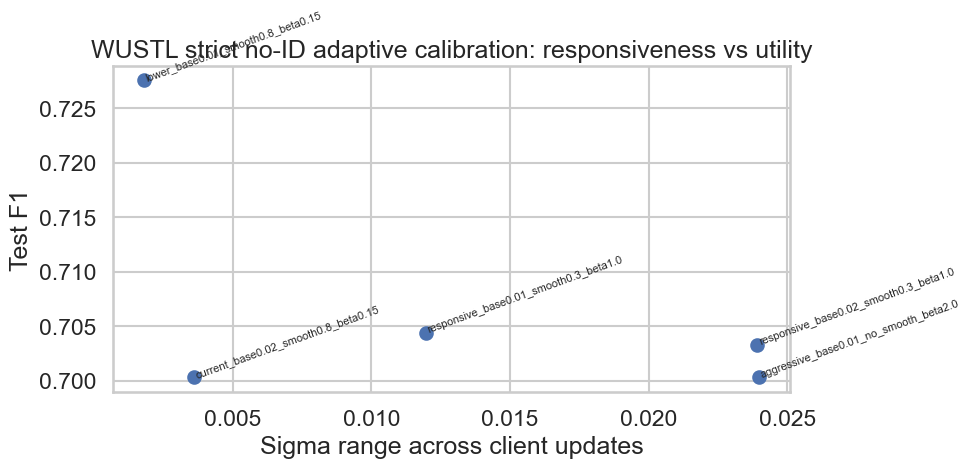

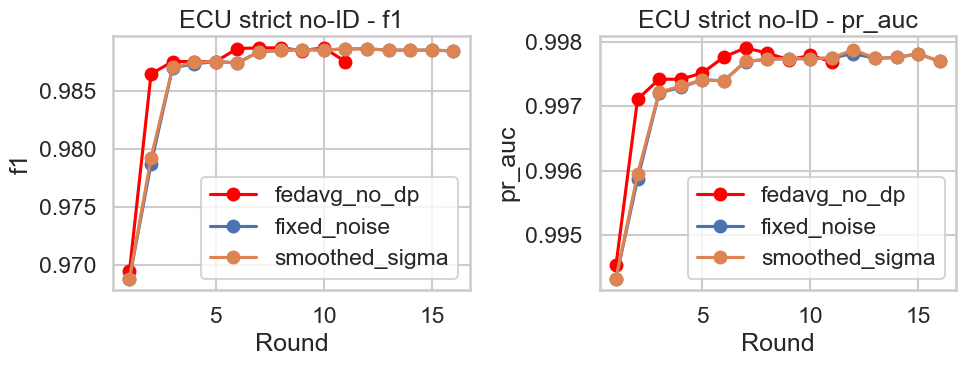

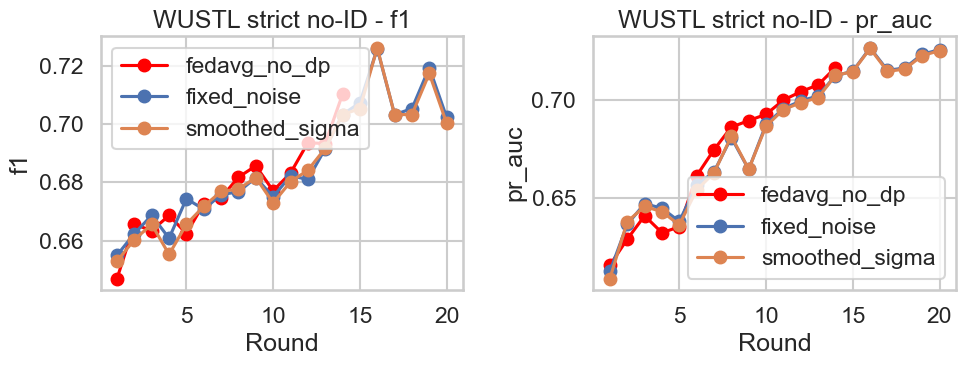


ECU Strict Smoothed Sigma
sigma min:  0.010132999393313863
sigma max:  0.012662048798800294
sigma mean: 0.010884594892399423
sigma std:  0.0007820706912827395


round                    sigma                                \
          count       mean min max count      mean       min       max   
client_id                                                                
0            10   8.700000   1  15    10  0.010383  0.010376  0.010387   
1             8   8.750000   1  16     8  0.010374  0.010372  0.010378   
2            10  10.700000   4  16    10  0.010135  0.010134  0.010136   
3             6   8.500000   2  16     6  0.011212  0.011129  0.011295   
4             6   8.666667   2  13     6  0.010134  0.010133  0.010135   
5            10   8.600000   1  15    10  0.011794  0.011569  0.012018   
6             6   6.500000   3  11     6  0.012533  0.012408  0.012662   
7             8   6.500000   1  16     8  0.010902  0.010862  0.010942   

          raw_delta_norm                               client_n           \
                   count      mean       min       max    count     mean   
client_id                                                                  
0                     10  0.287922  0.274562  0.297485       10    959.0   
1                      8  0.280823  0.272346  0.287415        8   1134.0   
2                     10  0.093998  0.090239  0.096118       10    314.0   
3                      6  1.079993  0.886022  1.371641        6   5175.0   
4                      6  0.094332  0.092716  0.096240        6    366.0   
5                     10  1.926709  1.494154  2.839174       10  12606.0   
6                      6  3.812267  3.250694  4.898507        6  55781.0   
7                      8  0.785869  0.679378  0.874159        8   3733.0   

                        client_pos_rate                                
             min    max           count      mean       min       max  
client_id                                                              
0            959    959              10  0.030240  0.030240  0.030240  
1           1134   1134               8  0.938272  0.938272  0.938272  
2            314    314              10  0.984076  0.984076  0.984076  
3           5175   5175               6  0.709952  0.709952  0.709952  
4            366    366               6  0.997268  0.997268  0.997268  
5          12606  12606              10  0.117563  0.117563  0.117563  
6          55781  55781               6  0.947652  0.947652  0.947652  
7           3733   3733               8  0.910260  0.910260  0.910260


WUSTL Strict Smoothed Sigma
sigma min:  0.01023416867800153
sigma max:  0.012028269722444642
sigma mean: 0.010671436118228572
sigma std:  0.0004964039989803605


round                    sigma                                \
          count       mean min max count      mean       min       max   
client_id                                                                
0            12  10.333333   1  20    12  0.011522  0.011005  0.012028   
1            11  11.454545   1  20    11  0.010236  0.010234  0.010238   
2            12  12.166667   4  20    12  0.011026  0.010985  0.011091   
3             9  11.777778   2  20     9  0.010334  0.010329  0.010336   
4             8  11.000000   2  19     8  0.011074  0.010946  0.011142   
5            12  10.250000   1  19    12  0.010328  0.010299  0.010388   
6             7   8.142857   3  18     7  0.010317  0.010313  0.010323   
7             9   7.777778   1  18     9  0.010311  0.010307  0.010313   

          raw_delta_norm                               client_n                \
                   count      mean       min       max    count    mean   min   
client_id                                                                       
0                     12  1.203230  0.500456  2.865843       12  6169.0  6169   
1                     11  0.171457  0.168392  0.174804       11   151.0   151   
2                     12  0.937241  0.858344  1.069213       12  2010.0  2010   
3                      9  0.250028  0.234338  0.255615        9   381.0   381   
4                      8  1.178908  0.879391  1.254759        8  2008.0  2008   
5                     12  0.221067  0.170518  0.295251       12   405.0   405   
6                      7  0.230520  0.221241  0.240002        7   367.0   367   
7                      9  0.232263  0.227142  0.236551        9   257.0   257   

                client_pos_rate                                
            max           count      mean       min       max  
client_id                                                      
0          6169              12  0.004053  0.004053  0.004053  
1           151              11  1.000000  1.000000  1.000000  
2          2010              12  0.000000  0.000000  0.000000  
3           381               9  0.212598  0.212598  0.212598  
4          2008               8  0.501992  0.501992  0.501992  
5           405              12  0.019753  0.019753  0.019753  
6           367               7  0.000000  0.000000  0.000000  
7           257               9  0.778210  0.778210  0.778210

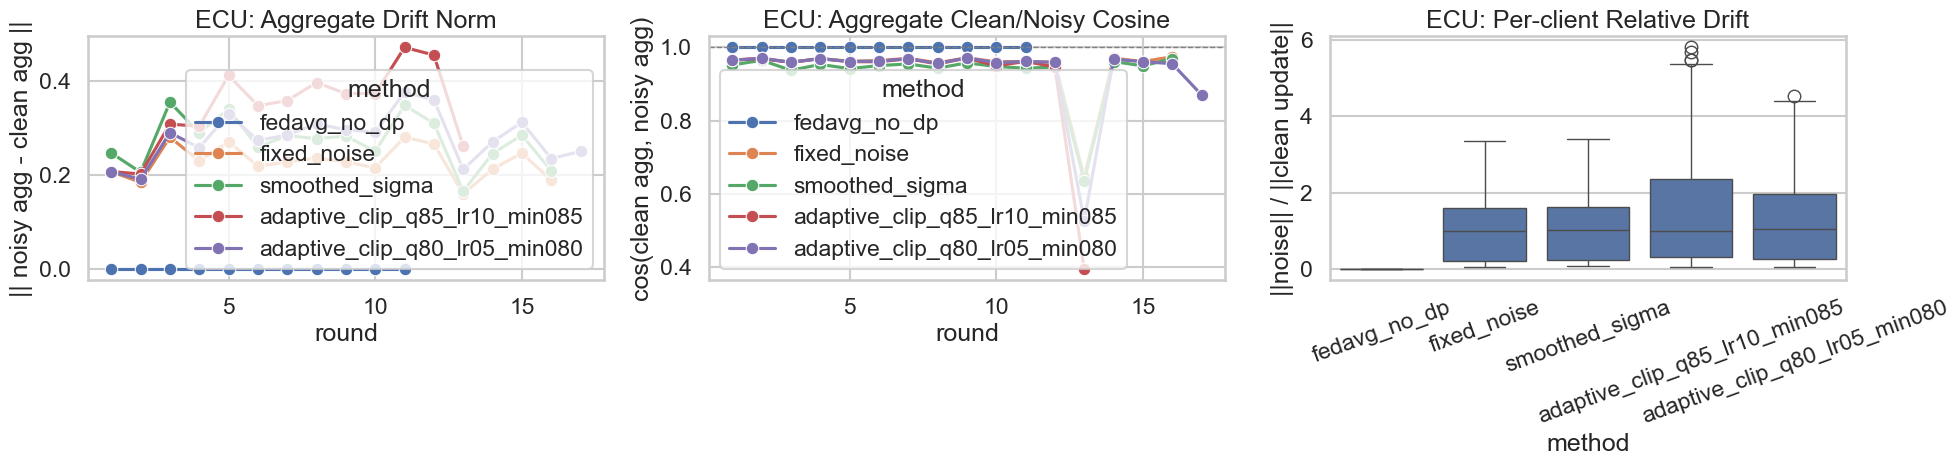

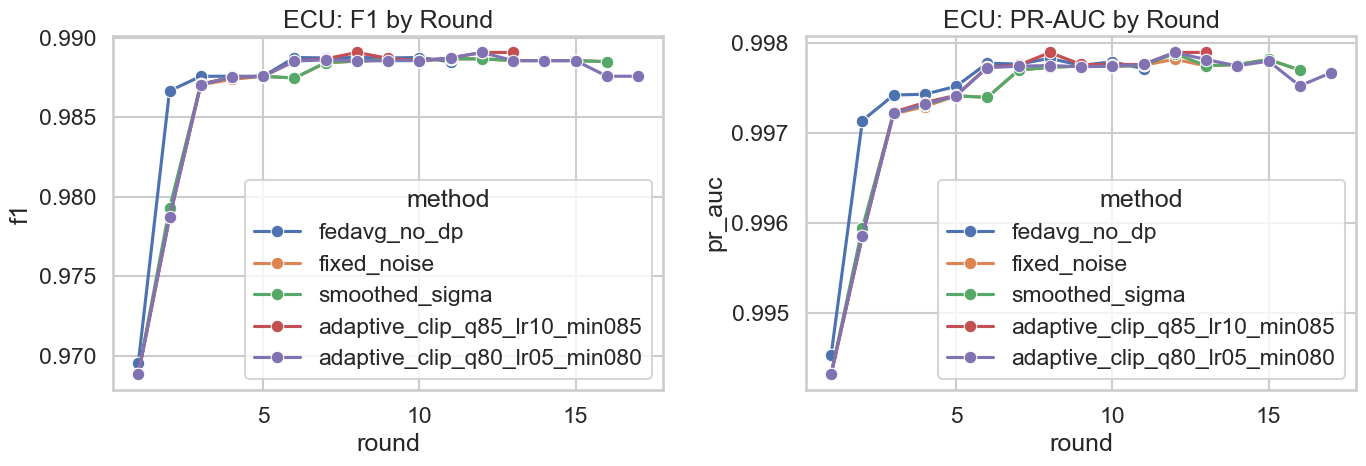

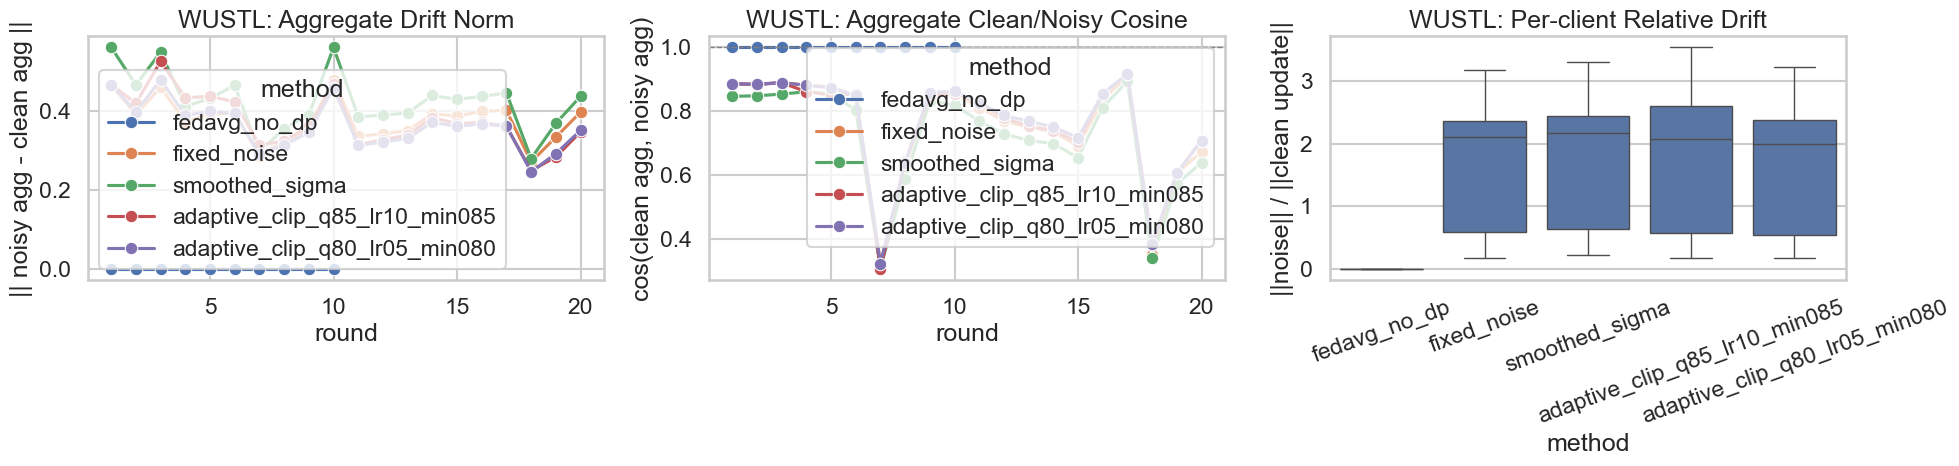

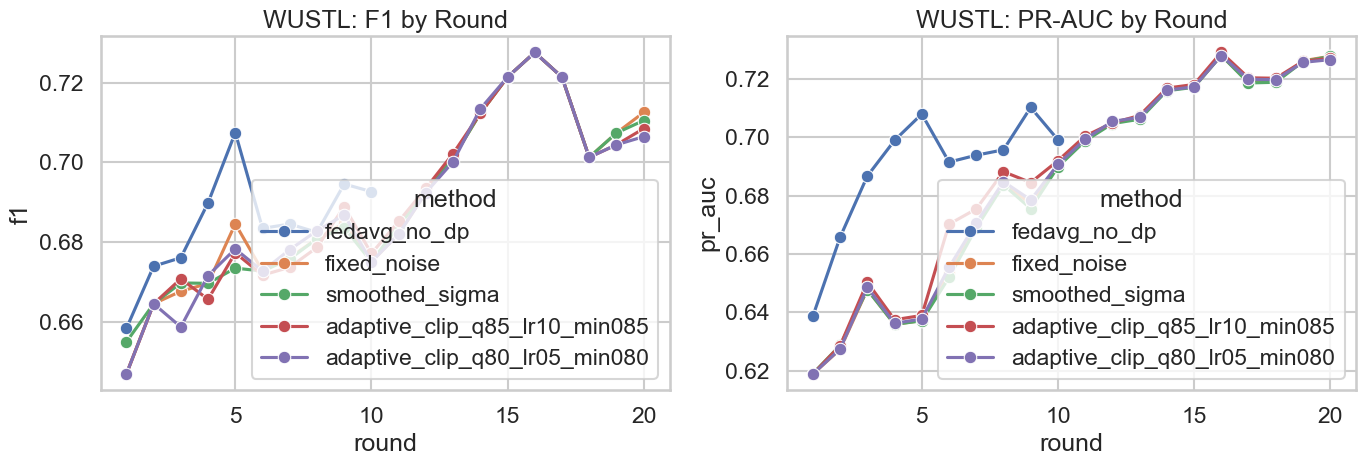

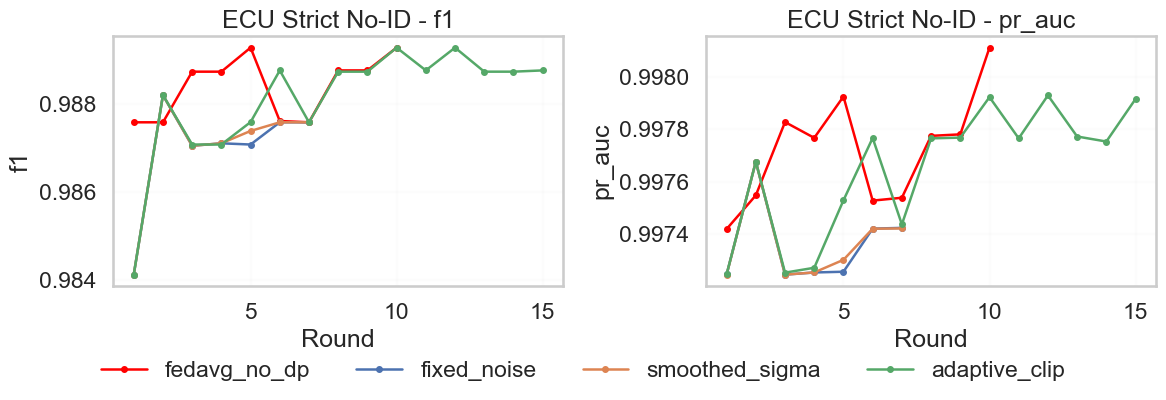

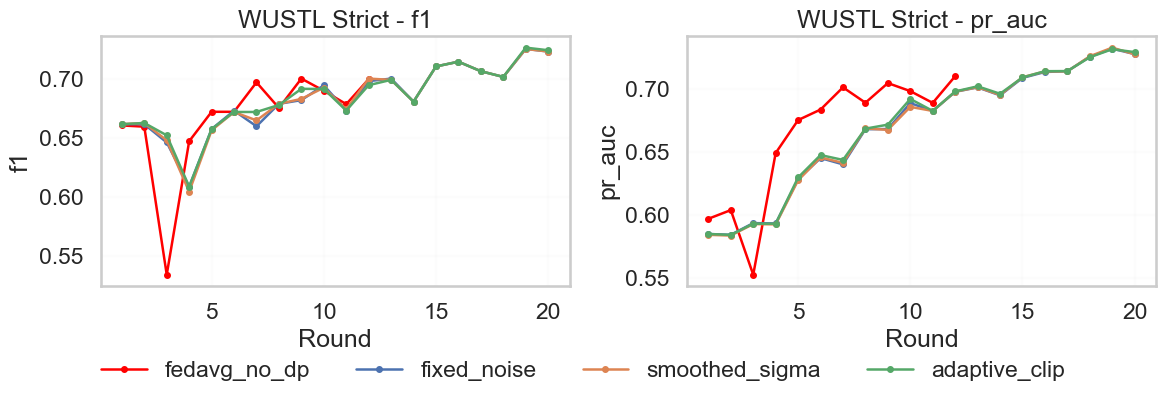

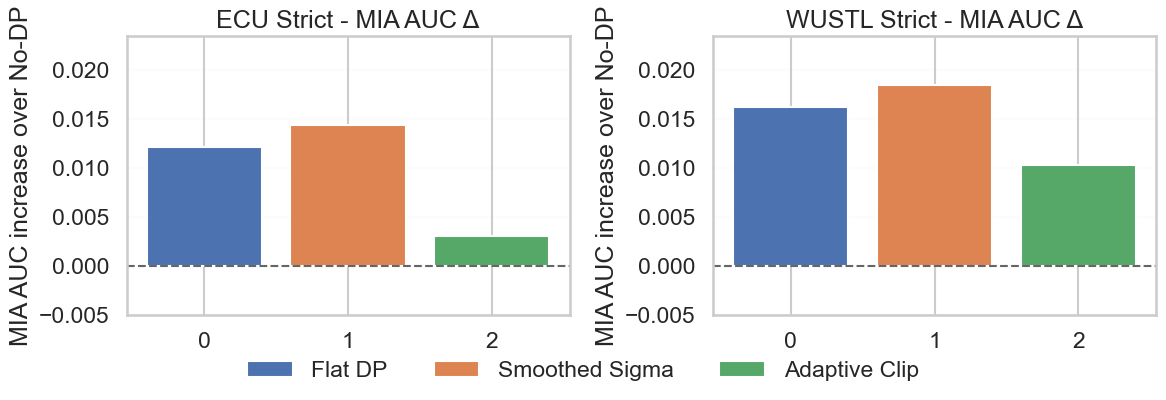

,Dataset,method,Strategy,mia_auc,no_dp_mia_auc,mia_auc_delta,mia_advantage,loss_only_auc
0,ECU Strict,fedavg_no_dp,No DP,0.5134,0.5134,0.0000,0.0268,0.5142
1,ECU Strict,fixed_noise,Flat DP,0.5255,0.5134,0.0121,0.0509,0.5018
2,ECU Strict,smoothed_sigma,Smoothed Sigma,0.5277,0.5134,0.0143,0.0554,0.5020
3,ECU Strict,adaptive_clip_q85_lr10_min085,Adaptive Clip,0.5164,0.5134,0.0031,0.0329,0.5045
4,WUSTL Strict,fedavg_no_dp,No DP,0.5041,0.5041,0.0000,0.0083,0.4785
5,WUSTL Strict,fixed_noise,Flat DP,0.5203,0.5041,0.0162,0.0406,0.4820
6,WUSTL Strict,smoothed_sigma,Smoothed Sigma,0.5226,0.5041,0.0184,0.0451,0.4823
7,WUSTL Strict,adaptive_clip_q85_lr10_min085,Adaptive Clip,0.5144,0.5041,0.0103,0.0289,0.4821


NameError: name 'strong_dp_sensitivity_summary' is not defined

In [ ]:

plot_metric_comparison(ecu_strict_fixed, ecu_strict_smoothed, "ECU strict no-ID")
plot_metric_comparison(wustl_strict_fixed, wustl_strict_smoothed, "WUSTL strict no-ID")

plot_sigma_diagnostics(ecu_strict_smoothed, "ECU strict no-ID smoothed_sigma")
plot_sigma_diagnostics(wustl_strict_smoothed, "WUSTL strict no-ID smoothed_sigma")

plot_fixed_noise_sweep(ecu_strict_fixed_sweep, "ECU strict no-ID")
plot_fixed_noise_sweep(wustl_strict_fixed_sweep, "WUSTL strict no-ID")

plot_adaptive_calibration(wustl_strict_adaptive_calibration)

plot_metric_comparison_triplet(ecu_strict_no_dp, ecu_strict_fixed, ecu_strict_smoothed, "ECU strict no-ID")
plot_metric_comparison_triplet(wustl_strict_no_dp, wustl_strict_fixed, wustl_strict_smoothed, "WUSTL strict no-ID")

adaptive_sigma_report(ecu_strict_smoothed, "ECU Strict Smoothed Sigma")
adaptive_sigma_report(wustl_strict_smoothed_final, "WUSTL Strict Smoothed Sigma")

plot_drift_suite(ecu_drift_results, "ECU")
plot_drift_suite(wustl_drift_results, "WUSTL")

plot_final_metric_comparison(
    results_for_plotting["ECU_strict_no_id"],
    "ECU Strict No-ID"
)

plot_final_metric_comparison(
    results_for_plotting["WUSTL_strict_no_id"],
    "WUSTL Strict"
)

plot_mia_auc_delta_bar_split(mia_results_final_four)

# plot_strong_dp_sensitivity(strong_dp_sensitivity_summary)



In [ ]:
def build_epsilon_summary_from_results(
    results_for_plotting,
    delta=DEFAULT_DELTA,
    sensitivity_multiplier=1.0,
):
    rows = []

    for dataset_name, method_results in results_for_plotting.items():
        for method_name, result in method_results.items():
            log_df = result.get("client_log", pd.DataFrame()).copy()

            if method_name == "fedavg_no_dp":
                rows.append({
                    "dataset": dataset_name,
                    "method": method_name,
                    "delta": delta,
                    "sigma_mean": 0.0,
                    "sigma_min": 0.0,
                    "sigma_max": 0.0,
                    "epsilon_mean": np.inf,
                    "epsilon_min": np.inf,
                    "epsilon_max": np.inf,
                    "epsilon_label": "No DP",
                })
                continue

            if log_df.empty or "sigma" not in log_df.columns:
                continue

            sigma_values = log_df["sigma"].astype(float)
            sigma_values = sigma_values[sigma_values > 0]

            if sigma_values.empty:
                continue

            eps_values = gaussian_epsilon_from_sigma(
                sigma_values,
                delta=delta,
                sensitivity_multiplier=sensitivity_multiplier,
            )

            rows.append({
                "dataset": dataset_name,
                "method": method_name,
                "delta": delta,
                "sigma_mean": float(sigma_values.mean()),
                "sigma_min": float(sigma_values.min()),
                "sigma_max": float(sigma_values.max()),
                "epsilon_mean": float(np.mean(eps_values)),
                "epsilon_min": float(np.min(eps_values)),
                "epsilon_max": float(np.max(eps_values)),
                "epsilon_label": f"ε≈{float(np.mean(eps_values)):.1f}",
            })

    return pd.DataFrame(rows)


epsilon_summary = build_epsilon_summary_from_results(
    results_for_plotting,
    delta=1e-5,
    sensitivity_multiplier=1.0,
)

display(epsilon_summary)
epsilon_summary.to_csv(RESULTS_DIR / "epsilon_summary_approx.csv", index=False)

,dataset,method,delta,sigma_mean,sigma_min,sigma_max,epsilon_mean,epsilon_min,epsilon_max,epsilon_label
0,ECU_strict_no_id,fedavg_no_dp,0.00001,0.000000,0.000000,0.000000,inf,inf,inf,No DP
1,ECU_strict_no_id,fixed_noise,0.00001,0.010000,0.010000,0.010000,484.480526,484.480526,484.480526,ε≈484.5
2,ECU_strict_no_id,smoothed_sigma,0.00001,0.011058,0.010126,0.012809,441.071073,378.246220,478.440490,ε≈441.1
3,ECU_strict_no_id,adaptive_clip_q85_lr10_min085,0.00001,0.010000,0.010000,0.010000,484.480526,484.480526,484.480526,ε≈484.5
4,WUSTL_strict_no_id,fedavg_no_dp,0.00001,0.000000,0.000000,0.000000,inf,inf,inf,No DP
5,WUSTL_strict_no_id,fixed_noise,0.00001,0.010000,0.010000,0.010000,484.480526,484.480526,484.480526,ε≈484.5
6,WUSTL_strict_no_id,smoothed_sigma,0.00001,0.010607,0.010234,0.011903,457.628493,407.019138,473.385172,ε≈457.6
7,WUSTL_strict_no_id,adaptive_clip_q85_lr10_min085,0.00001,0.010000,0.010000,0.010000,484.480526,484.480526,484.480526,ε≈484.5


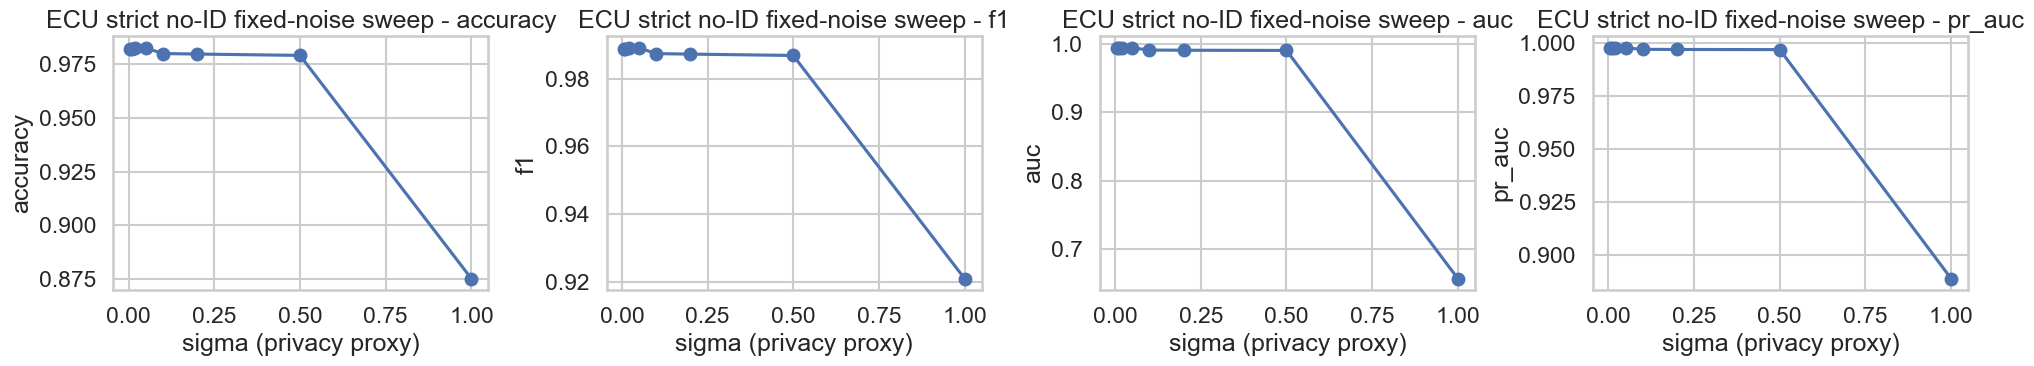

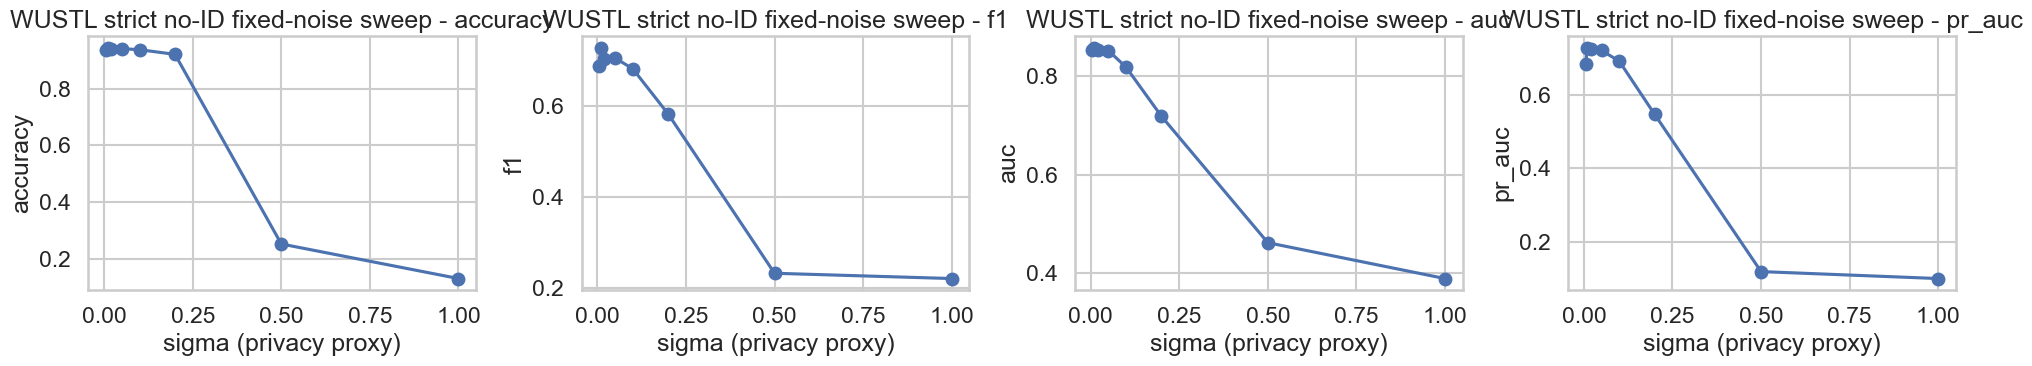

In [ ]:
plot_fixed_noise_sweep(ecu_strict_fixed_sweep, "ECU strict no-ID")
plot_fixed_noise_sweep(wustl_strict_fixed_sweep, "WUSTL strict no-ID")

In [ ]:
def plot_fixed_noise_sweep_f1_prauc(sweep_df: pd.DataFrame, dataset_name: str):
    if sweep_df.empty:
        return

    metrics = ["f1", "pr_auc"]
    metric_labels = {
        "f1": "F1",
        "pr_auc": "PR-AUC",
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    for ax, metric in zip(axes, metrics):
        ax.plot(
            sweep_df["sigma"],
            sweep_df[metric],
            marker="o",
            markersize=4,
            linewidth=1.8,
        )
        ax.set_xscale("log")
        ax.set_title(f"{dataset_name} fixed-noise sweep: {metric_labels[metric]}")
        ax.set_xlabel("Noise multiplier σ")
        ax.set_ylabel(metric_labels[metric])
        ax.grid(True, alpha=0.15)

    plt.tight_layout()
    plt.show()

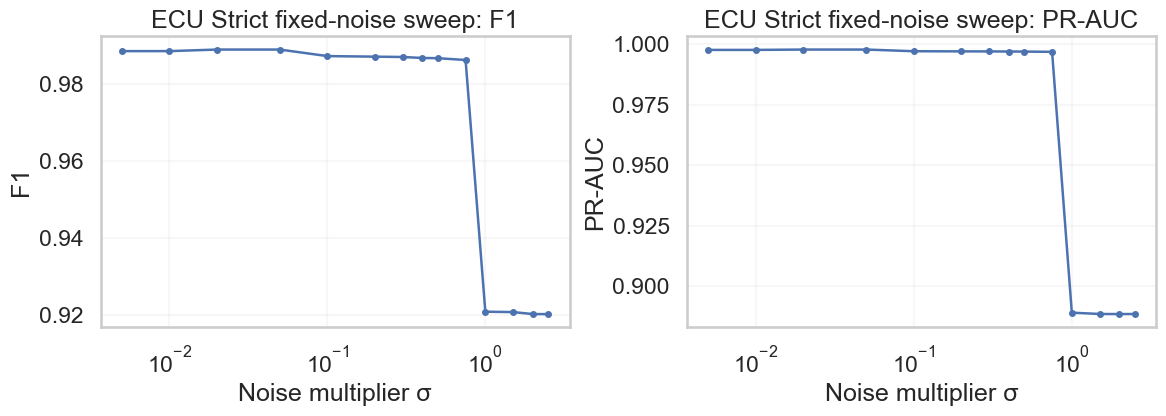

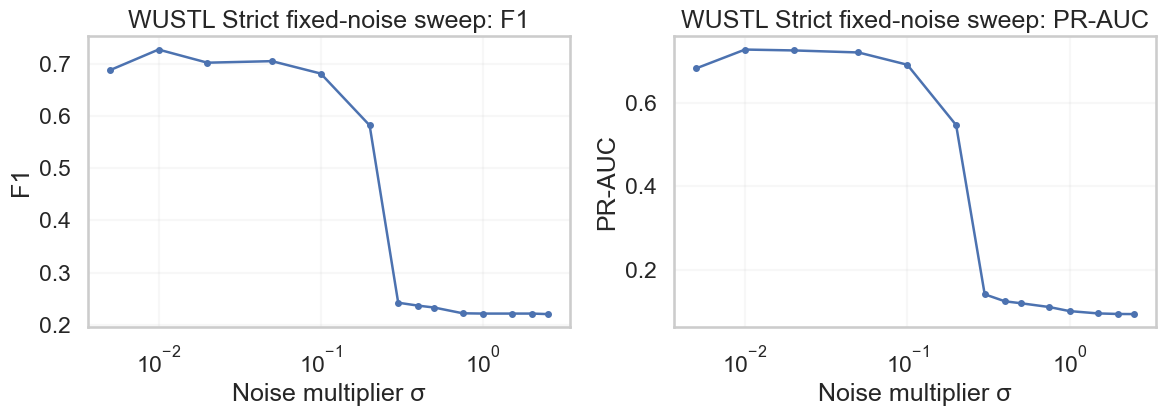

In [ ]:
plot_fixed_noise_sweep_f1_prauc(ecu_strict_fixed_sweep, "ECU Strict")
plot_fixed_noise_sweep_f1_prauc(wustl_strict_fixed_sweep, "WUSTL Strict")


In [65]:
def sigma_from_epsilon(
    epsilon: float,
    delta: float = 1e-5,
    sensitivity_multiplier: float = 1.0,
) -> float:
    return (
        sensitivity_multiplier
        * np.sqrt(2.0 * np.log(1.25 / delta))
        / epsilon
    )


def plot_fixed_noise_sweep_f1_prauc(
    sweep_df: pd.DataFrame,
    dataset_name: str,
    delta: float = 1e-5,
):
    if sweep_df.empty:
        return

    metrics = ["f1", "pr_auc"]
    metric_labels = {
        "f1": "F1",
        "pr_auc": "PR-AUC",
    }

    # IEEE-friendly monochrome styling
    line_color = "0.25"      # dark gray
    ref_color = "0.45"       # medium gray
    grid_color = "0.80"      # light gray
    text_color = "0.10"      # near black

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    for ax, metric in zip(axes, metrics):
        ax.plot(
            sweep_df["sigma"],
            sweep_df[metric],
            color=line_color,
            marker="o",
            markerfacecolor="white",
            markeredgecolor=line_color,
            markeredgewidth=1.2,
            markersize=4,
            linewidth=1.8,
        )

        ax.set_xscale("log")

        ymin = sweep_df[metric].min()
        ymax = sweep_df[metric].max()
        y_range = ymax - ymin if ymax > ymin else 1.0
        label_y = ymax - 0.08 * y_range

        # Conventional epsilon reference points.
        for eps in [8, 4, 2]:
            sigma_ref = sigma_from_epsilon(eps, delta=delta)

            if sweep_df["sigma"].min() <= sigma_ref <= sweep_df["sigma"].max():
                ax.axvline(
                    sigma_ref,
                    color=ref_color,
                    linestyle="--",
                    linewidth=1.3,
                    alpha=0.9,
                )

                ax.text(
                    sigma_ref,
                    label_y,
                    f"ε ≈ {eps}",
                    rotation=45,
                    va="top",
                    ha="right",
                    fontsize=15,
                    color=text_color,
                    bbox={
                        "boxstyle": "round,pad=0.25",
                        "facecolor": "white",
                        "edgecolor": "none",
                        "alpha": 0.85,
                    },
                )

        ax.set_title(f"{dataset_name} fixed-noise sweep: {metric_labels[metric]}")
        ax.set_xlabel("Noise multiplier σ (log scale)")
        ax.set_ylabel(metric_labels[metric])
        ax.grid(True, color=grid_color, alpha=0.35)

    fig.tight_layout()
    plt.savefig(f"{dataset_name}_fixed_noise_sweep.pdf", bbox_inches="tight")
    plt.show()

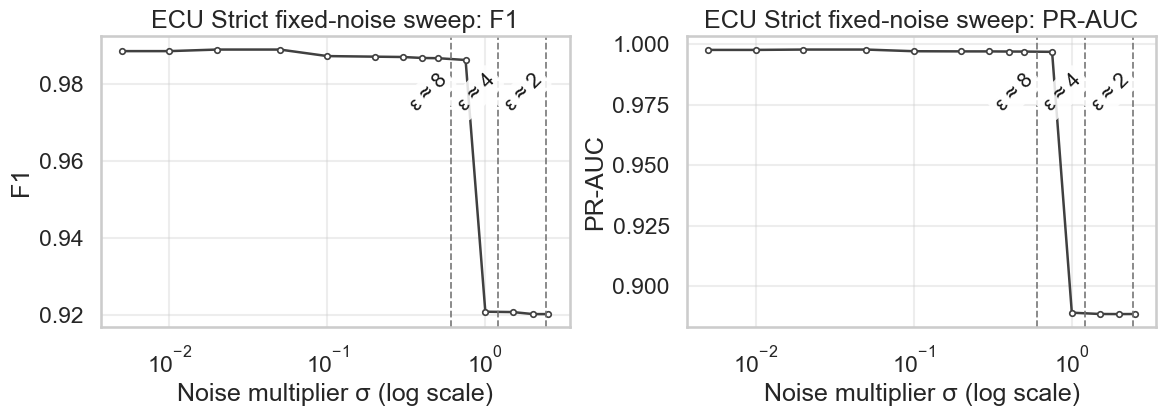

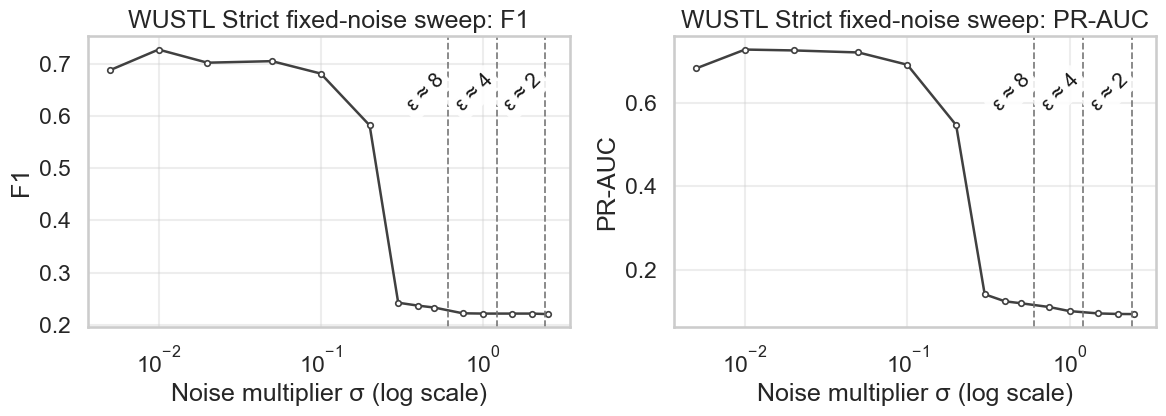

In [66]:
plot_fixed_noise_sweep_f1_prauc(ecu_strict_fixed_sweep, "ECU Strict")
plot_fixed_noise_sweep_f1_prauc(wustl_strict_fixed_sweep, "WUSTL Strict")


In [63]:
def plot_mia_auc_bar_by_model(
    mia_df: pd.DataFrame,
):
    df = mia_df.copy()

    dataset_order = [
        "ECU Strict",
        "WUSTL Strict",
    ]

    strategy_order = [
        "No DP",
        "Flat DP",
        "Smoothed Sigma",
        "Adaptive Clip",
    ]

    available_datasets = set(df["Dataset"])
    missing_datasets = [d for d in dataset_order if d not in available_datasets]

    if missing_datasets:
        raise KeyError(
            "Missing datasets: "
            f"{missing_datasets}. Available datasets are: {sorted(available_datasets)}"
        )

    available_strategies = set(df["Strategy"])
    missing_strategies = [s for s in strategy_order if s not in available_strategies]

    if missing_strategies:
        raise KeyError(
            "Missing strategies: "
            f"{missing_strategies}. Available strategies are: {sorted(available_strategies)}"
        )

    duplicate_rows = df.duplicated(["Dataset", "Strategy"], keep=False)
    if duplicate_rows.any():
        raise ValueError(
            "Duplicate Dataset/Strategy rows found. "
            "Each dataset should have exactly one row per final method.\n\n"
            f"{df.loc[duplicate_rows, ['Dataset', 'Strategy', 'method', 'mia_auc']]}"
        )

    df["Dataset"] = pd.Categorical(
        df["Dataset"],
        categories=dataset_order,
        ordered=True,
    )

    df["Strategy"] = pd.Categorical(
        df["Strategy"],
        categories=strategy_order,
        ordered=True,
    )

    df = df.sort_values(["Dataset", "Strategy"])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    legend_handles = []
    legend_labels = []

    default_colors = ["0.15", "0.45", "0.70", "0.90"]

    bar_colors = {
        "No DP": default_colors[3],
        "Flat DP": default_colors[0],
        "Smoothed Sigma": default_colors[1],
        "Adaptive Clip": default_colors[2],
    }

    for ax, dataset_name in zip(axes, dataset_order):
        plot_df = (
            df[df["Dataset"] == dataset_name]
            .set_index("Strategy")
            .reindex(strategy_order)
            .reset_index()
        )

        x = np.arange(len(strategy_order))
        values = plot_df["mia_auc"].to_numpy()

        bars = ax.bar(
            x,
            values,
            color=[bar_colors[strategy] for strategy in strategy_order],
        )

        ax.axhline(
            0.5,
            linestyle="--",
            linewidth=1.5,
            color="black",
            alpha=0.75,
            label="Chance level",
        )

        ax.text(
            x[-1] + 0.35,
            0.5,
            "chance = 0.50",
            rotation=-45,
            va="center",
            ha="left",
            fontsize=9,
        )

        ax.set_title(f"{dataset_name} - MIA AUC")
        ax.set_ylabel("MIA AUC")
        ax.set_ylim(0.0, 1.0)
        ax.set_xticks(x)
        ax.set_xticklabels(strategy_order, rotation=20, ha="right")
        ax.grid(axis="y", alpha=0.08)

        if not legend_handles:
            legend_handles = list(bars)
            legend_labels = strategy_order

    fig.legend(
        legend_handles,
        legend_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=4,
        frameon=False,
    )

    fig.tight_layout(rect=(0, 0.12, 1, 1))
    plt.savefig("mia_auc_comparison.pdf")
    plt.show()

    display(
        df[
            [
                "Dataset",
                "method",
                "Strategy",
                "mia_auc",
                "mia_advantage",
                "loss_only_auc",
            ]
        ].round(4)
    )

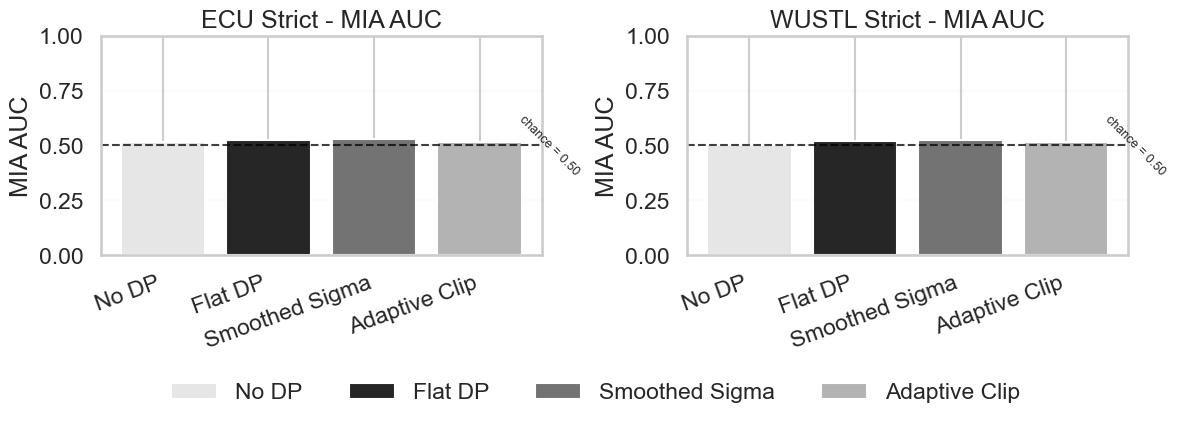

,Dataset,method,Strategy,mia_auc,mia_advantage,loss_only_auc
0,ECU Strict,fedavg_no_dp,No DP,0.5134,0.0268,0.5142
1,ECU Strict,fixed_noise,Flat DP,0.5255,0.0509,0.5018
2,ECU Strict,smoothed_sigma,Smoothed Sigma,0.5277,0.0554,0.5020
3,ECU Strict,adaptive_clip_q85_lr10_min085,Adaptive Clip,0.5164,0.0329,0.5045
4,WUSTL Strict,fedavg_no_dp,No DP,0.5041,0.0083,0.4785
5,WUSTL Strict,fixed_noise,Flat DP,0.5203,0.0406,0.4820
6,WUSTL Strict,smoothed_sigma,Smoothed Sigma,0.5226,0.0451,0.4823
7,WUSTL Strict,adaptive_clip_q85_lr10_min085,Adaptive Clip,0.5144,0.0289,0.4821


In [64]:
plot_mia_auc_bar_by_model(mia_results_final_four)